# Start

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import json
import time
import warnings, io, contextlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from itertools import product as iproduct
from sklearn.decomposition import PCA
from sklearn.covariance import LedoitWolf
from pathlib import Path
from scipy import stats
from scipy.stats import ttest_ind, wilcoxon, pearsonr, mannwhitneyu
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit
from statsmodels.stats.multitest import multipletests
from glycoforge import simulate
from glycoforge.pipeline import _build_copula_ref
from glycoforge.utils import clr, invclr, load_data_from_glycowork, pvca_variance_decomposition, find_compositional_pairs
from glycoforge.sim_batch_factor import define_batch_direction, apply_batch_effect, estimate_sigma, stratified_batches_from_columns
from glycoforge.sim_bio_factor import define_bio_injection_from_real_data, simulate_clean_data, generate_alpha_U
from glycowork.glycan_data.loader import glycomics_data_loader
from glycowork.motif.tokenization import get_random_glycan
from glycowork.motif.graph import subgraph_isomorphism
from glycowork.motif.analysis import get_differential_expression, get_volcano

# TO-DO: add base filepath for results saving/loading
fp = "."
Path(f"{fp}/results/figures").mkdir(parents=True, exist_ok=True)
import sys
sys.path.insert(1, 'TO-DO: insert absolute path to GlycoForge/use_cases/batch_correction/') # to import functions that are not part of the core package
from methods import combat, add_noise_to_zero_variance_features, percentile_normalization, ratio_preserving_combat, harmony_correction, limma_style_correction, stratified_combat
from evaluation import quantify_batch_effect_impact, compare_differential_expression

# Simulate data on a grid for Fig. 3
(runs for a while)

In [ ]:
# Define parameter grid
param_grid = {
  'bio_strength': [0.5, 1.0, 1.5, 2.0],
  'kappa_mu': [0.0, 0.5, 1.0, 1.5, 2.0],
  'var_b': [0.0, 0.3, 0.5, 0.8, 1.0]
}

# Run grid comparison
results_list = []
base_config = {
  'data_source': 'simulated',
  'n_glycans': 50,
  'n_H': 15,
  'n_U': 15,
  'k_dir': 100,
  'n_batches': 3,
  'random_seeds': [42, 43, 44],
  'verbose': False,
  'save_csv': True
}
total_runs = len(param_grid['bio_strength']) * len(param_grid['kappa_mu']) * len(param_grid['var_b'])
run_idx = 0
for bio_strength in param_grid['bio_strength']:
  for kappa_mu in param_grid['kappa_mu']:
    for var_b in param_grid['var_b']:
      run_idx += 1
      print(f"[{run_idx}/{total_runs}] bio={bio_strength}, kappa={kappa_mu}, var_b={var_b}")
      config = base_config.copy()
      config.update({'bio_strength': bio_strength, 'kappa_mu': kappa_mu, 'var_b': var_b, 'output_dir': f'results/grid_{bio_strength}_{kappa_mu}_{var_b}'})
      simulate(**config)
      for seed in config['random_seeds']:
        output_dir = config['output_dir']
        Y_clean = pd.read_csv(f"{output_dir}/1_Y_clean_seed{seed}.csv", index_col=0)
        Y_clean_clr = pd.read_csv(f"{output_dir}/1_Y_clean_clr_seed{seed}.csv", index_col=0)
        Y_with_batch = pd.read_csv(f"{output_dir}/2_Y_with_batch_seed{seed}.csv", index_col=0)
        Y_with_batch_clr = pd.read_csv(f"{output_dir}/2_Y_with_batch_clr_seed{seed}.csv", index_col=0)
        with open(f"{output_dir}/metadata_seed{seed}.json") as f:
          metadata = json.load(f)
        batch_labels = np.array(metadata['sample_info']['batch_labels'])
        bio_labels = np.array(metadata['sample_info']['bio_labels'])
        bio_groups = metadata['sample_info']['bio_groups']
        Y_with_batch_clr_fixed = add_noise_to_zero_variance_features(Y_with_batch_clr, noise_level=1e-10, random_seed=seed)
        Y_combat_clr = pd.DataFrame(
          combat(Y_with_batch_clr_fixed.values, batch_labels, mod=bio_labels),
          index=Y_with_batch_clr.index, columns=Y_with_batch_clr.columns
        )
        Y_combat = pd.DataFrame(index=Y_combat_clr.index, columns=Y_combat_clr.columns)
        for sample in Y_combat_clr.columns:
          Y_combat[sample] = invclr(Y_combat_clr[sample].values)
        Y_percentile = pd.DataFrame(percentile_normalization(Y_with_batch.values, batch_labels), index=Y_with_batch.index, columns=Y_with_batch.columns)
        Y_percentile_clr = pd.DataFrame(clr(Y_percentile.values.T).T, index=Y_percentile.index, columns=Y_percentile.columns)
        Y_ratio = pd.DataFrame(ratio_preserving_combat(Y_with_batch.values, batch_labels, mod=bio_labels), index=Y_with_batch.index, columns=Y_with_batch.columns)
        Y_ratio_clr = pd.DataFrame(clr(Y_ratio.values.T).T, index=Y_ratio.index, columns=Y_ratio.columns)
        Y_harmony = pd.DataFrame(harmony_correction(Y_with_batch.values, batch_labels), index=Y_with_batch.index, columns=Y_with_batch.columns)
        Y_harmony_clr = pd.DataFrame(clr(Y_harmony.values.T).T, index=Y_harmony.index, columns=Y_harmony.columns)
        Y_limma = pd.DataFrame(limma_style_correction(Y_with_batch.values, batch_labels, mod=bio_labels), index=Y_with_batch.index, columns=Y_with_batch.columns)
        Y_limma_clr = pd.DataFrame(clr(Y_limma.values.T).T, index=Y_limma.index, columns=Y_limma.columns)
        Y_stratified = pd.DataFrame(stratified_combat(Y_with_batch.values, batch_labels, bio_labels), index=Y_with_batch.index, columns=Y_with_batch.columns)
        Y_stratified_clr = pd.DataFrame(clr(Y_stratified.values.T).T, index=Y_stratified.index, columns=Y_stratified.columns)
        for method_name, Y_corrected, Y_corrected_clr in [
          ('uncorrected', Y_with_batch, Y_with_batch_clr),
          ('combat', Y_combat, Y_combat_clr),
          ('percentile', Y_percentile, Y_percentile_clr),
          ('ratio', Y_ratio, Y_ratio_clr),
          ('harmony', Y_harmony, Y_harmony_clr),
          ('limma', Y_limma, Y_limma_clr),
          ('stratified', Y_stratified, Y_stratified_clr)
        ]:
          metrics = quantify_batch_effect_impact(Y_corrected_clr, batch_labels, bio_groups, verbose=False)
          de = compare_differential_expression(dataset1=Y_clean, dataset2=Y_with_batch, dataset3=Y_corrected, verbose=False)
          results_list.append({
            'bio_strength': bio_strength,
            'kappa_mu': kappa_mu,
            'var_b': var_b,
            'seed': seed,
            'method': method_name,
            'PVCA_batch_variance': metrics['pvca_batch_variance'],
            'PVCA_bio_variance': metrics['pvca_bio_variance'],
            'PVCA_residual_variance': metrics['pvca_residual_variance'],
            'silhouette': metrics['silhouette'],
            'kBET': metrics['kBET'],
            'LISI': metrics['LISI'],
            'ARI': metrics['ARI'],
            'comp_effect': metrics['compositional_effect_size'],
            'pca_batch': metrics['pca_batch_effect'],
            'tp': de['results']['compare_1v3']['after_correction_errors']['tp_count'],
            'fp': de['results']['compare_1v3']['after_correction_errors']['fp_count'],
            'fn': de['results']['compare_1v3']['after_correction_errors']['fn_count'],
            'sig_clean': de['results']['dataset1']['significant_count'],
            'sig_corrected': de['results']['dataset3']['significant_count']
          })

# Create results DataFrame
results_df = pd.DataFrame(results_list)
results_df['tp_rate'] = results_df['tp'] / results_df['sig_clean']
results_df['fp_rate'] = results_df['fp'] / (50 - results_df['sig_clean'])
results_df['fn_rate'] = results_df['fn'] / results_df['sig_clean']
results_df['f1'] = 2 * results_df['tp'] / (2 * results_df['tp'] + results_df['fp'] + results_df['fn'])

# Aggregate across seeds
agg_results = results_df.groupby(['bio_strength', 'kappa_mu', 'var_b', 'method']).agg({
  'PVCA_batch_variance': 'mean',
  'PVCA_bio_variance': 'mean',
  'PVCA_residual_variance': 'mean',
  'silhouette': 'mean',
  'kBET': 'mean',
  'LISI': 'mean',
  'ARI': 'mean',
  'comp_effect': 'mean',
  'pca_batch': 'mean',
  'tp_rate': 'mean',
  'fp_rate': 'mean',
  'fn_rate': 'mean',
  'f1': 'mean'
}).reset_index()

# Find winner for each metric and condition
def find_winners(df, metric, lower_is_better=True):
  winners = []
  for (bio, kappa, var_b), group in df.groupby(['bio_strength', 'kappa_mu', 'var_b']):
    if lower_is_better:
      best = group.loc[group[metric].idxmin(), 'method']
    else:
      best = group.loc[group[metric].idxmax(), 'method']
    winners.append({'bio_strength': bio, 'kappa_mu': kappa, 'var_b': var_b, 'winner': best})
  return pd.DataFrame(winners)

# Overall winner counts
print("=== WINNER COUNTS BY METRIC ===")
for metric, lower_better in [('PVCA_batch_variance', True), ('silhouette', True), ('kBET', True), ('ARI', True), ('comp_effect', True), ('pca_batch', True), ('LISI', False), ('f1', False), ('tp_rate', False), ('fp_rate', True), ('fn_rate', True)]:
  winners = find_winners(agg_results, metric, lower_better)
  counts = winners['winner'].value_counts()
  print(f"\n{metric} ({'lower' if lower_better else 'higher'} is better):")
  print(counts)

# Visualize by condition severity
agg_results['batch_severity'] = agg_results['kappa_mu'] + agg_results['var_b']
agg_results['bio_effect_strength'] = agg_results['bio_strength']
severity_summary = agg_results.groupby(['method', pd.cut(agg_results['batch_severity'], bins=[0, 1.0, 1.5, 2.0, 3.0], labels=['weak', 'moderate', 'strong', 'extreme'], include_lowest=True)]).agg({
  'PVCA_batch_variance': 'mean',
  'PVCA_bio_variance': 'mean',
  'f1': 'mean',
  'kBET': 'mean',
  'silhouette': 'mean'
}).round(4)
print("\n=== PERFORMANCE BY BATCH SEVERITY ===")
print(severity_summary)

# Best method recommendation by scenario
print("\n=== RECOMMENDATION BY SCENARIO ===")
for bio in param_grid['bio_strength']:
  for severity in ['weak', 'moderate', 'strong', 'extreme']:
    if severity == 'weak':
      conditions = agg_results[(agg_results['bio_strength'] == bio) & (agg_results['batch_severity'] <= 1.0)]
    elif severity == 'moderate':
      conditions = agg_results[(agg_results['bio_strength'] == bio) & (agg_results['batch_severity'] > 1.0) & (agg_results['batch_severity'] <= 1.5)]
    elif severity == 'strong':
      conditions = agg_results[(agg_results['bio_strength'] == bio) & (agg_results['batch_severity'] > 1.5) & (agg_results['batch_severity'] <= 2.0)]
    else:
      conditions = agg_results[(agg_results['bio_strength'] == bio) & (agg_results['batch_severity'] > 2.0)]
    if len(conditions) > 0:
      best_f1 = conditions.loc[conditions['f1'].idxmax(), 'method']
      best_batch = conditions.loc[conditions['kBET'].idxmin(), 'method']
      print(f"Bio={bio}, Batch={severity:8s}: Best F1={best_f1:10s}, Best batch removal={best_batch:10s}")

# Save detailed results
results_df.to_csv(f"{fp}/results/method_comparison_detailed.csv", index=False)
agg_results.to_csv(f"{fp}/results/method_comparison_aggregated.csv", index=False)
print("\nDetailed results saved to results/method_comparison_detailed.csv")
print("Aggregated results saved to results/method_comparison_aggregated.csv")

# Figure S4

You're working with an alpha of 0.054572814701647765 that has been adjusted for your sample size of 20.
Significance inflation detected. The CLR/ALR transformation possibly cannot handle this dataset. Consider running again with a higher gamma value.             Proceed with caution; for now switching to Bonferroni correction to be conservative about this.


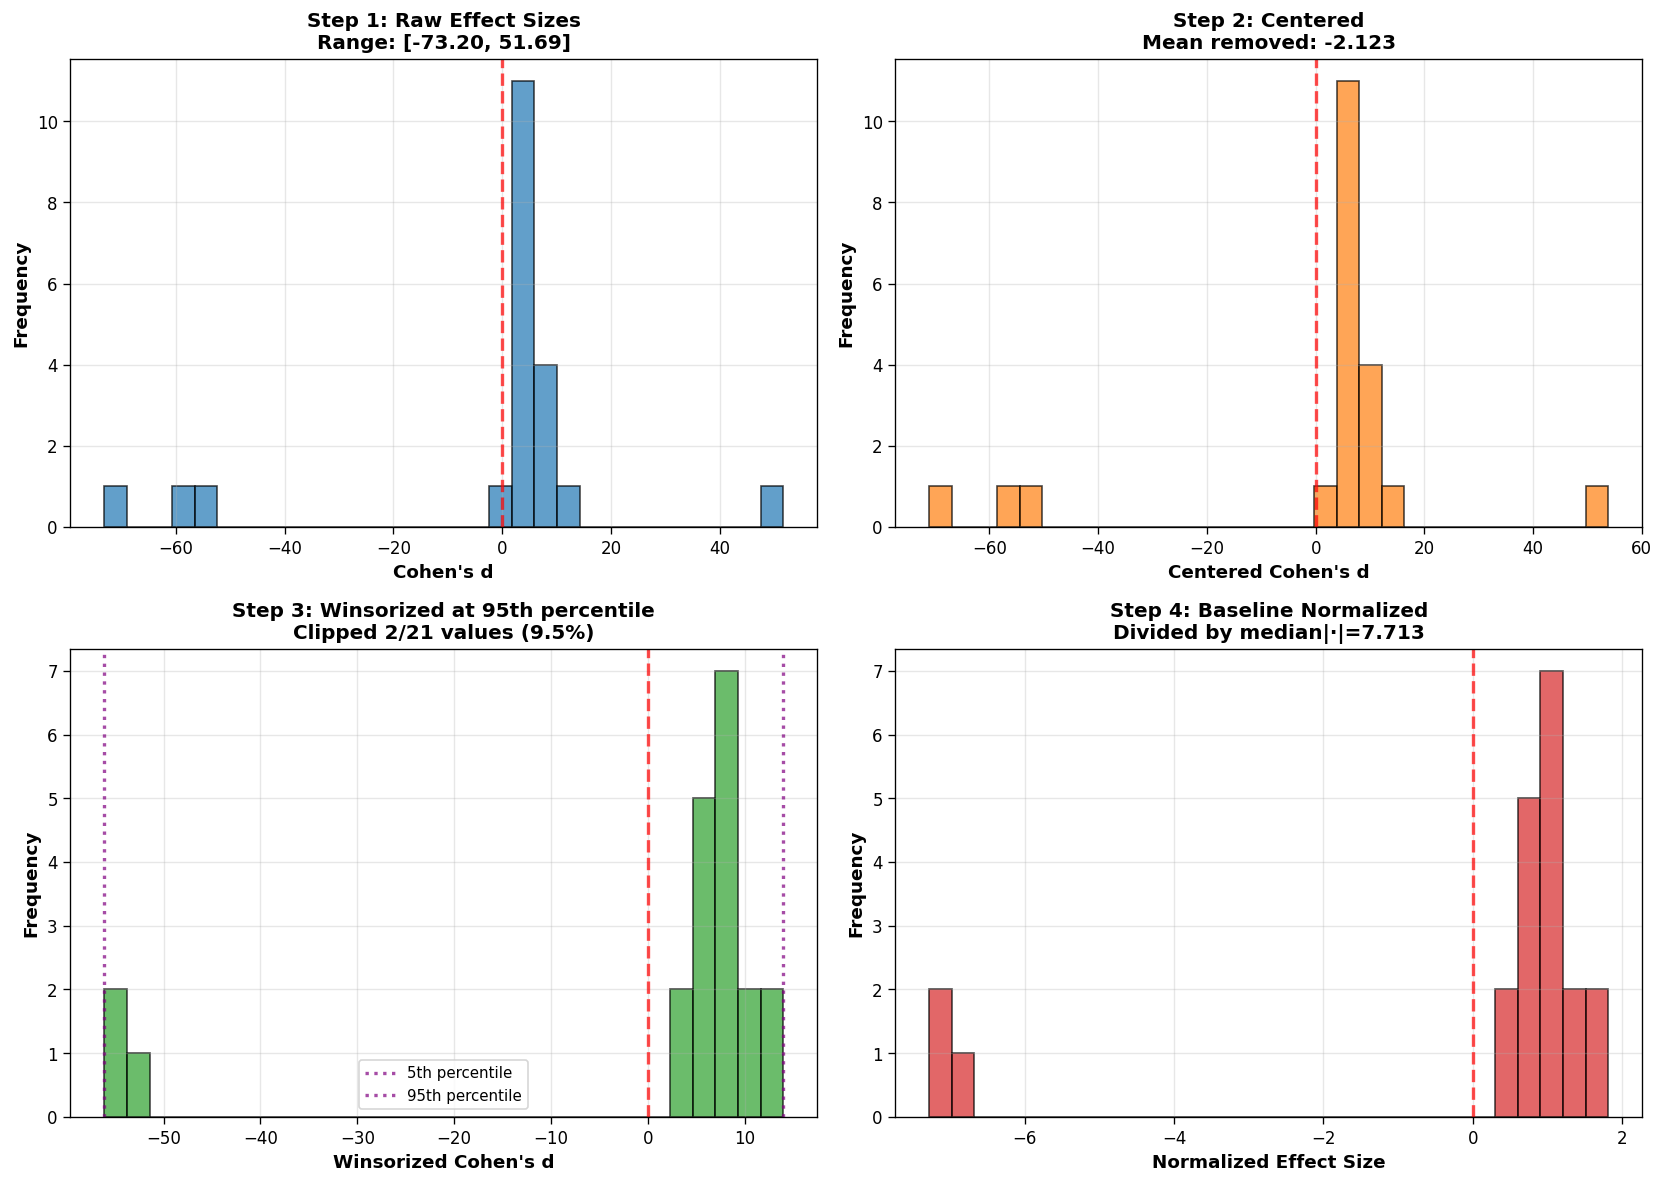


Processing summary:
  Raw: mean=-2.123, median|·|=5.590, max|·|=73.197
  Centered: mean=0.000, median|·|=7.713, max|·|=71.074
  Winsorized: median|·|=7.713, max|·|=56.130
  Normalized: median|·|=1.000, max|·|=7.278
  Outlier ratio: 6.67 → selected 95th percentile


In [4]:
# Load real data
df = load_data_from_glycowork('glycomics_human_leukemia_O_PMID34646384')
r7_cols = [c for c in df.columns if c.startswith('R7')]
bm_cols = [c for c in df.columns if c.startswith('BM')]

# Get raw effect sizes
results = get_differential_expression(df, group1=bm_cols, group2=r7_cols, transform="CLR", impute=True)
raw_effect_sizes = results['Effect size'].fillna(0.0).values

# Apply centering
d_centered = raw_effect_sizes - np.mean(raw_effect_sizes)

# Apply Winsorization (auto-select percentile)
q75, q25 = np.percentile(np.abs(d_centered), [75, 25])
max_abs = np.max(np.abs(d_centered))
outlier_ratio = max_abs / (q75 + 1e-10)
if outlier_ratio > 15:
  winsorize_percentile = 85
elif outlier_ratio > 10:
  winsorize_percentile = 90
elif outlier_ratio > 5:
  winsorize_percentile = 95
else:
  winsorize_percentile = 99
lower = np.percentile(d_centered, 100 - winsorize_percentile)
upper = np.percentile(d_centered, winsorize_percentile)
d_winsorized = np.clip(d_centered, lower, upper)

# Apply baseline normalization
baseline_median = np.median(np.abs(d_winsorized))
d_normalized = d_winsorized / baseline_median

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Panel 1: Raw effect sizes
axes[0].hist(raw_effect_sizes, bins=30, color='#1f77b4', alpha=0.7, edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[0].set_xlabel('Cohen\'s d', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].set_title(f'Step 1: Raw Effect Sizes\nRange: [{raw_effect_sizes.min():.2f}, {raw_effect_sizes.max():.2f}]', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Panel 2: After centering
axes[1].hist(d_centered, bins=30, color='#ff7f0e', alpha=0.7, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[1].set_xlabel('Centered Cohen\'s d', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1].set_title(f'Step 2: Centered\nMean removed: {np.mean(raw_effect_sizes):.3f}', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

# Panel 3: After Winsorization (show outliers)
n_clipped = np.sum((d_centered < lower) | (d_centered > upper))
axes[2].hist(d_winsorized, bins=30, color='#2ca02c', alpha=0.7, edgecolor='black')
axes[2].axvline(lower, color='purple', linestyle=':', linewidth=2, alpha=0.7, label=f'{100-winsorize_percentile}th percentile')
axes[2].axvline(upper, color='purple', linestyle=':', linewidth=2, alpha=0.7, label=f'{winsorize_percentile}th percentile')
axes[2].axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[2].set_xlabel('Winsorized Cohen\'s d', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[2].set_title(f'Step 3: Winsorized at {winsorize_percentile}th percentile\nClipped {n_clipped}/{len(d_centered)} values ({n_clipped/len(d_centered)*100:.1f}%)', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

# Panel 4: After baseline normalization
axes[3].hist(d_normalized, bins=30, color='#d62728', alpha=0.7, edgecolor='black')
axes[3].axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[3].set_xlabel('Normalized Effect Size', fontsize=11, fontweight='bold')
axes[3].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[3].set_title(f'Step 4: Baseline Normalized\nDivided by median|·|={baseline_median:.3f}', fontsize=12, fontweight='bold')
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{fp}/results/figures/figs4.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nProcessing summary:")
print(f"  Raw: mean={np.mean(raw_effect_sizes):.3f}, median|·|={np.median(np.abs(raw_effect_sizes)):.3f}, max|·|={np.max(np.abs(raw_effect_sizes)):.3f}")
print(f"  Centered: mean={np.mean(d_centered):.3f}, median|·|={np.median(np.abs(d_centered)):.3f}, max|·|={np.max(np.abs(d_centered)):.3f}")
print(f"  Winsorized: median|·|={np.median(np.abs(d_winsorized)):.3f}, max|·|={np.max(np.abs(d_winsorized)):.3f}")
print(f"  Normalized: median|·|={np.median(np.abs(d_normalized)):.3f}, max|·|={np.max(np.abs(d_normalized)):.3f}")
print(f"  Outlier ratio: {outlier_ratio:.2f} → selected {winsorize_percentile}th percentile")

# Figure S5

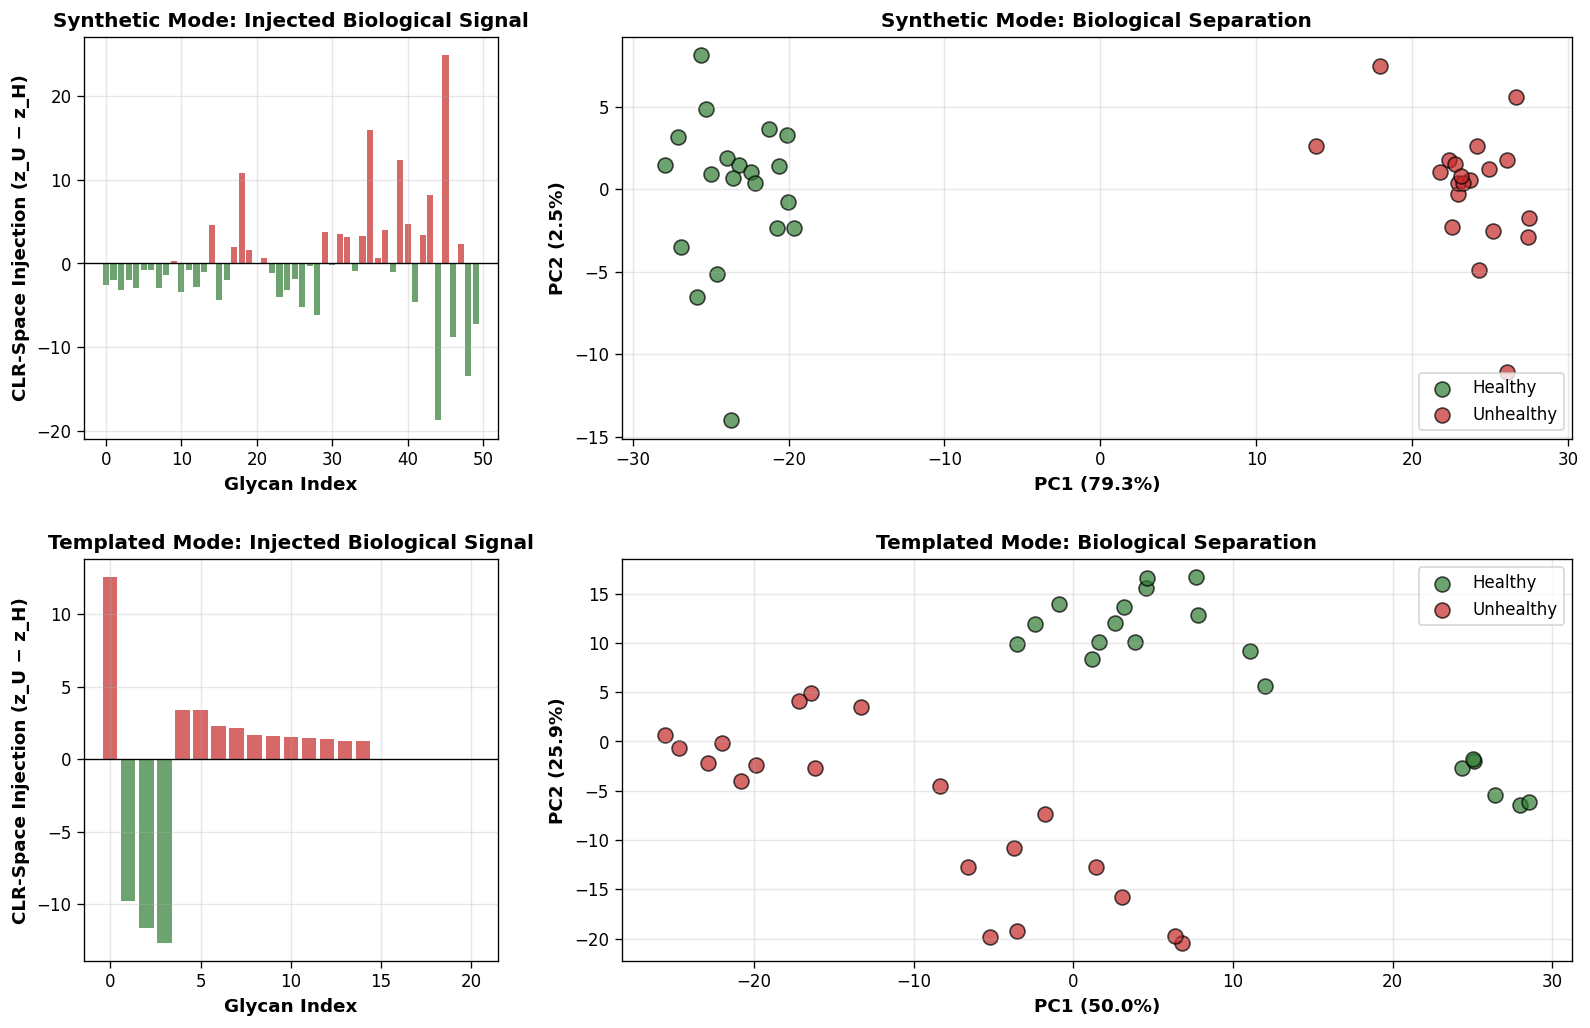

Synthetic: α_H range [2.2, 43.4], α_U range [2.2, 43.4]
Synthetic PC1+PC2: 81.9%
Templated PC1+PC2: 75.9%


In [3]:
# Run synthetic mode
config_simplified = {
  'data_source': 'simulated',
  'bio_strength': 1.5,
  'n_glycans': 50,
  'n_H': 20,
  'n_U': 20,
  'n_batches': 2,
  'kappa_mu': 0.0,
  'var_b': 0.0,
  'random_seeds': [42],
  'output_dir': f'{fp}/results/fig1b_simplified',
  'verbose': False,
  'save_csv': True
}
result_simplified = simulate(**config_simplified)

# Run templated mode
config_hybrid = {
  'data_source': 'real',
  'data_file': 'glycomics_human_leukemia_O_PMID34646384',
  'use_real_effect_sizes': True,
  'differential_mask': 'significant',
  'bio_strength': 1.5,
  'k_dir': 100,
  'variance_ratio': 1.5,
  'n_H': 20,
  'n_U': 20,
  'n_batches': 2,
  'kappa_mu': 0.0,
  'var_b': 0.0,
  'random_seeds': [42],
  'output_dir': f'{fp}/results/fig1b_hybrid',
  'verbose': False,
  'save_csv': True
}
result_hybrid = simulate(**config_hybrid)

# Load metadata with error handling
with open(f'{fp}/results/fig1b_simplified/metadata_seed42.json', 'r', encoding='utf-8', errors='ignore') as f:
  meta_simp = json.load(f)
with open(f'{fp}/results/fig1b_hybrid/metadata_seed42.json', 'r', encoding='utf-8', errors='ignore') as f:
  meta_hybrid = json.load(f)

# Load data
Y_clean_simp = pd.read_csv(f'{fp}/results/fig1b_simplified/1_Y_clean_clr_seed42.csv', index_col=0)
Y_clean_hybrid = pd.read_csv(f'{fp}/results/fig1b_hybrid/1_Y_clean_clr_seed42.csv', index_col=0)
injection_hybrid = np.array(meta_hybrid['bio_injection_debug']['injection'])
alpha_H_simp = np.array(meta_simp['bio_signal_params']['alpha_H'])
alpha_U_simp = np.array(meta_simp['bio_signal_params']['alpha_U'])

# Extract alpha values
n_H_simp = config_simplified['n_H']
injection_simp = Y_clean_simp.iloc[:, n_H_simp:].mean(axis=1).values - Y_clean_simp.iloc[:, :n_H_simp].mean(axis=1).values

# Create figure
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Top row: Simplified mode
ax1 = fig.add_subplot(gs[0, 0])
x_simp = np.arange(len(injection_simp))
colors_simp = ['#C62828' if v > 0 else '#2E7D32' for v in injection_simp]
ax1.bar(x_simp, injection_simp, color=colors_simp, alpha=0.7)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_xlabel('Glycan Index', fontsize=11, fontweight='bold')
ax1.set_ylabel('CLR-Space Injection (z_U − z_H)', fontsize=11, fontweight='bold')
ax1.set_title('Synthetic Mode: Injected Biological Signal', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1:])
pca_simp = PCA(n_components=2)
pc_simp = pca_simp.fit_transform(Y_clean_simp.T)
n_H = config_simplified['n_H']
ax2.scatter(pc_simp[:n_H, 0], pc_simp[:n_H, 1], c='#2E7D32', label='Healthy', s=80, alpha=0.7, edgecolors='black', linewidths=1)
ax2.scatter(pc_simp[n_H:, 0], pc_simp[n_H:, 1], c='#C62828', label='Unhealthy', s=80, alpha=0.7, edgecolors='black', linewidths=1)
ax2.set_xlabel(f'PC1 ({pca_simp.explained_variance_ratio_[0]:.1%})', fontsize=11, fontweight='bold')
ax2.set_ylabel(f'PC2 ({pca_simp.explained_variance_ratio_[1]:.1%})', fontsize=11, fontweight='bold')
ax2.set_title('Synthetic Mode: Biological Separation', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# Bottom row: Hybrid mode
ax3 = fig.add_subplot(gs[1, 0])
x_hybrid = np.arange(len(injection_hybrid))
colors_hybrid = ['#C62828' if v > 0 else '#2E7D32' for v in injection_hybrid]
ax3.bar(x_hybrid, injection_hybrid, color=colors_hybrid, alpha=0.7)
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_xlabel('Glycan Index', fontsize=11, fontweight='bold')
ax3.set_ylabel('CLR-Space Injection (z_U − z_H)', fontsize=11, fontweight='bold')
ax3.set_title('Templated Mode: Injected Biological Signal', fontsize=12, fontweight='bold')
ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1:])
pca_hybrid = PCA(n_components=2)
pc_hybrid = pca_hybrid.fit_transform(Y_clean_hybrid.T)
n_H = config_hybrid['n_H']
ax4.scatter(pc_hybrid[:n_H, 0], pc_hybrid[:n_H, 1], c='#2E7D32', label='Healthy', s=80, alpha=0.7, edgecolors='black', linewidths=1)
ax4.scatter(pc_hybrid[n_H:, 0], pc_hybrid[n_H:, 1], c='#C62828', label='Unhealthy', s=80, alpha=0.7, edgecolors='black', linewidths=1)
ax4.set_xlabel(f'PC1 ({pca_hybrid.explained_variance_ratio_[0]:.1%})', fontsize=11, fontweight='bold')
ax4.set_ylabel(f'PC2 ({pca_hybrid.explained_variance_ratio_[1]:.1%})', fontsize=11, fontweight='bold')
ax4.set_title('Templated Mode: Biological Separation', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3)

plt.savefig(f'{fp}/results/figures/figs5.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Synthetic: α_H range [{alpha_H_simp.min():.1f}, {alpha_H_simp.max():.1f}], α_U range [{alpha_U_simp.min():.1f}, {alpha_U_simp.max():.1f}]")
print(f"Synthetic PC1+PC2: {pca_simp.explained_variance_ratio_[:2].sum():.1%}")
print(f"Templated PC1+PC2: {pca_hybrid.explained_variance_ratio_[:2].sum():.1%}")

# Figure S10

In [ ]:
glycs = glycomics_data_loader.human_gastric_O_PMC5762837.glycan.tolist()

figure_number = "figs10"
simulate(n_H= 20,
    n_U= 20, n_batches= 3, output_dir=f"results/{figure_number}/", n_glycans = len(glycs), glycan_sequences = glycs,
         motif_rules = {"Neu5Ac": "down"}, batch_motif_rules = {0: {"Neu5Ac": "down"}, 1: {"Neu5Ac": "down"}}, motif_bias=1.0, batch_motif_bias=1.0)

batch_colors = ['#2ca02c', '#d62728', '#9467bd']
bio_markers = {'healthy': 'o', 'unhealthy': 's'}

# Load metadata with error handling
with open(f'{fp}/results/{figure_number}/metadata_seed42.json', 'r', encoding='utf-8', errors='ignore') as f:
  meta_hybrid = json.load(f)

# Load data
Y_clean_hybrid = pd.read_csv(f'{fp}/results/{figure_number}/2_Y_with_batch_clr_seed42.csv', index_col=0)

# Extract alpha values
alpha_H_hybrid = np.array(meta_hybrid['bio_signal_params']['alpha_H'])
alpha_U_hybrid = np.array(meta_hybrid['bio_signal_params']['alpha_U'])

batch_labels = np.array(meta_hybrid['sample_info']['batch_labels'])
bio_labels = np.array(meta_hybrid['sample_info']['bio_labels'])
bio_groups = meta_hybrid['sample_info']['bio_groups']
Y_with_batch_clr_fixed = add_noise_to_zero_variance_features(Y_clean_hybrid, noise_level=1e-10, random_seed=42)
Y_combat_clr = pd.DataFrame(
  combat(Y_with_batch_clr_fixed.values, batch_labels, mod=bio_labels),
  index=Y_clean_hybrid.index, columns=Y_clean_hybrid.columns
)
Y_combat = pd.DataFrame(index=Y_combat_clr.index, columns=Y_combat_clr.columns)
for sample in Y_combat_clr.columns:
  Y_combat[sample] = invclr(Y_combat_clr[sample].values)

# Create figure
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(1, 2)

pca = PCA(n_components=2)
pc = pca.fit_transform(Y_clean_hybrid.T)
# Bottom row: Templated mode
# Plot by batch with biological group markers
ax = fig.add_subplot(gs[0, 0])
for batch_id in range(3):
    batch_mask = batch_labels == batch_id
    # Healthy samples in this batch
    healthy_mask = batch_mask & np.array([c.startswith('healthy') for c in Y_clean_hybrid.columns])
    if healthy_mask.any():
        ax.scatter(pc[healthy_mask, 0], pc[healthy_mask, 1], 
                c=batch_colors[batch_id], marker='o', s=100, alpha=0.8,
                edgecolors='black', linewidths=1.5, label=f'Batch {batch_id}' if batch_id == 0 else '')
    # Unhealthy samples in this batch
    unhealthy_mask = batch_mask & np.array([c.startswith('unhealthy') for c in Y_clean_hybrid.columns])
    if unhealthy_mask.any():
        ax.scatter(pc[unhealthy_mask, 0], pc[unhealthy_mask, 1],
                c=batch_colors[batch_id], marker='s', s=100, alpha=0.8,
                edgecolors='black', linewidths=1.5)
ax.set_title('Untreated', fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3)

pca = PCA(n_components=2)
pc = pca.fit_transform(Y_combat.T)
# Plot by batch with biological group markers
ax2 = fig.add_subplot(gs[0, 1])
for batch_id in range(3):
    batch_mask = batch_labels == batch_id
    # Healthy samples in this batch
    healthy_mask = batch_mask & np.array([c.startswith('healthy') for c in Y_combat.columns])
    if healthy_mask.any():
        ax2.scatter(pc[healthy_mask, 0], pc[healthy_mask, 1], 
                c=batch_colors[batch_id], marker='o', s=100, alpha=0.8,
                edgecolors='black', linewidths=1.5, label=f'Batch {batch_id}' if batch_id == 0 else '')
    # Unhealthy samples in this batch
    unhealthy_mask = batch_mask & np.array([c.startswith('unhealthy') for c in Y_combat.columns])
    if unhealthy_mask.any():
        ax2.scatter(pc[unhealthy_mask, 0], pc[unhealthy_mask, 1],
                c=batch_colors[batch_id], marker='s', s=100, alpha=0.8,
                edgecolors='black', linewidths=1.5)
ax2.set_title('ComBat-treated', fontsize=12, fontweight='bold')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11, fontweight='bold')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11, fontweight='bold')
ax2.grid(alpha=0.3)

# Add custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Healthy', markeredgecolor='black', markeredgewidth=1.5),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='Unhealthy', markeredgecolor='black', markeredgewidth=1.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=batch_colors[0], markersize=10, label='Batch 0', markeredgecolor='black', markeredgewidth=1.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=batch_colors[1], markersize=10, label='Batch 1', markeredgecolor='black', markeredgewidth=1.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=batch_colors[2], markersize=10, label='Batch 2', markeredgecolor='black', markeredgewidth=1.5)
    ]
ax.legend(handles=legend_elements, fontsize=9, loc='best')

plt.tight_layout()
plt.savefig(f'{fp}/results/figures/{figure_number}.pdf', dpi=300, bbox_inches='tight')
plt.show()


# Figure 1C

In [6]:
n_glycans = 100
glycs = get_random_glycan(n_glycans, "O")

config_out = simulate(n_glycans=n_glycans, glycan_sequences=glycs, motif_rules={"Fuc(a1-3/4)[Gal(b1-3/4)]GlcNAc": "up"}, motif_bias=1.0)
res = get_differential_expression(f"{fp}/results/1_Y_clean_seed42.csv",
                           group1 = list(range(1,16)), group2 = list(range(16, 31)), motifs=True, feature_set=["known"])
res.to_csv(f"{fp}/lewis_results.csv", index=False)
res

You're working with an alpha of 0.04834871215929448 that has been adjusted for your sample size of 30.


,Glycan,Mean abundance,Log2FC,p-val,corr p-val,significant,corr Levene p-val,Effect size,Equivalence p-val
0,Internal_LewisX,3.026574,1.331886,3.699464e-10,6.289089e-09,True,0.820483,3.607500,1.00000
12,Terminal_LacNAc_type2,13.936778,0.659421,1.134926e-08,9.646867e-08,True,0.998446,2.907621,1.00000
27,Mucin_elongated_core2,7.464089,0.359460,2.096832e-04,1.188205e-03,True,0.820483,1.567265,1.00000
21,core_fucose,0.474076,-0.800140,3.745400e-03,1.591795e-02,True,0.998446,-1.164229,1.00000
9,Internal_LacNAc_type1,1.222107,0.268516,6.658148e-03,1.985437e-02,True,0.998446,1.071221,1.00000
8,Chitobiose,0.508744,-0.696667,7.007424e-03,1.985437e-02,True,0.998446,-1.067825,1.00000
5,Forssman_antigen,0.036037,-0.608717,1.049875e-02,2.197754e-02,True,0.998446,-1.001997,1.00000
1,Internal_LewisA,0.154190,0.376747,1.118852e-02,2.197754e-02,True,0.820483,1.001421,1.00000
23,Oglycan_core2,11.560742,0.178007,1.163517e-02,2.197754e-02,True,0.820483,0.999469,1.00000
18,PolyLacNAc,4.635356,-0.232962,1.393804e-02,2.284312e-02,True,0.998446,-0.957897,1.00000


You're working with an alpha of 0.04834871215929448 that has been adjusted for your sample size of 30.


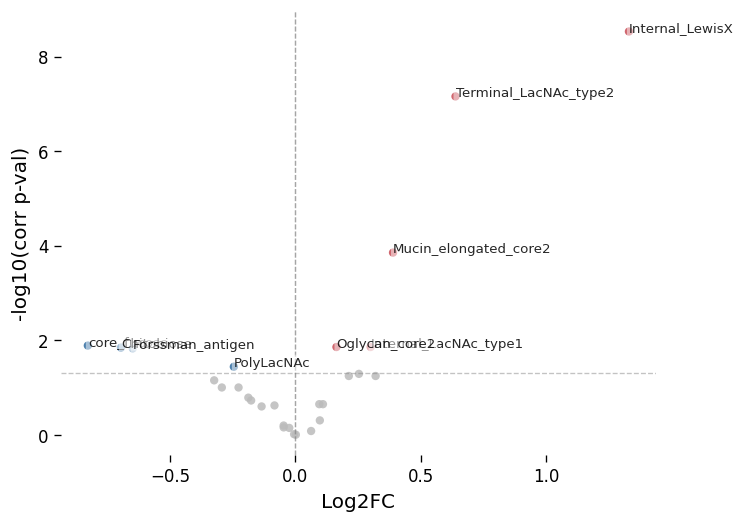

In [8]:
df_diff = pd.read_csv(f"{fp}/lewis_results.csv")
get_volcano(df_diff, n = 30, annotate_volcano=True, filepath=f"{fp}/lewis_volcano.pdf")

# Figure 2A

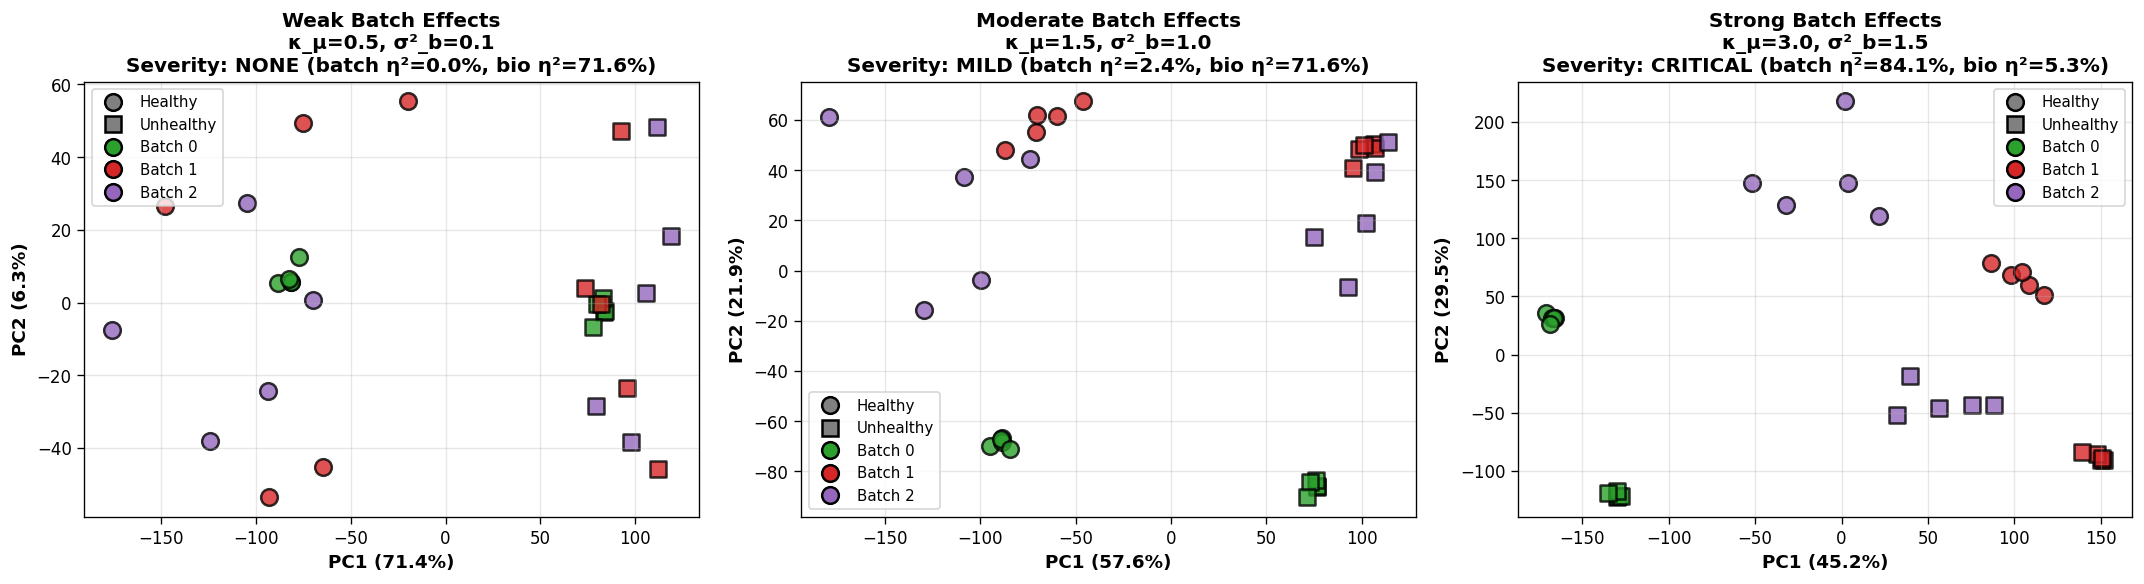


Batch effect progression:
  Weak: NONE (batch η²=0.0%, bio η²=71.6%)
  Moderate: MILD (batch η²=2.4%, bio η²=71.6%)
  Strong: CRITICAL (batch η²=84.1%, bio η²=5.3%)


In [6]:
# Run simulations at different batch effect strengths
configs = [
  {'kappa_mu': 0.5, 'var_b': 0.1, 'label': 'Weak'},
  {'kappa_mu': 1.5, 'var_b': 1.0, 'label': 'Moderate'},
  {'kappa_mu': 3.0, 'var_b': 1.5, 'label': 'Strong'}
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
batch_colors = ['#2ca02c', '#d62728', '#9467bd']
bio_markers = {'healthy': 'o', 'unhealthy': 's'}

for idx, config in enumerate(configs):
  sim_config = {
    'data_source': 'simulated',
    'n_glycans': 50,
    'bio_strength': 5.0,
    'n_H': 15,
    'n_U': 15,
    'n_batches': 3,
    'kappa_mu': config['kappa_mu'],
    'var_b': config['var_b'],
    'random_seeds': [42],
    'output_dir': f'{fp}/results/fig2a_{config["label"].lower()}',
    'verbose': False,
    'save_csv': True
  }
  result = simulate(**sim_config)
  
  # Load data and metadata
  Y_with_batch_clr = pd.read_csv(f'{fp}/results/fig2a_{config["label"].lower()}/2_Y_with_batch_clr_seed42.csv', index_col=0)
  with open(f'{fp}/results/fig2a_{config["label"].lower()}/metadata_seed42.json', 'r', encoding='utf-8', errors='ignore') as f:
    meta = json.load(f)
  
  batch_labels = np.array(meta['sample_info']['batch_labels'])
  quality = meta['quality_checks']['Y_with_batch']
  severity = quality['overall_quality']['severity']
  batch_eta2 = quality['batch_effect']['effect_size_eta2']
  bio_eta2 = quality['bio_effect']['effect_size_eta2']
  
  # PCA
  pca = PCA(n_components=2)
  pc = pca.fit_transform(Y_with_batch_clr.T)
  
  ax = axes[idx]
  
  # Plot by batch with biological group markers
  for batch_id in range(3):
    batch_mask = batch_labels == batch_id
    # Healthy samples in this batch
    healthy_mask = batch_mask & np.array([c.startswith('healthy') for c in Y_with_batch_clr.columns])
    if healthy_mask.any():
      ax.scatter(pc[healthy_mask, 0], pc[healthy_mask, 1], 
                c=batch_colors[batch_id], marker='o', s=100, alpha=0.8,
                edgecolors='black', linewidths=1.5, label=f'Batch {batch_id}' if batch_id == 0 else '')
    # Unhealthy samples in this batch
    unhealthy_mask = batch_mask & np.array([c.startswith('unhealthy') for c in Y_with_batch_clr.columns])
    if unhealthy_mask.any():
      ax.scatter(pc[unhealthy_mask, 0], pc[unhealthy_mask, 1],
                c=batch_colors[batch_id], marker='s', s=100, alpha=0.8,
                edgecolors='black', linewidths=1.5)
  
  ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11, fontweight='bold')
  ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11, fontweight='bold')
  ax.set_title(f'{config["label"]} Batch Effects\nκ_μ={config["kappa_mu"]}, σ²_b={config["var_b"]}\nSeverity: {severity} (batch η²={batch_eta2:.1%}, bio η²={bio_eta2:.1%})', 
              fontsize=12, fontweight='bold')
  ax.grid(alpha=0.3)
  
  # Add custom legend
  from matplotlib.lines import Line2D
  legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Healthy', markeredgecolor='black', markeredgewidth=1.5),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='Unhealthy', markeredgecolor='black', markeredgewidth=1.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=batch_colors[0], markersize=10, label='Batch 0', markeredgecolor='black', markeredgewidth=1.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=batch_colors[1], markersize=10, label='Batch 1', markeredgecolor='black', markeredgewidth=1.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=batch_colors[2], markersize=10, label='Batch 2', markeredgecolor='black', markeredgewidth=1.5)
  ]
  ax.legend(handles=legend_elements, fontsize=9, loc='best')

plt.tight_layout()
plt.savefig(f'{fp}/results/figures/fig2_panel_a.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nBatch effect progression:")
for config in configs:
  with open(f'{fp}/results/fig2a_{config["label"].lower()}/metadata_seed42.json', 'r', encoding='utf-8', errors='ignore') as f:
    meta = json.load(f)
  quality = meta['quality_checks']['Y_with_batch']
  print(f"  {config['label']}: {quality['overall_quality']['severity']} (batch η²={quality['batch_effect']['effect_size_eta2']:.1%}, bio η²={quality['bio_effect']['effect_size_eta2']:.1%})")

# Figure 2B

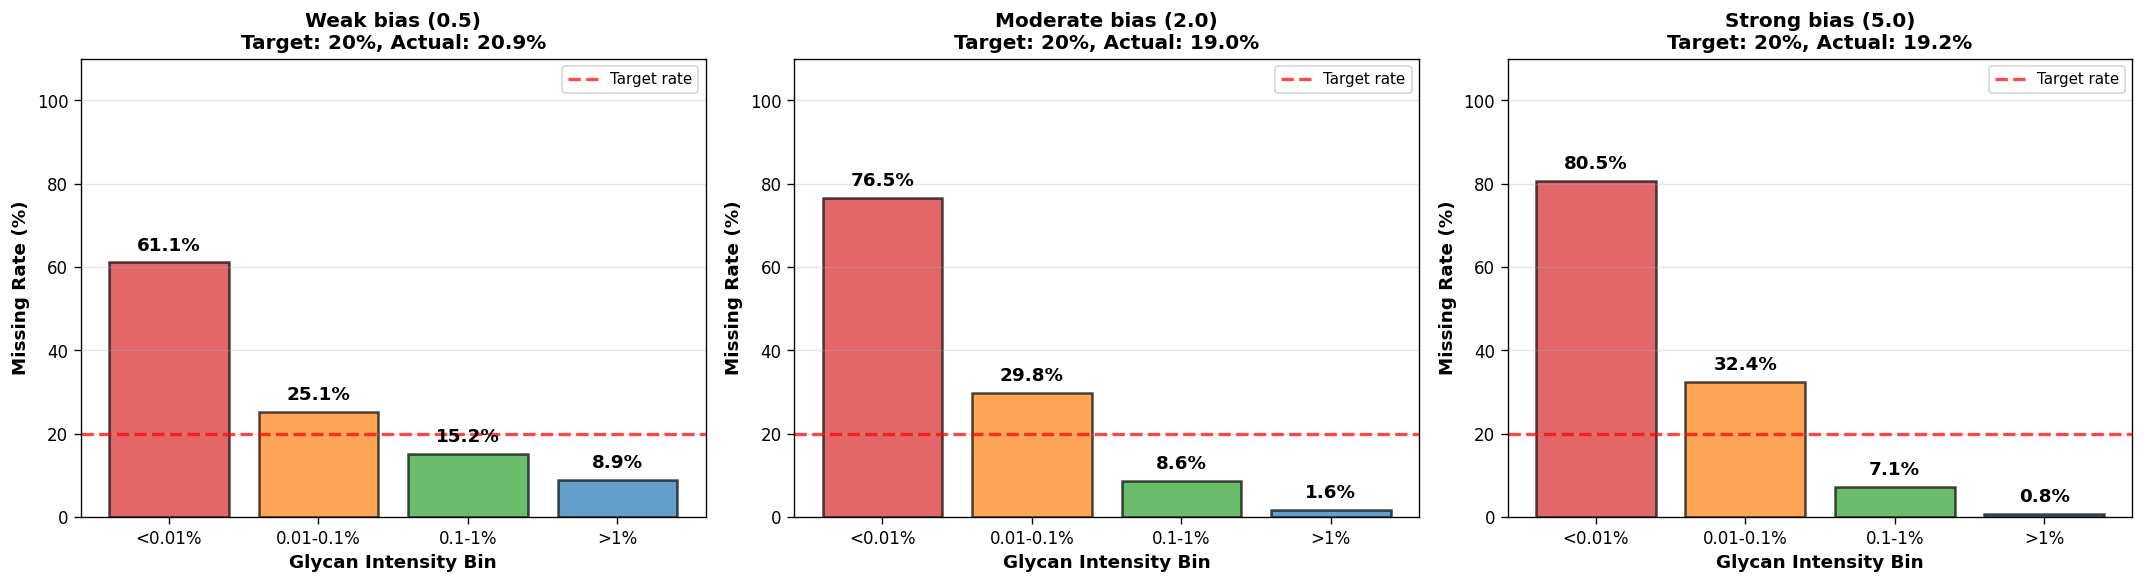


MNAR missingness by intensity bin:

  Weak bias (0.5):
    Target: 20.0%, Actual: 20.9%
          <0.01%: 61.1%
       0.01-0.1%: 25.1%
          0.1-1%: 15.2%
             >1%: 8.9%

  Moderate bias (2.0):
    Target: 20.0%, Actual: 19.0%
          <0.01%: 76.5%
       0.01-0.1%: 29.8%
          0.1-1%: 8.6%
             >1%: 1.6%

  Strong bias (5.0):
    Target: 20.0%, Actual: 19.2%
          <0.01%: 80.5%
       0.01-0.1%: 32.4%
          0.1-1%: 7.1%
             >1%: 0.8%


In [10]:
# Run simulations with different MNAR bias strengths
bias_configs = [
  {'mnar_bias': 0.5, 'label': 'Weak bias (0.5)'},
  {'mnar_bias': 2.0, 'label': 'Moderate bias (2.0)'},
  {'mnar_bias': 5.0, 'label': 'Strong bias (5.0)'}
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, config in enumerate(bias_configs):
  sim_config = {
    'data_source': 'simulated',
    'n_glycans': 50,
    'n_H': 20,
    'n_U': 20,
    'n_batches': 2,
    'kappa_mu': 1.0,
    'var_b': 0.3,
    'missing_fraction': 0.20,
    'mnar_bias': config['mnar_bias'],
    'random_seeds': [42],
    'output_dir': f'{fp}/results/fig2b_bias{config["mnar_bias"]}',
    'verbose': False,
    'save_csv': True
  }
  result = simulate(**sim_config)
  
  # Load metadata and extract missingness diagnostics
  with open(f'{fp}/results/fig2b_bias{config["mnar_bias"]}/metadata_seed42.json', 'r', encoding='utf-8', errors='ignore') as f:
    meta = json.load(f)
  
  missing_diag = meta['quality_checks']['missingness']
  missing_by_intensity = missing_diag['missing_rate_by_intensity']
  
  # Filter to only bins with data
  available_bins = [k for k, v in missing_by_intensity.items() if v > 0 or k in missing_by_intensity]
  rates = [missing_by_intensity[k] * 100 for k in available_bins]
  colors_map = {'<0.01%': '#d62728', '0.01-0.1%': '#ff7f0e', '0.1-1%': '#2ca02c', '>1%': '#1f77b4'}
  bar_colors = [colors_map[k] for k in available_bins]
  
  ax = axes[idx]
  bars = ax.bar(available_bins, rates, color=bar_colors, alpha=0.7, edgecolor='black', linewidth=1.5)
  
  # Add value labels on bars
  for bar, rate in zip(bars, rates):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
           f'{rate:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
  
  ax.set_xlabel('Glycan Intensity Bin', fontsize=11, fontweight='bold')
  ax.set_ylabel('Missing Rate (%)', fontsize=11, fontweight='bold')
  ax.set_title(f'{config["label"]}\nTarget: {sim_config["missing_fraction"]:.0%}, Actual: {missing_diag["missing_fraction_actual"]:.1%}',
              fontsize=12, fontweight='bold')
  ax.set_ylim(0, 110)
  ax.grid(alpha=0.3, axis='y')
  ax.axhline(y=sim_config['missing_fraction'] * 100, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Target rate')
  ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{fp}/results/figures/fig2_panel_b.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nMNAR missingness by intensity bin:")
for config in bias_configs:
  with open(f'{fp}/results/fig2b_bias{config["mnar_bias"]}/metadata_seed42.json', 'r', encoding='utf-8', errors='ignore') as f:
    meta = json.load(f)
  missing_diag = meta['quality_checks']['missingness']
  print(f"\n  {config['label']}:")
  print(f"    Target: {missing_diag['missing_fraction_target']:.1%}, Actual: {missing_diag['missing_fraction_actual']:.1%}")
  for k, v in missing_diag['missing_rate_by_intensity'].items():
    if v > 0:
      print(f"    {k:>12}: {v:.1%}")

# Figure 2C

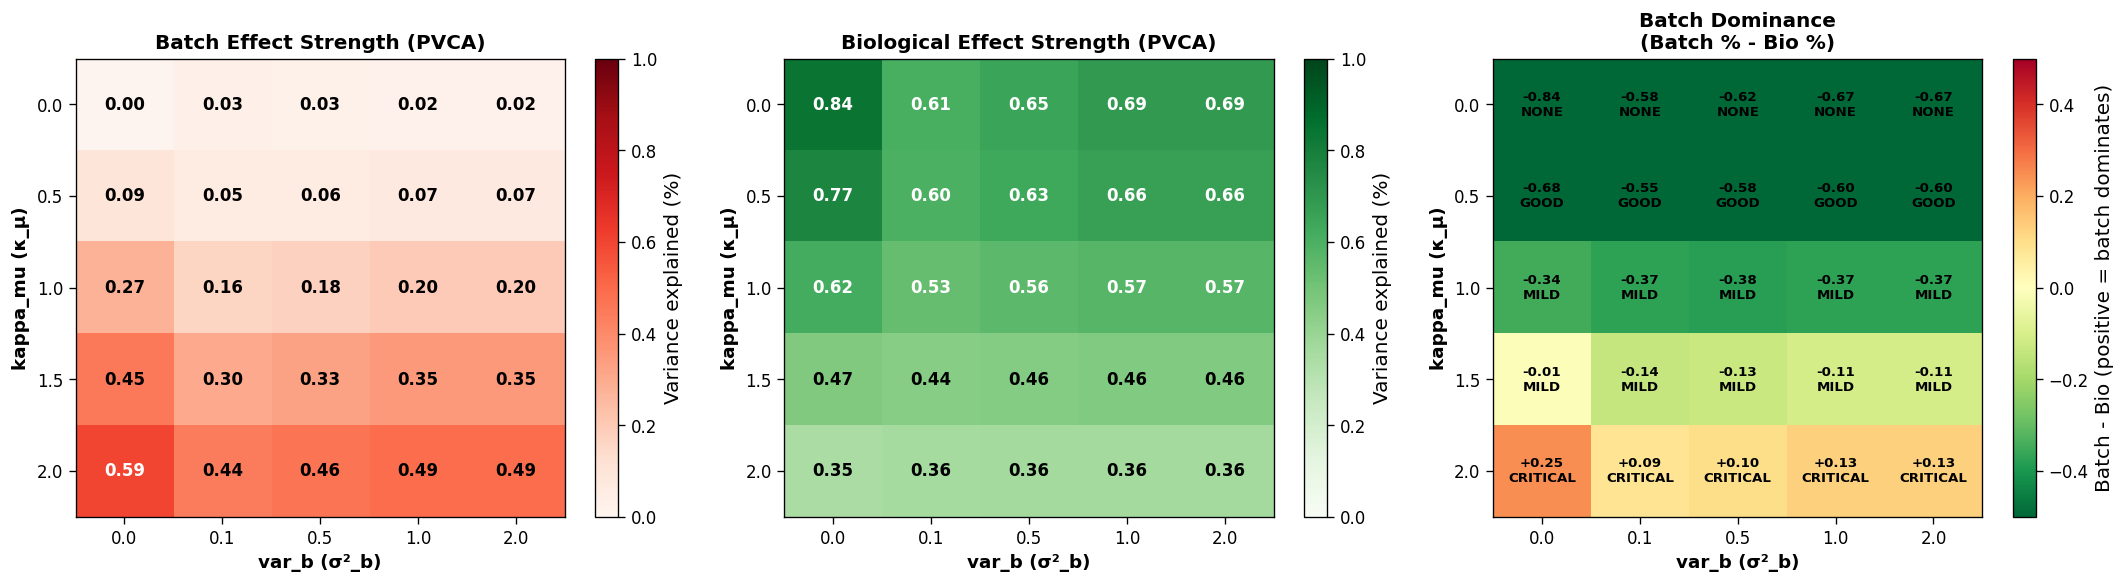


Parameter grid results:
   κ_μ   σ²_b   Batch η²     Bio η²   Dominance   Severity
------------------------------------------------------------
   0.0    0.0      0.004      0.840      -0.835       NONE
   0.0    0.1      0.031      0.608      -0.577       NONE
   0.0    0.5      0.026      0.649      -0.624       NONE
   0.0    1.0      0.021      0.691      -0.670       NONE
   0.0    2.0      0.021      0.691      -0.670       NONE
   0.5    0.0      0.095      0.772      -0.678       GOOD
   0.5    0.1      0.054      0.600      -0.546       GOOD
   0.5    0.5      0.058      0.635      -0.576       GOOD
   0.5    1.0      0.067      0.664      -0.597       GOOD
   0.5    2.0      0.067      0.664      -0.597       GOOD
   1.0    0.0      0.275      0.619      -0.344       MILD
   1.0    0.1      0.161      0.535      -0.374       MILD
   1.0    0.5      0.176      0.557      -0.381       MILD
   1.0    1.0      0.197      0.572      -0.374       MILD
   1.0    2.0      0.197     

In [12]:
# Run parameter grid
kappa_mu_values = [0.0, 0.5, 1.0, 1.5, 2.0]
var_b_values = [0.0, 0.1, 0.5, 1.0, 2.0]

batch_eta2_grid = np.zeros((len(kappa_mu_values), len(var_b_values)))
bio_eta2_grid = np.zeros((len(kappa_mu_values), len(var_b_values)))
severity_grid = []

for i, kappa_mu in enumerate(kappa_mu_values):
  severity_row = []
  for j, var_b in enumerate(var_b_values):
    sim_config = {
      'data_source': 'simulated',
      'n_glycans': 50,
      'bio_strength': 1.5,
      'n_H': 15,
      'n_U': 15,
      'n_batches': 3,
      'kappa_mu': kappa_mu,
      'var_b': var_b,
      'random_seeds': [42],
      'output_dir': f'{fp}/results/fig2c_kappa{kappa_mu}_var{var_b}',
      'verbose': False,
      'save_csv': False
    }
    result = simulate(**sim_config)
    
    with open(f'{fp}/results/fig2c_kappa{kappa_mu}_var{var_b}/metadata_seed42.json', 'r', encoding='utf-8', errors='ignore') as f:
      meta = json.load(f)
    
    quality = meta['quality_checks']['Y_with_batch']
    batch_eta2_grid[i, j] = quality['pvca']['batch_variance_pct'] / 100
    bio_eta2_grid[i, j] = quality['pvca']['bio_variance_pct'] / 100
    severity_row.append(quality['overall_quality']['severity'])
  severity_grid.append(severity_row)

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Batch effect eta2
im1 = axes[0].imshow(batch_eta2_grid, cmap='Reds', aspect='auto', vmin=0, vmax=1.0)
axes[0].set_xticks(range(len(var_b_values)))
axes[0].set_yticks(range(len(kappa_mu_values)))
axes[0].set_xticklabels([f'{v}' for v in var_b_values], fontsize=10)
axes[0].set_yticklabels([f'{k}' for k in kappa_mu_values], fontsize=10)
axes[0].set_xlabel('var_b (σ²_b)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('kappa_mu (κ_μ)', fontsize=11, fontweight='bold')
axes[0].set_title('Batch Effect Strength (PVCA)', fontsize=12, fontweight='bold')
for i in range(len(kappa_mu_values)):
  for j in range(len(var_b_values)):
    text = axes[0].text(j, i, f'{batch_eta2_grid[i, j]:.2f}', ha='center', va='center', color='white' if batch_eta2_grid[i, j] > 0.5 else 'black', fontsize=10, fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='Variance explained (%)')

# Panel 2: Biological effect eta2
im2 = axes[1].imshow(bio_eta2_grid, cmap='Greens', aspect='auto', vmin=0, vmax=1.0)
axes[1].set_xticks(range(len(var_b_values)))
axes[1].set_yticks(range(len(kappa_mu_values)))
axes[1].set_xticklabels([f'{v}' for v in var_b_values], fontsize=10)
axes[1].set_yticklabels([f'{k}' for k in kappa_mu_values], fontsize=10)
axes[1].set_xlabel('var_b (σ²_b)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('kappa_mu (κ_μ)', fontsize=11, fontweight='bold')
axes[1].set_title('Biological Effect Strength (PVCA)', fontsize=12, fontweight='bold')
for i in range(len(kappa_mu_values)):
  for j in range(len(var_b_values)):
    text = axes[1].text(j, i, f'{bio_eta2_grid[i, j]:.2f}', ha='center', va='center', color='white' if bio_eta2_grid[i, j] > 0.5 else 'black', fontsize=10, fontweight='bold')
plt.colorbar(im2, ax=axes[1], label='Variance explained (%)')

# Panel 3: Batch dominance (batch_eta2 - bio_eta2)
dominance = batch_eta2_grid - bio_eta2_grid
im3 = axes[2].imshow(dominance, cmap='RdYlGn_r', aspect='auto', vmin=-0.5, vmax=0.5)
axes[2].set_xticks(range(len(var_b_values)))
axes[2].set_yticks(range(len(kappa_mu_values)))
axes[2].set_xticklabels([f'{v}' for v in var_b_values], fontsize=10)
axes[2].set_yticklabels([f'{k}' for k in kappa_mu_values], fontsize=10)
axes[2].set_xlabel('var_b (σ²_b)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('kappa_mu (κ_μ)', fontsize=11, fontweight='bold')
axes[2].set_title('Batch Dominance\n(Batch % - Bio %)', fontsize=12, fontweight='bold')
for i in range(len(kappa_mu_values)):
  for j in range(len(var_b_values)):
    sev = severity_grid[i][j]
    text = axes[2].text(j, i, f'{dominance[i, j]:+.2f}\n{sev}', ha='center', va='center', color='black', fontsize=8, fontweight='bold')
plt.colorbar(im3, ax=axes[2], label='Batch - Bio (positive = batch dominates)')

plt.tight_layout()
plt.savefig(f'{fp}/results/figures/fig2_panel_c.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nParameter grid results:")
print(f"{'κ_μ':>6} {'σ²_b':>6} {'Batch η²':>10} {'Bio η²':>10} {'Dominance':>11} {'Severity':>10}")
print("-" * 60)
for i, kappa_mu in enumerate(kappa_mu_values):
  for j, var_b in enumerate(var_b_values):
    print(f"{kappa_mu:>6.1f} {var_b:>6.1f} {batch_eta2_grid[i,j]:>10.3f} {bio_eta2_grid[i,j]:>10.3f} {dominance[i,j]:>+11.3f} {severity_grid[i][j]:>10}")

# Figure 3

C:\Users\Daniel\AppData\Local\Temp\ipykernel_13412\1435088193.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  severity_f1 = agg_results.groupby(['method', 'batch_severity'])['f1'].mean().unstack()


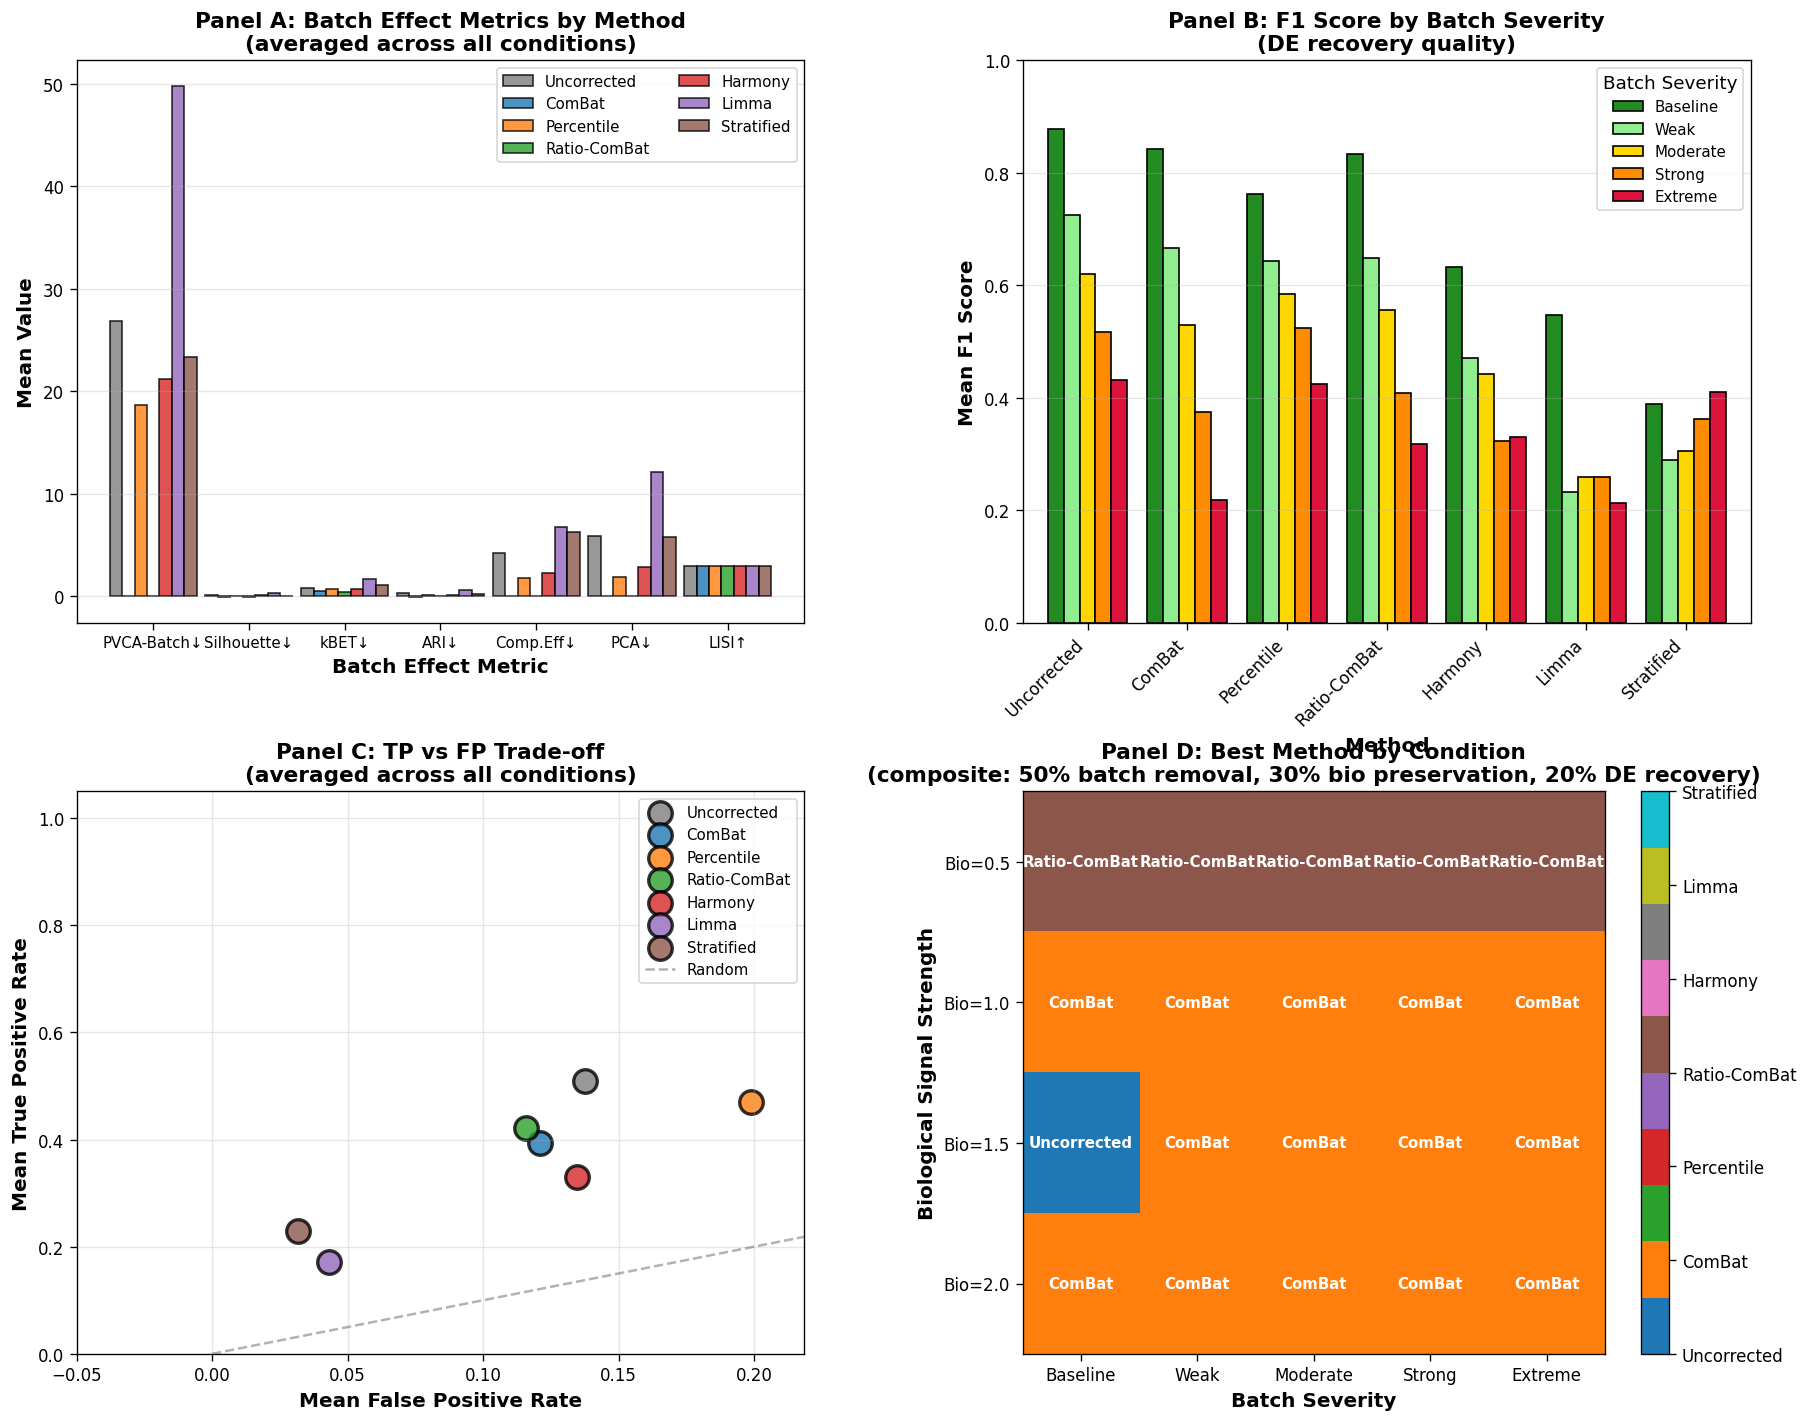

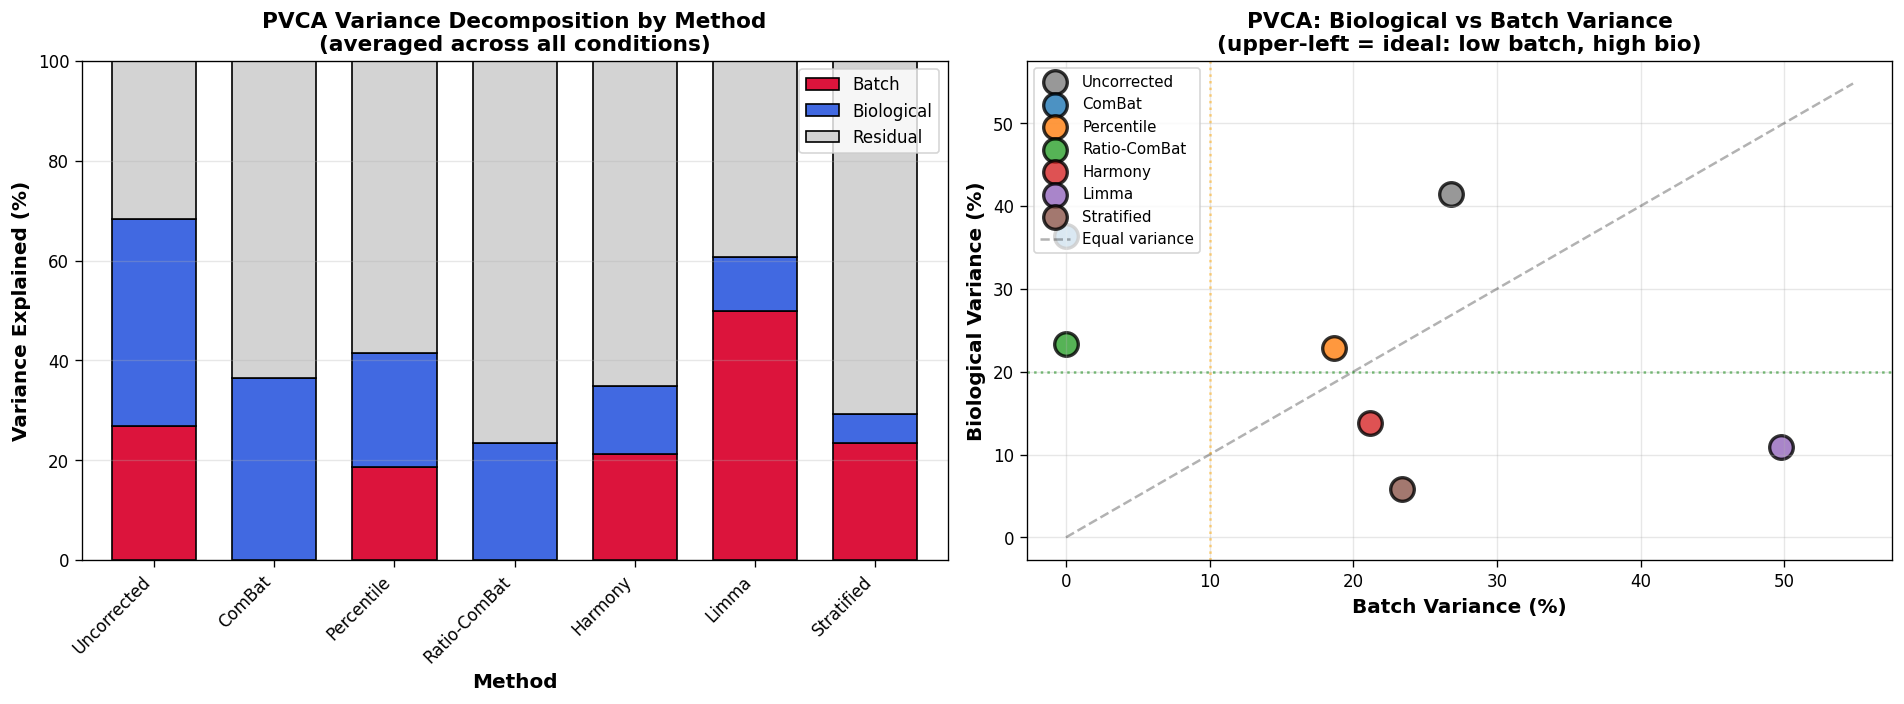


=== FIGURE 3 SUMMARY ===

PVCA Variance Decomposition (mean % across all conditions)
              PVCA_batch_variance  PVCA_bio_variance  PVCA_residual_variance
Uncorrected                 26.82              41.40                   31.78
ComBat                       0.00              36.42                   63.58
Percentile                  18.65              22.91                   58.44
Ratio-ComBat                 0.00              23.38                   76.62
Harmony                     21.18              13.77                   65.05
Limma                       49.80              10.92                   39.27
Stratified                  23.36               5.84                   70.79

PVCA Signal-to-Batch Ratio (Bio/Batch, higher = better)
Uncorrected     1.544000e+00
ComBat          3.641685e+07
Percentile      1.228000e+00
Ratio-ComBat    3.335223e+06
Harmony         6.500000e-01
Limma           2.190000e-01
Stratified      2.500000e-01
Name: bio_to_batch_ratio, dtype: float

In [10]:
# Load aggregated results
agg_results = pd.read_csv(f'{fp}/results/method_comparison_aggregated.csv')

# Figure 3: 2x2 grid
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Panel A: Batch effect reduction across methods (aggregate across all conditions)
ax1 = fig.add_subplot(gs[0, 0])
batch_metrics = ['PVCA_batch_variance', 'silhouette', 'kBET', 'ARI', 'comp_effect', 'pca_batch', 'LISI']
method_order = ['uncorrected', 'combat', 'percentile', 'ratio', 'harmony', 'limma', 'stratified']
method_labels = ['Uncorrected', 'ComBat', 'Percentile', 'Ratio-ComBat', 'Harmony', 'Limma', 'Stratified']
colors = ['#7f7f7f', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
method_means = agg_results.groupby('method')[batch_metrics].mean()
method_means = method_means.reindex(method_order)
x = np.arange(len(batch_metrics))
width = 0.13
for i, method in enumerate(method_order):
  offset = (i - 3) * width
  values = method_means.loc[method].values
  ax1.bar(x + offset, values, width, label=method_labels[i], color=colors[i], alpha=0.8, edgecolor='black')
ax1.set_xlabel('Batch Effect Metric', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Value', fontsize=12, fontweight='bold')
ax1.set_title('Panel A: Batch Effect Metrics by Method\n(averaged across all conditions)', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(['PVCA-Batch↓', 'Silhouette↓', 'kBET↓', 'ARI↓', 'Comp.Eff↓', 'PCA↓', 'LISI↑'], fontsize=9)
ax1.legend(fontsize=9, ncol=2)
ax1.grid(alpha=0.3, axis='y')

# Panel B: F1 score comparison across batch severity levels
ax2 = fig.add_subplot(gs[0, 1])
agg_results['batch_severity'] = pd.cut(agg_results['kappa_mu'] + agg_results['var_b'], bins=[-0.01, 0.01, 1.0, 1.5, 2.0, 3.0], labels=['Baseline', 'Weak', 'Moderate', 'Strong', 'Extreme'])
severity_f1 = agg_results.groupby(['method', 'batch_severity'])['f1'].mean().unstack()
severity_f1 = severity_f1.reindex(method_order)
severity_f1.plot(kind='bar', ax=ax2, color=['#228B22', '#90EE90', '#FFD700', '#FF8C00', '#DC143C'], edgecolor='black', width=0.8)
ax2.set_xlabel('Method', fontsize=12, fontweight='bold')
ax2.set_ylabel('Mean F1 Score', fontsize=12, fontweight='bold')
ax2.set_title('Panel B: F1 Score by Batch Severity\n(DE recovery quality)', fontsize=13, fontweight='bold')
ax2.set_xticklabels(method_labels, rotation=45, ha='right', fontsize=10)
ax2.legend(title='Batch Severity', fontsize=9)
ax2.grid(alpha=0.3, axis='y')
ax2.set_ylim(0, 1)

# Panel C: TP vs FP rates scatter
ax3 = fig.add_subplot(gs[1, 0])
method_summary = agg_results.groupby('method')[['tp_rate', 'fp_rate']].mean()
method_summary = method_summary.reindex(method_order)
for i, method in enumerate(method_order):
  ax3.scatter(method_summary.loc[method, 'fp_rate'], method_summary.loc[method, 'tp_rate'], 
             s=200, c=colors[i], label=method_labels[i], alpha=0.8, edgecolors='black', linewidths=2)
ax3.set_xlabel('Mean False Positive Rate', fontsize=12, fontweight='bold')
ax3.set_ylabel('Mean True Positive Rate', fontsize=12, fontweight='bold')
ax3.set_title('Panel C: TP vs FP Trade-off\n(averaged across all conditions)', fontsize=13, fontweight='bold')
ax3.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)
ax3.set_xlim(-0.05, max(method_summary['fp_rate']) * 1.1)
ax3.set_ylim(0, 1.05)

# Panel D: Heatmap of best method by condition using composite score
ax4 = fig.add_subplot(gs[1, 1])
agg_results['batch_severity_score'] = agg_results['kappa_mu'] + agg_results['var_b']
# Composite score: minimize batch, maximize bio preservation, maximize DE recovery
# Normalize each component to [0,1] scale within each condition
pivot_data = []
bio_values = sorted(agg_results['bio_strength'].unique())
severity_bins = [(-0.01, 0.01), (0.01, 1.0), (1.0, 1.5), (1.5, 2.0), (2.0, 3.0)]
severity_labels = ['Baseline', 'Weak', 'Moderate', 'Strong', 'Extreme']
for bio in bio_values:
  row = []
  for (low, high), label in zip(severity_bins, severity_labels):
    subset = agg_results[(agg_results['bio_strength'] == bio) & (agg_results['batch_severity_score'] > low) & (agg_results['batch_severity_score'] <= high)]
    if len(subset) > 0:
      subset = subset.copy()
      subset['pvca_batch_norm'] = (subset['PVCA_batch_variance'].max() - subset['PVCA_batch_variance']) / (subset['PVCA_batch_variance'].max() - subset['PVCA_batch_variance'].min() + 1e-6)
      subset['pvca_bio_norm'] = (subset['PVCA_bio_variance'] - subset['PVCA_bio_variance'].min()) / (subset['PVCA_bio_variance'].max() - subset['PVCA_bio_variance'].min() + 1e-6)
      subset['f1_norm'] = (subset['f1'] - subset['f1'].min()) / (subset['f1'].max() - subset['f1'].min() + 1e-6)
      subset['composite_score'] = 0.5 * subset['pvca_batch_norm'] + 0.3 * subset['pvca_bio_norm'] + 0.2 * subset['f1_norm']
      best_method = subset.loc[subset['composite_score'].idxmax(), 'method']
      row.append(method_order.index(best_method))
    else:
      row.append(-1)
  pivot_data.append(row)
pivot_df = pd.DataFrame(pivot_data, index=[f'Bio={b}' for b in bio_values], columns=severity_labels)
im = ax4.imshow(pivot_df.values, cmap='tab10', aspect='auto', vmin=0, vmax=len(method_order)-1)
ax4.set_xticks(range(len(severity_labels)))
ax4.set_yticks(range(len(bio_values)))
ax4.set_xticklabels(severity_labels, fontsize=10)
ax4.set_yticklabels([f'Bio={b}' for b in bio_values], fontsize=10)
ax4.set_xlabel('Batch Severity', fontsize=12, fontweight='bold')
ax4.set_ylabel('Biological Signal Strength', fontsize=12, fontweight='bold')
ax4.set_title('Panel D: Best Method by Condition\n(composite: 50% batch removal, 30% bio preservation, 20% DE recovery)', fontsize=13, fontweight='bold')
for i in range(len(bio_values)):
  for j in range(len(severity_labels)):
    method_idx = pivot_df.iloc[i, j]
    if method_idx >= 0:
      ax4.text(j, i, method_labels[method_idx], ha='center', va='center', color='white', fontsize=9, fontweight='bold')
cbar = plt.colorbar(im, ax=ax4, ticks=range(len(method_order)))
cbar.set_ticklabels(method_labels)

plt.savefig(f'{fp}/results/figures/fig3_method_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

# PVCA variance decomposition
fig_pvca, (ax_pvca1, ax_pvca2) = plt.subplots(1, 2, figsize=(16, 6))
# Left: Stacked bar showing PVCA decomposition by method
pvca_decomp = agg_results.groupby('method')[['PVCA_batch_variance', 'PVCA_bio_variance', 'PVCA_residual_variance']].mean()
pvca_decomp = pvca_decomp.reindex(method_order)
pvca_decomp.plot(kind='bar', stacked=True, ax=ax_pvca1, color=['#DC143C', '#4169E1', '#D3D3D3'], edgecolor='black', width=0.7)
ax_pvca1.set_xlabel('Method', fontsize=12, fontweight='bold')
ax_pvca1.set_ylabel('Variance Explained (%)', fontsize=12, fontweight='bold')
ax_pvca1.set_title('PVCA Variance Decomposition by Method\n(averaged across all conditions)', fontsize=13, fontweight='bold')
ax_pvca1.set_xticklabels(method_labels, rotation=45, ha='right', fontsize=10)
ax_pvca1.legend(['Batch', 'Biological', 'Residual'], fontsize=10, loc='upper right')
ax_pvca1.set_ylim(0, 100)
ax_pvca1.grid(alpha=0.3, axis='y')
# Right: Bio vs Batch variance scatter
method_pvca = agg_results.groupby('method')[['PVCA_batch_variance', 'PVCA_bio_variance']].mean()
method_pvca = method_pvca.reindex(method_order)
for i, method in enumerate(method_order):
  ax_pvca2.scatter(method_pvca.loc[method, 'PVCA_batch_variance'], method_pvca.loc[method, 'PVCA_bio_variance'], 
                  s=200, c=colors[i], label=method_labels[i], alpha=0.8, edgecolors='black', linewidths=2)
ax_pvca2.plot([0, max(method_pvca['PVCA_batch_variance'])*1.1], [0, max(method_pvca['PVCA_batch_variance'])*1.1], 'k--', alpha=0.3, label='Equal variance')
ax_pvca2.set_xlabel('Batch Variance (%)', fontsize=12, fontweight='bold')
ax_pvca2.set_ylabel('Biological Variance (%)', fontsize=12, fontweight='bold')
ax_pvca2.set_title('PVCA: Biological vs Batch Variance\n(upper-left = ideal: low batch, high bio)', fontsize=13, fontweight='bold')
ax_pvca2.legend(fontsize=9)
ax_pvca2.grid(alpha=0.3)
ax_pvca2.axvline(x=10, color='orange', linestyle=':', alpha=0.5, label='Batch<10% threshold')
ax_pvca2.axhline(y=20, color='green', linestyle=':', alpha=0.5, label='Bio>20% threshold')
plt.tight_layout()
plt.savefig(f'{fp}/results/figures/fig3_pvca_decomposition.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n=== FIGURE 3 SUMMARY ===")
print("\nPVCA Variance Decomposition (mean % across all conditions)")
pvca_stats = agg_results.groupby('method')[['PVCA_batch_variance', 'PVCA_bio_variance', 'PVCA_residual_variance']].mean()
pvca_stats = pvca_stats.reindex(method_order)
pvca_stats.index = method_labels
print(pvca_stats.round(2))
print("\nPVCA Signal-to-Batch Ratio (Bio/Batch, higher = better)")
pvca_stats['bio_to_batch_ratio'] = pvca_stats['PVCA_bio_variance'] / (pvca_stats['PVCA_batch_variance'] + 1e-6)
print(pvca_stats['bio_to_batch_ratio'].round(3))
print("\nPanel A: Mean batch effect metrics")
print(method_means.round(3))
print("\nPanel B: F1 by severity")
print(severity_f1.round(3))
print("\nPanel C: TP vs FP rates")
print(method_summary.round(3))
print("\nPanel D: Winner distribution (PVCA-based)")
print(pd.Series(pivot_df.values.flatten()).value_counts())

# Sensitivity analysis: Winner consistency across different criteria
print("\n=== SENSITIVITY ANALYSIS: WINNER CONSISTENCY ===")
scoring_schemes = {
  'PVCA-only': {'PVCA_batch_variance': -1.0},
  'PVCA+Bio': {'PVCA_batch_variance': -0.6, 'PVCA_bio_variance': 0.4},
  'Composite (main)': {'PVCA_batch_variance': -0.5, 'PVCA_bio_variance': 0.3, 'f1': 0.2},
  'F1-only': {'f1': 1.0}
}
sensitivity_results = {}
for scheme_name, weights in scoring_schemes.items():
  pivot_data = []
  for bio in bio_values:
    row = []
    for (low, high), label in zip(severity_bins, severity_labels):
      subset = agg_results[(agg_results['bio_strength'] == bio) & (agg_results['batch_severity_score'] > low) & (agg_results['batch_severity_score'] <= high)]
      if len(subset) > 0:
        subset = subset.copy()
        subset['score'] = 0
        for metric, weight in weights.items():
          if weight < 0:
            subset['score'] += weight * subset[metric]
          else:
            subset['score'] += weight * subset[metric]
        best_method = subset.loc[subset['score'].idxmax(), 'method']
        row.append(best_method)
      else:
        row.append('none')
    pivot_data.append(row)
  sensitivity_results[scheme_name] = pd.DataFrame(pivot_data, index=[f'Bio={b}' for b in bio_values], columns=severity_labels)
# Check consistency
print("\nWinner counts by scoring scheme:")
for scheme_name, df in sensitivity_results.items():
  counts = pd.Series(df.values.flatten()).value_counts()
  print(f"\n{scheme_name}:")
  print(counts)
# Calculate agreement between schemes
from sklearn.metrics import cohen_kappa_score
print("\nAgreement between scoring schemes (Cohen's kappa):")
schemes = list(scoring_schemes.keys())
for i, scheme1 in enumerate(schemes):
  for scheme2 in schemes[i+1:]:
    flat1 = sensitivity_results[scheme1].values.flatten()
    flat2 = sensitivity_results[scheme2].values.flatten()
    mask = (flat1 != 'none') & (flat2 != 'none')
    if mask.sum() > 0:
      kappa = cohen_kappa_score(flat1[mask], flat2[mask])
      print(f"  {scheme1} vs {scheme2}: κ = {kappa:.3f}")

Testing 36 weight combinations

Fraction of (weight combo × condition) cells where method wins:
  ComBat: 63.9%
  Percentile: 4.9%
  Ratio-ComBat: 10.8%
  Harmony: 3.6%
  Limma: 16.8%
  Stratified: 0.0%

Mean cell stability (plurality winner holds): 80.6%
Min cell stability: 52.8%


C:\Users\Daniel\AppData\Local\Temp\ipykernel_19948\2604114659.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(method_labels, rotation=30, ha='right')


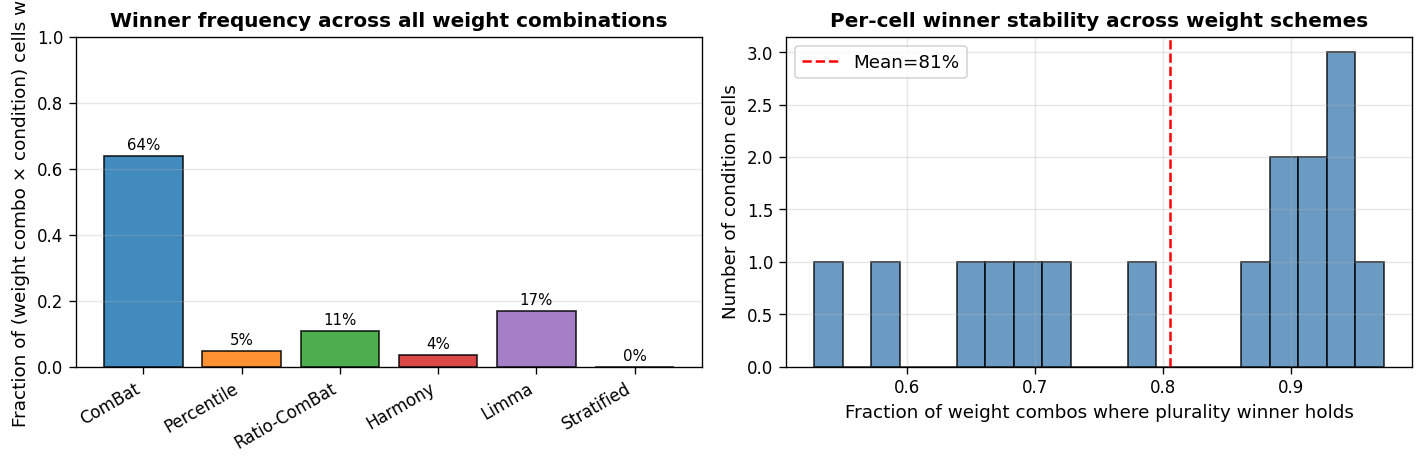

In [5]:
agg_results = pd.read_csv(f'{fp}/results/method_comparison_aggregated.csv')
method_order = ['combat', 'percentile', 'ratio', 'harmony', 'limma', 'stratified']
method_labels = ['ComBat', 'Percentile', 'Ratio-ComBat', 'Harmony', 'Limma', 'Stratified']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
# Grid over (w_batch, w_bio, w_de) on 0.1 resolution, summing to 1
steps = np.round(np.arange(0.1, 0.9, 0.1), 1)
weight_combos = [(wb, wbio, wd) for wb, wbio, wd in iproduct(steps, steps, steps)
                 if abs(wb + wbio + wd - 1.0) < 1e-6]
print(f"Testing {len(weight_combos)} weight combinations")
# For each weight combo, find the best method per condition cell, then aggregate
win_counts = {m: 0 for m in method_order}
total_decisions = 0
agg_results = agg_results.copy()
agg_results['batch_severity_score'] = agg_results['kappa_mu'] + agg_results['var_b']
severity_bins = [(0, 1.0), (1.0, 1.5), (1.5, 2.0), (2.0, 3.0)]
severity_labels = ['Weak', 'Moderate', 'Strong', 'Extreme']
bio_values = sorted(agg_results['bio_strength'].unique())
# Store per-combo winner grids to compute stability
winner_grids = []
for wb, wbio, wd in weight_combos:
  grid = []
  for bio in bio_values:
    for (low, high) in severity_bins:
      subset = agg_results[
        (agg_results['bio_strength'] == bio) &
        (agg_results['batch_severity_score'] > low) &
        (agg_results['batch_severity_score'] <= high)
      ].copy()
      if len(subset) == 0:
        continue
      # Normalize each component within this condition cell
      for col, sign in [('PVCA_batch_variance', -1), ('PVCA_bio_variance', 1), ('f1', 1)]:
        lo, hi = subset[col].min(), subset[col].max()
        subset[f'{col}_norm'] = sign * (subset[col] - lo) / (hi - lo + 1e-6)
      subset['composite'] = (wb   * subset['PVCA_batch_variance_norm']
                             + wbio * subset['PVCA_bio_variance_norm']
                             + wd   * subset['f1_norm'])
      best = subset.loc[subset['composite'].idxmax(), 'method']
      win_counts[best] += 1
      total_decisions += 1
      grid.append(best)
  winner_grids.append(grid)
# Fraction of weight combinations where each method wins
win_frac = {m: win_counts[m] / total_decisions for m in method_order}
print("\nFraction of (weight combo × condition) cells where method wins:")
for m, f in zip(method_labels, [win_frac[m] for m in method_order]):
  print(f"  {m}: {f:.1%}")
# Per-cell stability: how often does the plurality winner change across weight combos?
winner_grid_df = pd.DataFrame(winner_grids)  # (n_combos, n_cells)
cell_plurality = winner_grid_df.mode(axis=0).iloc[0]
cell_stability = winner_grid_df.apply(lambda col: (col == col.mode()[0]).mean())
print(f"\nMean cell stability (plurality winner holds): {cell_stability.mean():.1%}")
print(f"Min cell stability: {cell_stability.min():.1%}")
# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
fracs = [win_frac[m] for m in method_order]
bars = ax.bar(method_labels, fracs, color=colors, edgecolor='black', alpha=0.85)
ax.set_ylabel('Fraction of (weight combo × condition) cells won', fontsize=11)
ax.set_title('Winner frequency across all weight combinations', fontsize=12, fontweight='bold')
ax.set_xticklabels(method_labels, rotation=30, ha='right')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3, axis='y')
for bar, f in zip(bars, fracs):
  ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{f:.0%}',
          ha='center', va='bottom', fontsize=9)
ax = axes[1]
ax.hist(cell_stability, bins=20, color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(cell_stability.mean(), color='red', linestyle='--', label=f'Mean={cell_stability.mean():.0%}')
ax.set_xlabel('Fraction of weight combos where plurality winner holds', fontsize=11)
ax.set_ylabel('Number of condition cells', fontsize=11)
ax.set_title('Per-cell winner stability across weight schemes', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{fp}/results/figures/weighting_sensitivity.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Load detailed results to show distributions
detailed = pd.read_csv(f'{fp}/results/method_comparison_detailed.csv')
agg_results = pd.read_csv(f'{fp}/results/method_comparison_aggregated.csv')

# Show FP rate by batch severity (revealing when FPs occur)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

method_order = ['uncorrected', 'combat', 'percentile', 'ratio', 'harmony', 'limma', 'stratified']
method_labels = ['Uncorrected', 'ComBat', 'Percentile', 'Ratio-ComBat', 'Harmony', 'Limma', 'Stratified']
colors = ['#7f7f7f', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Panel: FP rate by batch severity
detailed['batch_severity'] = detailed['kappa_mu'] + detailed['var_b']
detailed['severity_cat'] = pd.cut(detailed['batch_severity'], bins=[-0.01, 0.01, 1.0, 1.5, 2.0, 3.0], labels=['Baseline', 'Weak', 'Moderate', 'Strong', 'Extreme'])
fp_by_severity = detailed.groupby(['method', 'severity_cat'])['fp_rate'].mean().unstack()
fp_by_severity = fp_by_severity.reindex(method_order)
fp_by_severity.plot(kind='bar', ax=axes[0], color=['#228B22', '#90EE90', '#FFD700', '#FF8C00', '#DC143C'], edgecolor='black', width=0.8)
axes[0].set_xlabel('Method', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Mean False Positive Rate', fontsize=11, fontweight='bold')
axes[0].set_title('FP Rate by Batch Severity\n(when do methods create false positives?)', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(method_labels, rotation=45, ha='right', fontsize=10)
axes[0].legend(title='Batch Severity', fontsize=9, loc='upper left')
axes[0].grid(alpha=0.3, axis='y')
axes[0].axhline(y=0.05, color='red', linestyle='--', alpha=0.5, linewidth=1, label='5% threshold')

# Panel: Net benefit (TP recovery - FP inflation)
method_net = []
for method in method_order:
  method_data = detailed[detailed['method'] == method]
  tp_gain = method_data['tp_rate'].mean()
  fp_cost = method_data['fp_rate'].mean()
  net_benefit = tp_gain - fp_cost
  method_net.append({'method': method, 'tp_gain': tp_gain, 'fp_cost': fp_cost, 'net_benefit': net_benefit})
net_df = pd.DataFrame(method_net)
x = np.arange(len(method_order))
width = 0.35
bars1 = axes[1].bar(x - width/2, net_df['tp_gain'], width, label='TP Recovery', color='#2ca02c', alpha=0.8, edgecolor='black')
bars2 = axes[1].bar(x + width/2, net_df['fp_cost'], width, label='FP Inflation', color='#d62728', alpha=0.8, edgecolor='black')
axes[1].set_xlabel('Method', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Rate', fontsize=11, fontweight='bold')
axes[1].set_title('TP Recovery vs FP Inflation\n(benefit vs cost trade-off)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(method_labels, rotation=45, ha='right', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, axis='y')
for i, (tp, fp) in enumerate(zip(net_df['tp_gain'], net_df['fp_cost'])):
  net = tp - fp
  color = 'green' if net > 0 else 'red'
  axes[1].text(i, max(tp, fp) + 0.05, f'Net: {net:+.2f}', ha='center', fontsize=8, fontweight='bold', color=color)

# Panel: Precision-Recall curve (better than TP-FP for imbalanced data)
method_summary = agg_results.groupby('method').agg({'tp_rate': 'mean', 'fp_rate': 'mean', 'f1': 'mean'}).reset_index()
method_summary['precision'] = method_summary.apply(lambda x: detailed[detailed['method']==x['method']]['tp'].sum() / (detailed[detailed['method']==x['method']]['tp'].sum() + detailed[detailed['method']==x['method']]['fp'].sum()), axis=1)
method_summary['recall'] = method_summary['tp_rate']
method_summary = method_summary.set_index('method').reindex(method_order).reset_index()
for i, row in method_summary.iterrows():
  axes[2].scatter(row['recall'], row['precision'], s=250, c=colors[i], label=method_labels[i], alpha=0.8, edgecolors='black', linewidths=2, zorder=3)
  f1 = row['f1']
  axes[2].annotate(f"F1={f1:.2f}", xy=(row['recall'], row['precision']), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)
axes[2].set_xlabel('Recall (TP Rate)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Precision (1 - FP among positives)', fontsize=11, fontweight='bold')
axes[2].set_title('Precision-Recall Trade-off\n(upper-right is better)', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9, loc='lower left')
axes[2].grid(alpha=0.3)
axes[2].set_xlim(0, 1.05)
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(f'{fp}/results/figures/fig3_panel_c_revised.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Print interpretation
print("\n=== PANEL C INTERPRETATION ===")
print("\nFalse Positive Rates by Batch Severity")
print(fp_by_severity.round(3))
print("\nNet Benefit (TP gain - FP cost)")
print(net_df[['method', 'tp_gain', 'fp_cost', 'net_benefit']].round(3))
print("\nPrecision-Recall")
print(method_summary[['method', 'recall', 'precision', 'f1']].round(3))

# Figure S2

Glycans=25, samples=60: 0.22s ± 0.02s
Glycans=50, samples=60: 0.21s ± 0.02s
Glycans=100, samples=60: 0.17s ± 0.02s
Glycans=150, samples=60: 0.19s ± 0.02s
Glycans=200, samples=60: 0.27s ± 0.03s
Glycans=100, samples=20: 0.16s ± 0.02s
Glycans=100, samples=60: 0.17s ± 0.02s
Glycans=100, samples=120: 0.19s ± 0.02s
Glycans=100, samples=200: 0.23s ± 0.03s
Glycans=100, samples=300: 0.25s ± 0.03s
Simplified: 0.11s ± 0.01s
Hybrid: 0.15s ± 0.02s
Feature baseline: 0.18s ± 0.02s
Feature batch: 0.18s ± 0.03s
Feature missing: 0.24s ± 0.03s
Feature both: 0.24s ± 0.01s


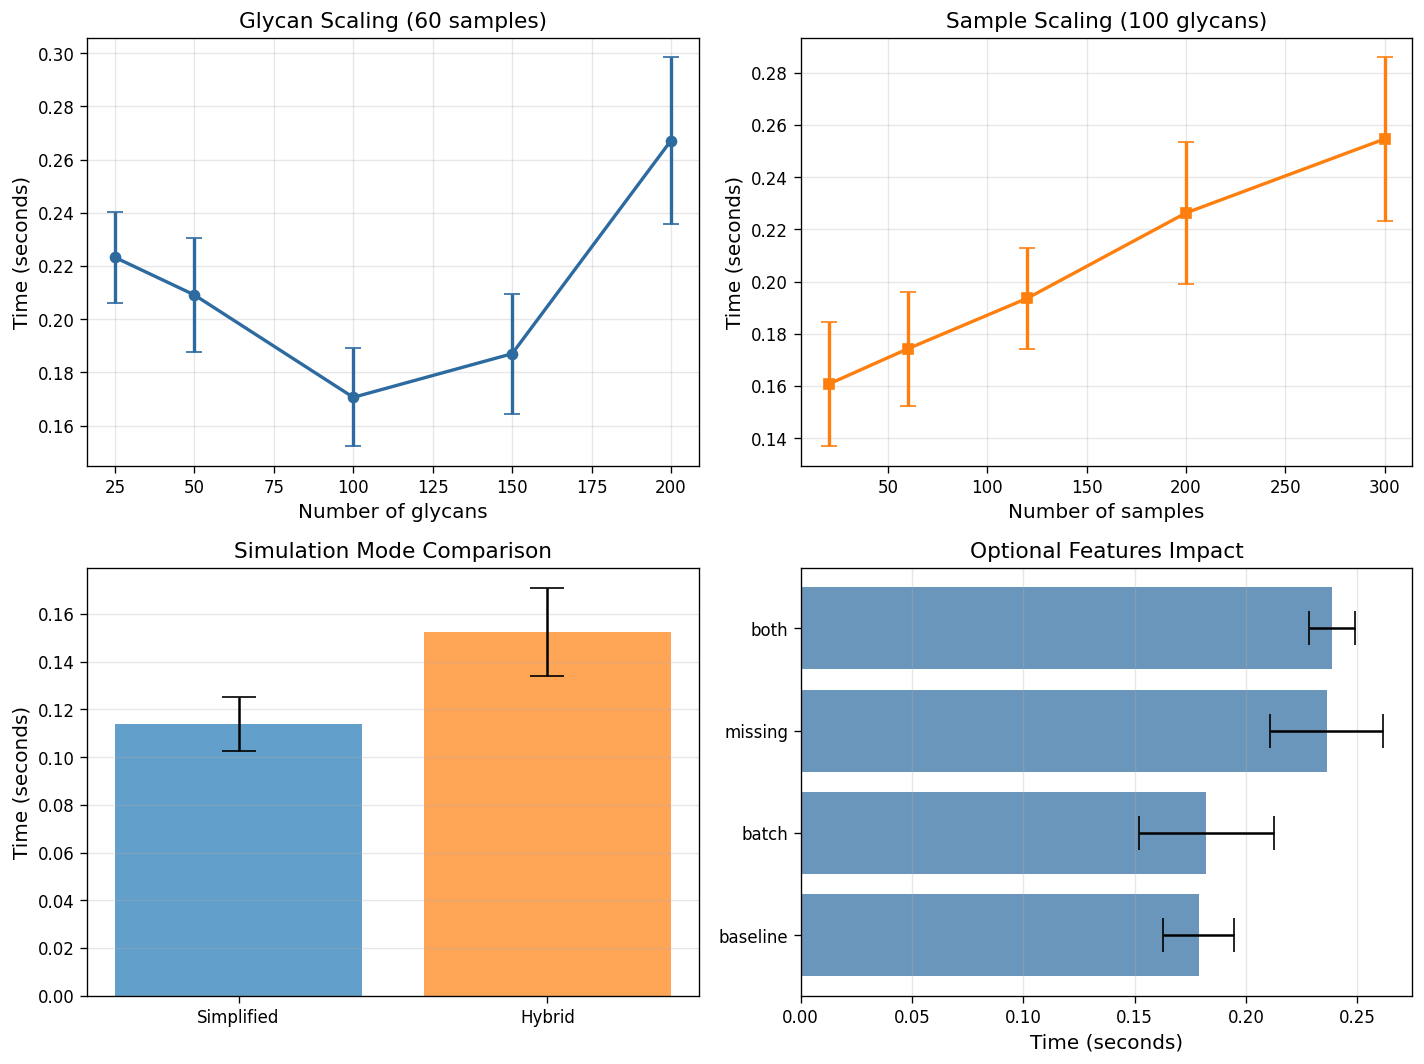


Benchmark complete. Plot saved to glycoforge_benchmark.png


In [6]:
def benchmark_config(config, n_seeds=20):
  """Time a single configuration across multiple seeds"""
  times = []
  for seed in range(42, 42 + n_seeds):
    config['random_seeds'] = [seed]
    config['verbose'] = False
    config['save_csv'] = False
    start = time.time()
    simulate(**config)
    times.append(time.time() - start)
  return np.median(times), np.percentile(times, 75) - np.percentile(times, 25)

# Warmup (populates glycowork caches, JIT, etc.)
_ = simulate(data_source='simulated', n_glycans=50, n_H=15, n_U=15, glycan_class=None, output_dir='benchmark_tmp', verbose=False, save_csv=False)

# 1. Dataset size scaling (simplified mode)
glycan_configs = []
glycan_sizes = [25, 50, 100, 150, 200]
for n_glycans in glycan_sizes:
  config = {'data_source': 'simulated', 'n_glycans': n_glycans, 'n_H': 30, 'n_U': 30, 'glycan_class': None, 'output_dir': 'benchmark_tmp'}
  mean_t, std_t = benchmark_config(config)
  glycan_configs.append({'n_glycans': n_glycans, 'mean': mean_t, 'std': std_t})
  print(f"Glycans={n_glycans}, samples=60: {mean_t:.2f}s ± {std_t:.2f}s")
sample_configs = []
sample_sizes = [10, 30, 60, 100, 150]
for n_samples in sample_sizes:
  config = {'data_source': 'simulated', 'n_glycans': 100, 'n_H': n_samples, 'n_U': n_samples, 'glycan_class': None, 'output_dir': 'benchmark_tmp'}
  mean_t, std_t = benchmark_config(config)
  sample_configs.append({'n_samples': n_samples * 2, 'mean': mean_t, 'std': std_t})
  print(f"Glycans=100, samples={n_samples*2}: {mean_t:.2f}s ± {std_t:.2f}s")

# 2. Simplified vs Hybrid mode
base_config = {'n_glycans': 98, 'n_H': 30, 'n_U': 30, 'output_dir': 'benchmark_tmp'}
simplified_mean, simplified_std = benchmark_config({**base_config, 'data_source': 'simulated'})
hybrid_mean, hybrid_std = benchmark_config({**base_config, 'data_source': 'real', 'data_file': 'glycomics_human_leukemia_O_PMID34646384.csv', 'use_real_effect_sizes': True, 'column_prefix': {'healthy': 'R7', 'unhealthy': 'BM'}})
print(f"Synthetic: {simplified_mean:.2f}s ± {simplified_std:.2f}s")
print(f"Templated: {hybrid_mean:.2f}s ± {hybrid_std:.2f}s")

# 3. Feature impact
feature_configs = []
features = [('baseline', {}), ('batch', {'kappa_mu': 1.5, 'var_b': 0.5}), ('missing', {'missing_fraction': 0.15}), ('both', {'kappa_mu': 1.5, 'var_b': 0.5, 'missing_fraction': 0.15})]
for name, params in features:
  config = {**base_config, 'data_source': 'simulated', 'glycan_class': None, **params}
  mean_t, std_t = benchmark_config(config)
  feature_configs.append({'name': name, 'mean': mean_t, 'std': std_t})
  print(f"Feature {name}: {mean_t:.2f}s ± {std_t:.2f}s")

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
# Plot 1: Glycan scaling
df_glyc = pd.DataFrame(glycan_configs)
axes[0, 0].errorbar(df_glyc['n_glycans'], df_glyc['mean'], yerr=df_glyc['std'], marker='o', capsize=5, linewidth=2)
axes[0, 0].set_xlabel('Number of glycans')
axes[0, 0].set_ylabel('Time (seconds)')
axes[0, 0].set_title('Glycan Scaling (60 samples)')
axes[0, 0].grid(alpha=0.3)
# Plot 2: Sample scaling
df_samp = pd.DataFrame(sample_configs)
axes[0, 1].errorbar(df_samp['n_samples'], df_samp['mean'], yerr=df_samp['std'], marker='s', capsize=5, linewidth=2, color='#ff7f0e')
axes[0, 1].set_xlabel('Number of samples')
axes[0, 1].set_ylabel('Time (seconds)')
axes[0, 1].set_title('Sample Scaling (100 glycans)')
axes[0, 1].grid(alpha=0.3)
# Plot 3: Mode comparison
modes = ['Simplified', 'Hybrid']
means = [simplified_mean, hybrid_mean]
stds = [simplified_std, hybrid_std]
axes[1, 0].bar(modes, means, yerr=stds, capsize=10, alpha=0.7, color=['#1f77b4', '#ff7f0e'])
axes[1, 0].set_ylabel('Time (seconds)')
axes[1, 0].set_title('Simulation Mode Comparison')
axes[1, 0].grid(alpha=0.3, axis='y')
# Plot 4: Feature impact
df_feat = pd.DataFrame(feature_configs)
axes[1, 1].barh(df_feat['name'], df_feat['mean'], xerr=df_feat['std'], capsize=10, alpha=0.7)
axes[1, 1].set_xlabel('Time (seconds)')
axes[1, 1].set_title('Optional Features Impact')
axes[1, 1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{fp}/results/figures/timing_benchmark.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nBenchmark complete. Plot saved to timing_benchmark.png")

# Figure S11

You're working with an alpha of 0.054572814701647765 that has been adjusted for your sample size of 20.
Significance inflation detected. The CLR/ALR transformation possibly cannot handle this dataset. Consider running again with a higher gamma value.             Proceed with caution; for now switching to Bonferroni correction to be conservative about this.
You're working with an alpha of 0.054572814701647765 that has been adjusted for your sample size of 20.


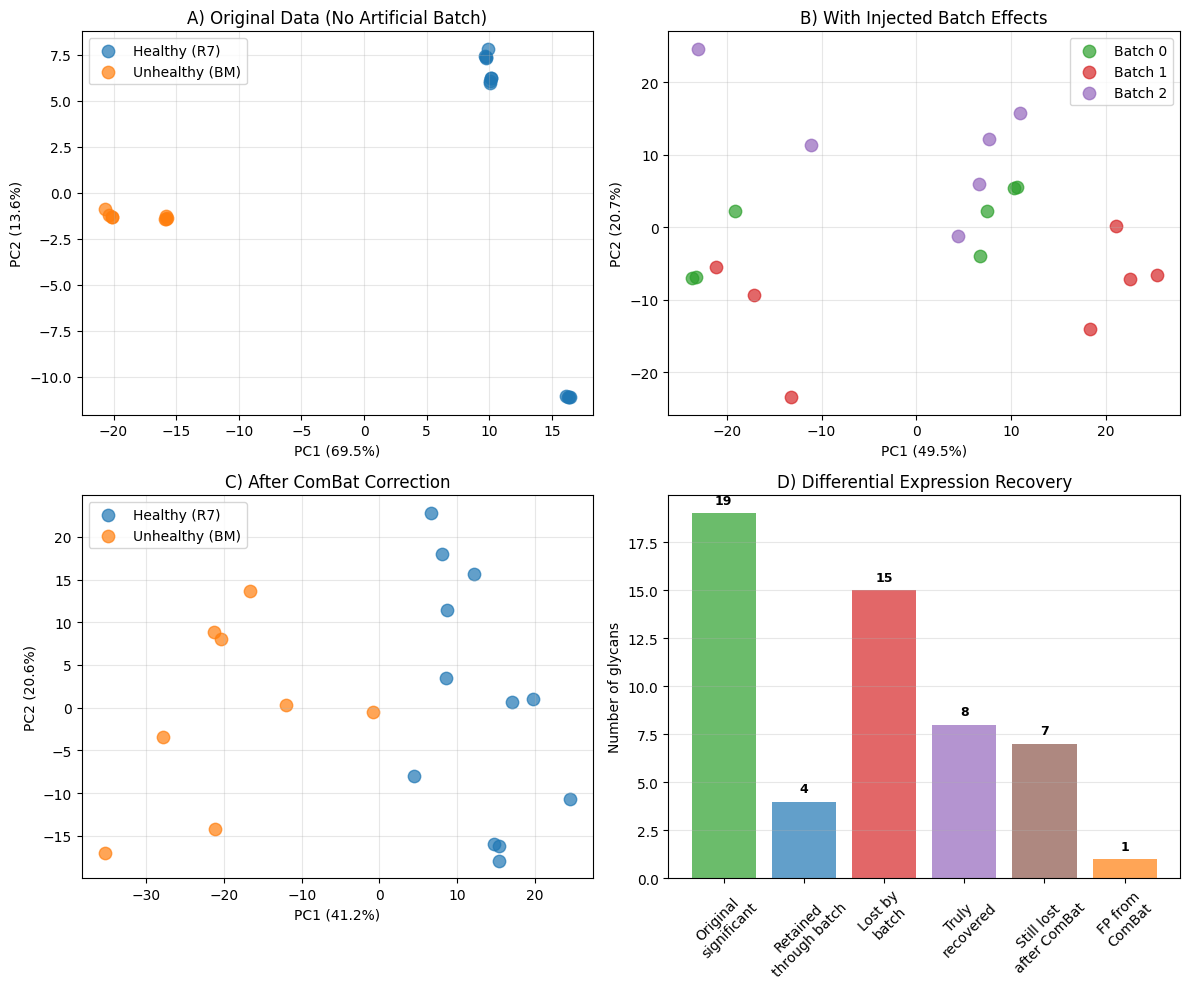

Original significant: 19
Retained through batch: 4 (21.1%)
Lost by batch: 15 (78.9%)
Truly recovered: 8 (53.3% of lost)
Still lost: 7
False positives: 1


In [54]:
control = "R"
condition = "BM"

# Load real glycomics data
df_original = load_data_from_glycowork('glycomics_human_leukemia_O_PMID34646384')
r7_cols = [c for c in df_original.columns if c.startswith(control)]
bm_cols = [c for c in df_original.columns if c.startswith(condition)]
all_cols = r7_cols + bm_cols
data = df_original[all_cols].values.T
n_samples = len(all_cols)
n_glycans = data.shape[1]

# Convert to CLR
data_clr = clr(data).T
data_clr_df = pd.DataFrame(data_clr, columns=all_cols)

# Create artificial batch labels
n_batches = 3
batch_groups, batch_labels = stratified_batches_from_columns(all_cols, n_batches=n_batches, seed=42, verbose=False,
                                                            control_prefix = control)

# Use auto mode - random batch effects on random glycans
u_dict, _ = define_batch_direction(
  batch_effect_direction=None,
  n_glycans=n_glycans,
  n_batches=n_batches,
  affected_fraction=(0.3, 0.6),
  positive_prob=0.5,
  overlap_prob=0.3,
  u_dict_seed=42,
  verbose=False
)

# Inject batch effects
sigma = estimate_sigma(data_clr_df)
data_with_batch_clr, data_with_batch = apply_batch_effect(data_clr.T, batch_labels, u_dict, sigma, kappa_mu=0.6, var_b=0.2, seed=42)
data_with_batch_clr = data_with_batch_clr.T
data_with_batch = data_with_batch.T

# ComBat correction
bio_labels = np.array([0]*len(r7_cols) + [1]*len(bm_cols))
data_with_batch_clr_fixed = add_noise_to_zero_variance_features(pd.DataFrame(data_with_batch_clr, columns=all_cols), noise_level=1e-10, random_seed=42)
data_corrected_clr = combat(data_with_batch_clr_fixed.values, batch_labels, mod=bio_labels)

# Differential expression analysis
df_original = pd.DataFrame({'glycan': df_original['glycan'].values, **{col: data[i, :] for i, col in enumerate(all_cols)}})
df_with_batch = pd.DataFrame({'glycan': df_original['glycan'].values, **{col: data_with_batch[:, i] for i, col in enumerate(all_cols)}})
data_corrected_comp = np.array([invclr(data_corrected_clr[:, i]) for i in range(data_corrected_clr.shape[1])]).T
df_corrected = pd.DataFrame({'glycan': df_original['glycan'].values, **{col: data_corrected_comp[:, i] for i, col in enumerate(all_cols)}})

# Original and batch-affected: use glycowork normally
res_original = get_differential_expression(df_original, group1=bm_cols, group2=r7_cols, transform='CLR', motifs=False)
res_batch = get_differential_expression(df_with_batch, group1=bm_cols, group2=r7_cols, transform='CLR', motifs=False)

def differential_expression_from_clr(clr_data, group1_indices, group2_indices, alpha=0.05):
  """Perform differential expression directly on CLR-transformed data"""
  n_features = clr_data.shape[0]
  pvals, effect_sizes = [], []
  for i in range(n_features):
    g1_vals = clr_data[i, group1_indices]
    g2_vals = clr_data[i, group2_indices]
    _, p = ttest_ind(g2_vals, g1_vals, equal_var=False)
    mean_diff = g2_vals.mean() - g1_vals.mean()
    pooled_std = np.sqrt((g1_vals.var() + g2_vals.var()) / 2)
    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
    pvals.append(p)
    effect_sizes.append(cohens_d)
  _, corrected_pvals, _, _ = multipletests(pvals, method='fdr_bh')
  significant = corrected_pvals < alpha
  return set(np.where(significant)[0])

# Get indices
group1_indices = [df_original.columns.tolist().index(c)-1 for c in r7_cols]
group2_indices = [df_original.columns.tolist().index(c)-1 for c in bm_cols]

# Analyze corrected data
sig_original = set(np.where(res_original.significant == True)[0])
sig_batch = set(np.where(res_batch.significant == True)[0])
sig_corrected = differential_expression_from_clr(data_corrected_clr, group1_indices, group2_indices)

# PCA for visualization
pca = PCA(n_components=2)
colors_bio = ['#1f77b4' if i < len(r7_cols) else '#ff7f0e' for i in range(n_samples)]
colors_batch = ['#2ca02c', '#d62728', '#9467bd'][:n_batches]
colors_batch_labels = [colors_batch[b] for b in batch_labels]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Panel A: Original data
pc_orig = pca.fit_transform(data_clr.T)
axes[0,0].scatter(pc_orig[:len(r7_cols), 0], pc_orig[:len(r7_cols), 1], c='#1f77b4', label='Healthy (R7)', alpha=0.7, s=80)
axes[0,0].scatter(pc_orig[len(r7_cols):, 0], pc_orig[len(r7_cols):, 1], c='#ff7f0e', label='Unhealthy (BM)', alpha=0.7, s=80)
axes[0,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0,0].set_title('A) Original Data (No Artificial Batch)')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# Panel B: With injected batch
pc_batch = pca.fit_transform(data_with_batch_clr.T)
for b in range(n_batches):
  mask = batch_labels == b
  axes[0,1].scatter(pc_batch[mask, 0], pc_batch[mask, 1], c=colors_batch[b], label=f'Batch {b}', alpha=0.7, s=80)
axes[0,1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0,1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0,1].set_title('B) With Injected Batch Effects')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# Panel C: After ComBat
pc_corrected = pca.fit_transform(data_corrected_clr.T)
axes[1,0].scatter(pc_corrected[:len(r7_cols), 0], pc_corrected[:len(r7_cols), 1], c='#1f77b4', label='Healthy (R7)', alpha=0.7, s=80)
axes[1,0].scatter(pc_corrected[len(r7_cols):, 0], pc_corrected[len(r7_cols):, 1], c='#ff7f0e', label='Unhealthy (BM)', alpha=0.7, s=80)
axes[1,0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1,0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1,0].set_title('C) After ComBat Correction')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# Panel D: DE recovery
retained_through_batch = sig_original & sig_batch  # Never lost
lost_by_batch = sig_original - sig_batch  # Lost by batch injection
truly_recovered = lost_by_batch & sig_corrected  # Lost by batch, found again by ComBat
still_lost = lost_by_batch - sig_corrected  # Lost by batch, not recovered
false_pos_combat = sig_corrected - sig_original  # New false positives from ComBat

metrics = {
  'Original\nsignificant': len(sig_original),
  'Retained\nthrough batch': len(retained_through_batch),
  'Lost by\nbatch': len(lost_by_batch),
  'Truly\nrecovered': len(truly_recovered),
  'Still lost\nafter ComBat': len(still_lost),
  'FP from\nComBat': len(false_pos_combat)
}

colors_bars = ['#2ca02c', '#1f77b4', '#d62728', '#9467bd', '#8c564b', '#ff7f0e']
axes[1,1].bar(metrics.keys(), metrics.values(), color=colors_bars, alpha=0.7)
axes[1,1].set_ylabel('Number of glycans')
axes[1,1].set_title('D) Differential Expression Recovery')
axes[1,1].grid(alpha=0.3, axis='y')
axes[1,1].tick_params(axis='x', rotation=45)
for i, (k, v) in enumerate(metrics.items()):
  axes[1,1].text(i, v + 0.5, str(v), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{fp}/results/figures/batch_injection_experiment.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"Original significant: {len(sig_original)}")
print(f"Retained through batch: {len(retained_through_batch)} ({len(retained_through_batch)/len(sig_original)*100:.1f}%)")
print(f"Lost by batch: {len(lost_by_batch)} ({len(lost_by_batch)/len(sig_original)*100:.1f}%)")
print(f"Truly recovered: {len(truly_recovered)} ({len(truly_recovered)/len(lost_by_batch)*100:.1f}% of lost)")
print(f"Still lost: {len(still_lost)}")
print(f"False positives: {len(false_pos_combat)}")

# Real-world glycomics datasets

In [10]:
datasets = [{"df": glycomics_data_loader.HIV_gagtransfection_N_PMID35112714, "name": "HIV_gagtransfection_N_PMID35112714",
            "healthy_prefix": "mocktransfected", "unhealthy_prefix": "gagtransfected"},
 {"df": glycomics_data_loader.HIV_gagtransfection_O_PMID35112714, "name": "HIV_gagtransfection_O_PMID35112714",
 "healthy_prefix": "mocktransfected", "unhealthy_prefix": "gagtransfected"},
 {"df": glycomics_data_loader.cell_lines_gRNA_GPST000463, "name": "cell_lines_gRNA_GPST000463",
 "healthy_prefix": "HEK293", "unhealthy_prefix": "K562"},
 {"df": glycomics_data_loader.human_brain_GSL_PMID38343116, "name": "human_brain_GSL_PMID38343116",
 "healthy_prefix": "GSL_Control", "unhealthy_prefix": "GSL_SSSMuG"},
 {"df": glycomics_data_loader.human_brain_GSL_PMID40207879, "name": "human_brain_GSL_PMID40207879",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.human_brain_N_PMID38343116, "name": "human_brain_N_PMID38343116",
 "healthy_prefix": "NG_Control", "unhealthy_prefix": "NG_SSSMuG"},
 {"df": glycomics_data_loader.human_brain_O_PMID38343116, "name": "human_brain_O_PMID38343116",
 "healthy_prefix": "OG_Control", "unhealthy_prefix": "OG_SSSMuG"},
 {"df": glycomics_data_loader.human_colorectal_N_PMID26085185, "name": "human_colorectal_N_PMID26085185",
 "healthy_prefix": "Avg_RA_N", "unhealthy_prefix": "Avg_RA_T"},
 {"df": glycomics_data_loader.human_colorectal_N_PMID39947398, "name": "human_colorectal_N_PMID39947398",
 "healthy_prefix": "healthy", "unhealthy_prefix": "stage"},
 {"df": glycomics_data_loader.human_colorectal_O_PMC9254241, "name": "human_colorectal_O_PMC9254241",
 "healthy_prefix": "C", "unhealthy_prefix": "T"},
 {"df": glycomics_data_loader.human_colorectal_O_PMID19152289, "name": "human_colorectal_O_PMID19152289",
 "healthy_prefix": "C", "unhealthy_prefix": "T"},
 {"df": glycomics_data_loader.human_gastric_O_PMC4816881, "name": "human_gastric_O_PMC4816881",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.human_gastric_O_PMC5762837, "name": "human_gastric_O_PMC5762837",
 "healthy_prefix": "healthy", "unhealthy_prefix": "cancer"},
 {"df": glycomics_data_loader.human_gastric_O_PMC7226152, "name": "human_gastric_O_PMC7226152",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.human_gastric_O_PMID28461410, "name": "human_gastric_O_PMID28461410",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.human_leukemia_GSL_PMID36788594, "name": "human_leukemia_GSL_PMID36788594",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.human_leukemia_N_PMID34646384, "name": "human_leukemia_N_PMID34646384",
 "healthy_prefix": "R7", "unhealthy_prefix": "BM"},
 {"df": glycomics_data_loader.human_leukemia_N_PMID36788594, "name": "human_leukemia_N_PMID36788594",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.human_leukemia_O_PMID34646384, "name": "human_leukemia_O_PMID34646384",
 "healthy_prefix": "R7", "unhealthy_prefix": "BM"},
 {"df": glycomics_data_loader.human_leukemia_O_PMID36788594, "name": "human_leukemia_O_PMID36788594",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.human_liver_O_PMC5383776, "name": "human_liver_O_PMC5383776",
 "healthy_prefix": "control", "unhealthy_prefix": "tumor"},
 {"df": glycomics_data_loader.human_liver_O_PMC9254241, "name": "human_liver_O_PMC9254241",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.human_macrophages_N_2024_11_28_625934, "name": "human_macrophages_N_2024_11_28_625934",
 "healthy_prefix": "Anti", "unhealthy_prefix": "Pro"},
 {"df": glycomics_data_loader.human_macrophages_O_2024_11_28_625934, "name": "human_macrophages_O_2024_11_28_625934",
 "healthy_prefix": "Anti", "unhealthy_prefix": "Pro"},
 {"df": glycomics_data_loader.human_neutrophils_N_PMID37639587, "name": "human_neutrophils_N_PMID37639587",
 "healthy_prefix": "Az", "unhealthy_prefix": "Sp"},
 {"df": glycomics_data_loader.human_ovarian_O_PMC4468167, "name": "human_ovarian_O_PMC4468167",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.human_pbmc_cancer_N_PMID39947398, "name": "human_pbmc_cancer_N_PMID39947398",
 "healthy_prefix": "healthy", "unhealthy_prefix": "stage"},
 {"df": glycomics_data_loader.human_platelets_N_PMID36952551, "name": "human_platelets_N_PMID36952551",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.human_platelets_O_PMID36952551, "name": "human_platelets_O_PMID36952551",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.human_prostate_N_PMC8010466, "name": "human_prostate_N_PMC8010466",
 "healthy_prefix": "control", "unhealthy_prefix": "stage"},
 {"df": glycomics_data_loader.human_prostate_O_PMC8010466, "name": "human_prostate_O_PMC8010466",
 "healthy_prefix": "control", "unhealthy_prefix": "stage"},
 {"df": glycomics_data_loader.human_retina_GSL_PMC5173345, "name": "human_retina_GSL_PMC5173345",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.human_serum_N_PMID39877544, "name": "human_serum_N_PMID39877544",
 "healthy_prefix": "viral", "unhealthy_prefix": "bacterial"},
 {"df": glycomics_data_loader.human_serum_bacteremia_N_PMID33535571, "name": "human_serum_bacteremia_N_PMID33535571",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.human_skin_O_PMC5871710, "name": "human_skin_O_PMC5871710",
 "healthy_prefix": "control", "unhealthy_prefix": "tumor"},
 {"df": glycomics_data_loader.human_skin_O_PMC5871710_BCC, "name": "human_skin_O_PMC5871710_BCC",
 "healthy_prefix": "control", "unhealthy_prefix": "tumor"},
 {"df": glycomics_data_loader.human_skin_O_PMC5871710_SCC, "name": "human_skin_O_PMC5871710_SCC",
 "healthy_prefix": "control", "unhealthy_prefix": "tumor"},
 {"df": glycomics_data_loader.macaque_brain_N_GPST000309, "name": "macaque_brain_N_GPST000309",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.mouse_brain_GSL_PMID39375371, "name": "mouse_brain_GSL_PMID39375371",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.mouse_gastric_O_PMID40667878, "name": "mouse_gastric_O_PMID40667878",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.mouse_taysachs_N_PMID41460292, "name": "mouse_taysachs_N_PMID41460292",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.mouse_taysachs_O_PMID41460292, "name": "mouse_taysachs_O_PMID41460292",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.time_series_HMO_PMID22649065, "name": "time_series_HMO_PMID22649065",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.time_series_N_PMID32149347, "name": "time_series_N_PMID32149347",
 "healthy_prefix": "", "unhealthy_prefix": ""},
 {"df": glycomics_data_loader.time_series_O_PMID32149347, "name": "time_series_O_PMID32149347",
 "healthy_prefix": "", "unhealthy_prefix": ""}]

# Figure S7

[HIV_gagtransfection_N_PMID35112714]  power α=1.0 MSE=0.00578  logistic MSE=0.00009  fitted b=1.01
[cell_lines_gRNA_GPST000463]  power α=1.0 MSE=0.17402  logistic MSE=0.03418  fitted b=-0.04
[human_brain_GSL_PMID38343116]  power α=1.0 MSE=0.02491  logistic MSE=0.02459  fitted b=0.67
[human_brain_GSL_PMID40207879]  power α=1.0 MSE=0.02502  logistic MSE=0.00854  fitted b=0.57
[human_brain_N_PMID38343116]  power α=1.0 MSE=0.00320  logistic MSE=0.00119  fitted b=1.00
[human_brain_O_PMID38343116]  power α=1.0 MSE=0.16210  logistic MSE=0.05634  fitted b=-0.25
[human_colorectal_N_PMID26085185]  power α=1.0 MSE=0.01041  logistic MSE=0.00522  fitted b=1.19
[human_colorectal_O_PMC9254241]  power α=1.0 MSE=0.11966  logistic MSE=0.00199  fitted b=1.06
[human_colorectal_O_PMID19152289]  power α=1.0 MSE=0.00211  logistic MSE=0.00208  fitted b=0.89
[human_gastric_O_PMC4816881]  power α=1.0 MSE=0.03868  logistic MSE=0.03794  fitted b=1.01
[human_gastric_O_PMC5762837]  power α=3.0 MSE=0.01713  logistic

C:\Users\Daniel\AppData\Local\Temp\ipykernel_32064\642828094.py:305: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


[human_prostate_N_PMC8010466]  power α=1.0 MSE=0.00006  logistic MSE=0.00000  fitted b=-0.37
[human_retina_GSL_PMC5173345]  power α=1.0 MSE=0.15204  logistic MSE=0.01461  fitted b=-7.64
[human_serum_bacteremia_N_PMID33535571]  power α=1.0 MSE=0.00000  logistic MSE=0.00000  fitted b=0.23
[macaque_brain_N_GPST000309]  power α=1.0 MSE=0.00252  logistic MSE=0.00339  fitted b=1.26
[mouse_brain_GSL_PMID39375371]  power α=1.0 MSE=0.01410  logistic MSE=0.00276  fitted b=1.06
[mouse_gastric_O_GPST000464]  power α=1.0 MSE=0.00460  logistic MSE=0.00065  fitted b=0.53
[mouse_taysachs_N_PMID41460292]  power α=1.0 MSE=0.07446  logistic MSE=0.00720  fitted b=0.58
[mouse_taysachs_O_PMID41460292]  power α=3.0 MSE=0.00011  logistic MSE=0.00004  fitted b=2.74
[time_series_HMO_PMID22649065]  power α=1.0 MSE=0.00008  logistic MSE=0.00001  fitted b=-12.17

Fitted logistic b across 24 valid datasets:
  Median = 0.92
  Mean   = 1.05
  IQR    = 0.65 – 1.07


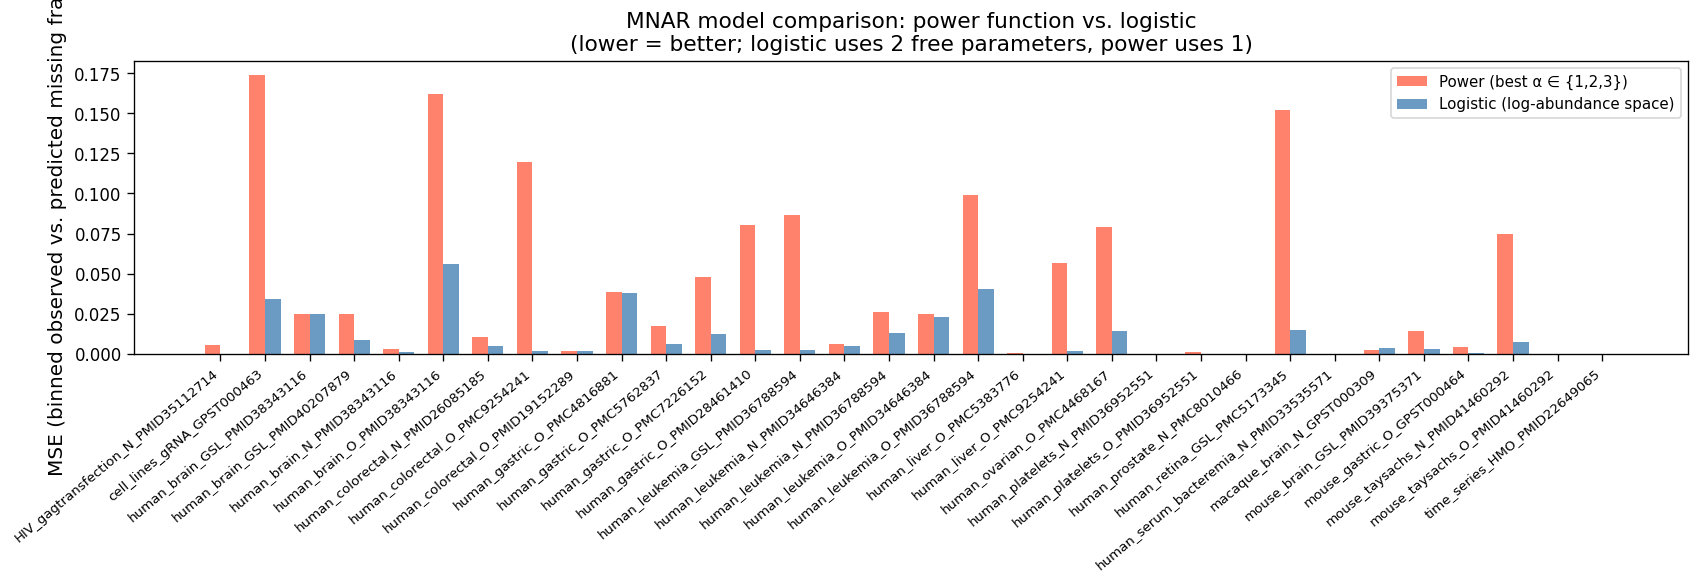

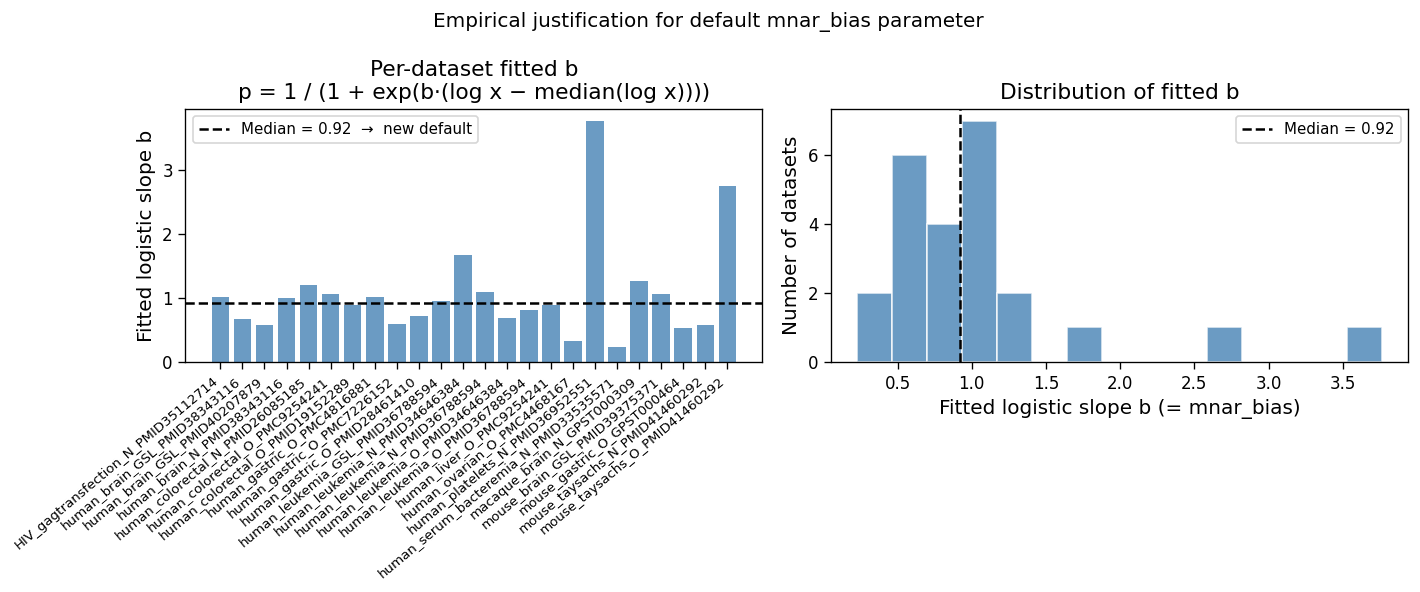

In [18]:
def validate_mnar_model(datasets, n_bins=10, missing_as_zero=True, filepath=''):
  """Validate GlycoForge's MNAR model against real glycomics datasets.
  Fits both a power function (best α from {1,2,3}) and a logistic in
  log-abundance space to each dataset's observed intensity-missingness
  relationship, then extracts the fitted logistic slope b to empirically
  justify the default mnar_bias parameter.

  Parameters
  ----------
  datasets : list of dict, each with 'df' (rows=glycans, cols=samples)
    and 'name'. Per-dataset 'missing_as_zero' overrides the global default.
  n_bins : int  Number of quantile bins for computing observed miss fractions.
  missing_as_zero : bool  Treat 0 as missing globally (default True).

  Returns
  -------
  list of dict, one per dataset with keys: name, overall_frac, power_mse,
    logistic_mse, fitted_b. Produces Figure 1 (MSE comparison) and
    Figure 2 (fitted b distribution).
  """
  results = []
  for ds in datasets:
    df = ds['df'].copy()
    if df.columns.tolist()[0] == "ID":
      df = df.T
      df.columns = df.iloc[0]
      df = df.drop(df.index[0])
    else:
      df = df.set_index(df.columns[0])
    df = df.apply(pd.to_numeric, errors='coerce')
    name = ds.get('name', 'Dataset')
    if ds.get('missing_as_zero', missing_as_zero):
      df = df.replace(0.0, np.nan)
    overall_frac = float(df.isna().values.mean())
    if overall_frac == 0.0:
      continue
    # Per-glycan mean over observed values as intensity proxy
    glycan_means = df.mean(axis=1).values
    pair_means = np.repeat(glycan_means, df.shape[1])
    pair_miss = df.isna().values.flatten().astype(float)
    keep = ~np.isnan(pair_means)
    pm, pf = pair_means[keep], pair_miss[keep]
    pm_safe = np.clip(pm, 1e-10, None)
    # Binned observed fractions
    bin_edges = np.quantile(pm, np.linspace(0, 1, n_bins + 1))
    bin_edges[-1] *= 1.001
    def binned(pred):
      return np.array([
        pred[(pm >= bin_edges[b]) & (pm < bin_edges[b+1])].mean()
        if ((pm >= bin_edges[b]) & (pm < bin_edges[b+1])).any() else np.nan
        for b in range(n_bins)
      ])
    obs = binned(pf)
    # Power function: best of α ∈ {1, 2, 3}, C calibrated to overall_frac
    best_power_mse, best_alpha = np.inf, None
    for alpha in [1.0, 2.0, 3.0]:
      raw = pm_safe ** (-alpha)
      C = overall_frac / (raw.mean() + 1e-30)
      pred = binned(np.clip(C * raw, 0, 1))
      valid = ~np.isnan(obs) & ~np.isnan(pred)
      mse = float(np.mean((pred[valid] - obs[valid]) ** 2))
      if mse < best_power_mse:
        best_power_mse, best_alpha = mse, alpha
    # Logistic in log-abundance space: p = 1 / (1 + exp(a + b*log(x)))
    fitted_b, logistic_mse = None, None
    log_pm = np.log(pm_safe)
    try:
      popt, _ = curve_fit(
        lambda x, a, b: 1.0 / (1.0 + np.exp(np.clip(a + b * x, -500, 500))),
        log_pm, pf, p0=[0.0, 0.5], maxfev=4000
      )
      pred_log = binned(1.0 / (1.0 + np.exp(np.clip(popt[0] + popt[1] * log_pm, -500, 500))))
      valid = ~np.isnan(obs) & ~np.isnan(pred_log)
      logistic_mse = float(np.mean((pred_log[valid] - obs[valid]) ** 2))
      fitted_b = float(popt[1])
    except Exception:
      pass
    results.append(dict(name=name, overall_frac=overall_frac,
                        power_mse=best_power_mse, best_alpha=best_alpha,
                        logistic_mse=logistic_mse, fitted_b=fitted_b))
    print(f'[{name}]  power α={best_alpha} MSE={best_power_mse:.5f}  '
          f'logistic MSE={logistic_mse:.5f}  fitted b={fitted_b:.2f}' if fitted_b else
          f'[{name}]  power α={best_alpha} MSE={best_power_mse:.5f}  logistic fit failed')
  # ── Figure 1: Power vs Logistic MSE per dataset ──────────────────────────
  valid_r = [r for r in results if r['logistic_mse'] is not None]
  names = [r['name'] for r in valid_r]
  x = np.arange(len(names))
  w = 0.35
  fig1, ax = plt.subplots(figsize=(max(10, len(names) * 0.45), 5))
  ax.bar(x - w/2, [r['power_mse'] for r in valid_r], width=w,
         color='tomato', alpha=0.8, label='Power (best α ∈ {1,2,3})')
  ax.bar(x + w/2, [r['logistic_mse'] for r in valid_r], width=w,
         color='steelblue', alpha=0.8, label='Logistic (log-abundance space)')
  ax.set_xticks(x)
  ax.set_xticklabels(names, rotation=40, ha='right', fontsize=8)
  ax.set_ylabel('MSE (binned observed vs. predicted missing fraction)')
  ax.set_title('MNAR model comparison: power function vs. logistic\n'
               '(lower = better; logistic uses 2 free parameters, power uses 1)')
  ax.legend(fontsize=9)
  plt.tight_layout()
  if filepath:
    plt.savefig(filepath, format = Path(filepath).suffix[1:], dpi = 300, bbox_inches = 'tight')
  # ── Figure 2: Distribution of fitted b → default mnar_bias ───────────────
  # Exclude degenerate fits: b <= 0 (wrong direction) or b > 15
  b_valid = [(r['name'], r['fitted_b']) for r in results
             if r['fitted_b'] is not None and 0 < r['fitted_b'] <= 15]
  b_names = [n for n, b in b_valid]
  b_vals = np.array([b for n, b in b_valid])
  b_median = float(np.median(b_vals))
  print(f'\nFitted logistic b across {len(b_vals)} valid datasets:')
  print(f'  Median = {b_median:.2f}')
  print(f'  Mean   = {np.mean(b_vals):.2f}')
  print(f'  IQR    = {np.percentile(b_vals, 25):.2f} – {np.percentile(b_vals, 75):.2f}')
  fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
  fig2.suptitle('Empirical justification for default mnar_bias parameter', fontsize=12)
  axes2[0].bar(np.arange(len(b_names)), b_vals, color='steelblue', alpha=0.8)
  axes2[0].axhline(b_median, color='k', ls='--', lw=1.5,
                   label=f'Median = {b_median:.2f}  →  new default')
  axes2[0].set_xticks(np.arange(len(b_names)))
  axes2[0].set_xticklabels(b_names, rotation=40, ha='right', fontsize=8)
  axes2[0].set_ylabel('Fitted logistic slope b')
  axes2[0].set_title('Per-dataset fitted b\n'
                     'p = 1 / (1 + exp(b·(log x − median(log x))))')
  axes2[0].legend(fontsize=9)
  axes2[1].hist(b_vals, bins=15, color='steelblue', alpha=0.8, edgecolor='white')
  axes2[1].axvline(b_median, color='k', ls='--', lw=1.5,
                   label=f'Median = {b_median:.2f}')
  axes2[1].set_xlabel('Fitted logistic slope b (= mnar_bias)')
  axes2[1].set_ylabel('Number of datasets')
  axes2[1].set_title('Distribution of fitted b')
  axes2[1].legend(fontsize=9)
  plt.tight_layout()
  return results, b_median

results, recommended_default = validate_mnar_model(datasets, filepath=f"{fp}/glycoforge_missingness.pdf")

# Figure S1

  [HIV_gagtransfection_N_PMID35112714] Dirichlet (current)         KS=0.625  Mantel r=0.052  Frob=23.18
  [HIV_gagtransfection_N_PMID35112714] MVN Ledoit-Wolf             KS=0.500  Mantel r=0.668  Frob=17.84
  [HIV_gagtransfection_N_PMID35112714] Copula (LW + empirical)     KS=0.250  Mantel r=0.643  Frob=18.27
  [HIV_gagtransfection_O_PMID35112714] Dirichlet (current)         KS=0.500  Mantel r=0.166  Frob=4.80
  [HIV_gagtransfection_O_PMID35112714] MVN Ledoit-Wolf             KS=0.375  Mantel r=0.744  Frob=3.44
  [HIV_gagtransfection_O_PMID35112714] Copula (LW + empirical)     KS=0.375  Mantel r=0.764  Frob=3.47
  [cell_lines_gRNA_GPST000463] Dirichlet (current)         KS=0.500  Mantel r=0.505  Frob=6.02
  [cell_lines_gRNA_GPST000463] MVN Ledoit-Wolf             KS=0.583  Mantel r=0.991  Frob=1.31
  [cell_lines_gRNA_GPST000463] Copula (LW + empirical)     KS=0.333  Mantel r=0.992  Frob=1.65
  [human_brain_GSL_PMID38343116] Dirichlet (current)         KS=0.600  Mantel r=0.069  Frob=12

C:\Users\Daniel\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  [human_leukemia_N_PMID34646384] Copula (LW + empirical)     KS=0.286  Mantel r=0.478  Frob=49.41
[human_leukemia_N_PMID36788594] Skipping — no prefixes defined.
  [human_leukemia_O_PMID34646384] Dirichlet (current)         KS=0.600  Mantel r=0.203  Frob=15.86
  [human_leukemia_O_PMID34646384] MVN Ledoit-Wolf             KS=0.550  Mantel r=0.876  Frob=8.26
  [human_leukemia_O_PMID34646384] Copula (LW + empirical)     KS=0.250  Mantel r=0.803  Frob=9.96
[human_leukemia_O_PMID36788594] Skipping — no prefixes defined.
  [human_liver_O_PMC5383776] Dirichlet (current)         KS=0.500  Mantel r=0.262  Frob=5.67
  [human_liver_O_PMC5383776] MVN Ledoit-Wolf             KS=0.667  Mantel r=0.653  Frob=4.87
  [human_liver_O_PMC5383776] Copula (LW + empirical)     KS=0.333  Mantel r=0.636  Frob=4.95
[human_liver_O_PMC9254241] Skipping — no prefixes defined.
  [human_macrophages_N_2024_11_28_625934] Dirichlet (current)         KS=0.625  Mantel r=0.075  Frob=35.35
  [human_macrophages_N_2024_11_28

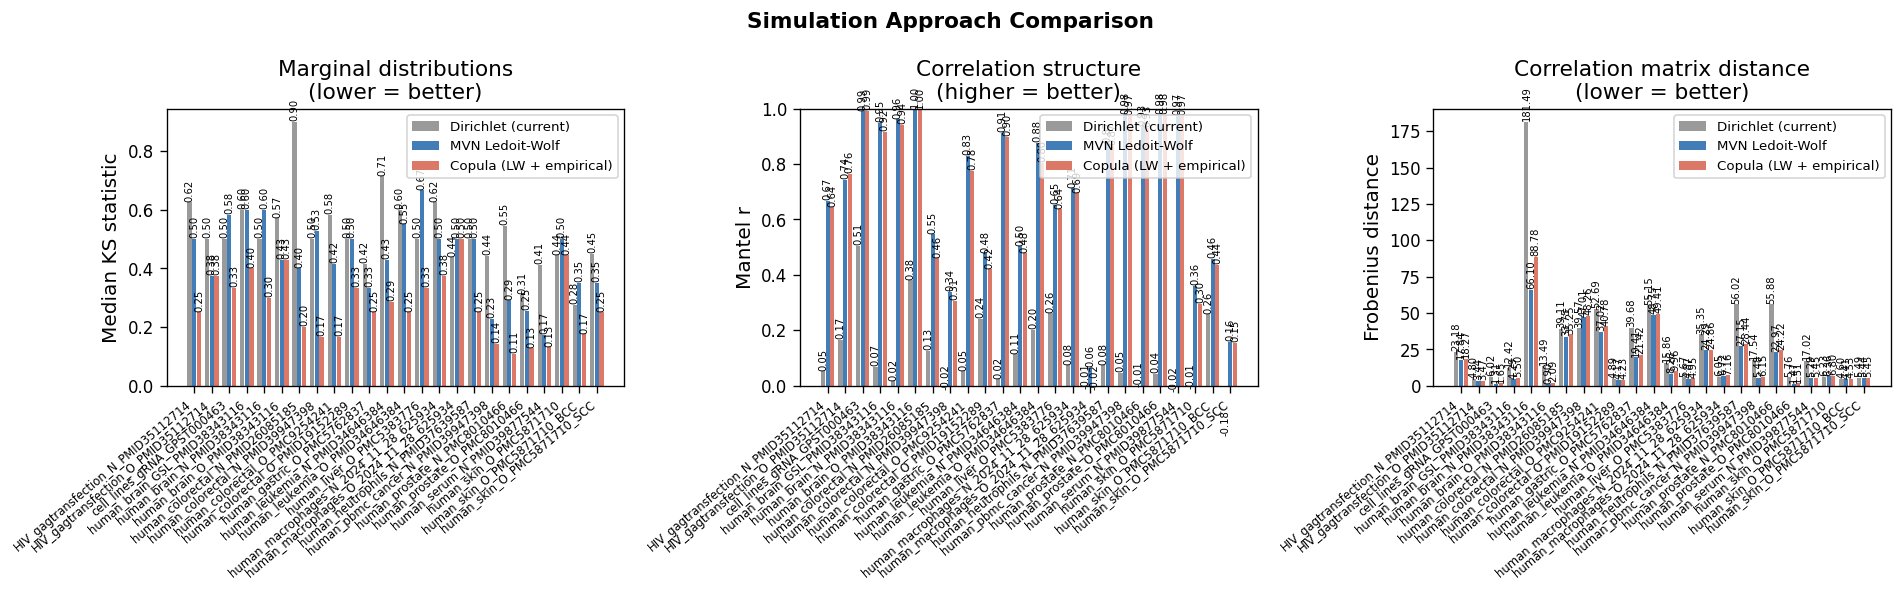

In [34]:
# ── simulation backends ────────────────────────────────────────────────────────
def _sim_dirichlet(alpha_H, alpha_U, mu_H, mu_U, Sigma, real_clr_ref, n_H, n_U, seed):
    rng = np.random.default_rng(seed)
    P_H = rng.dirichlet(alpha_H, size=n_H)
    P_U = rng.dirichlet(alpha_U, size=n_U)
    P = np.vstack([P_H, P_U])
    return clr(P)

def _sim_mvn_lw(alpha_H, alpha_U, mu_H, mu_U, Sigma, real_clr_ref, n_H, n_U, seed):
    rng = np.random.default_rng(seed)
    eps = max(1e-8, 1e-4 * np.trace(Sigma) / len(mu_H))
    S = Sigma + eps * np.eye(len(mu_H))
    clr_H = rng.multivariate_normal(mu_H, S, size=n_H)
    clr_U = rng.multivariate_normal(mu_U, S, size=n_U)
    return np.vstack([clr_H, clr_U])

def _sim_copula_lw(alpha_H, alpha_U, mu_H, mu_U, Sigma, real_clr_ref, n_H, n_U, seed):
    """Gaussian copula with LW correlation + empirical marginals from real CLR data.
    Sampling steps:
      1. Derive correlation matrix R from LW covariance (normalize by marginal stds).
      2. Draw Z ~ N(0, R), giving samples with the right correlation structure.
      3. Convert Z to uniform via Phi(Z) (copula transform)
      4. Map uniforms back to real CLR values via the empirical quantile function of
         each feature (restore the exact marginal distributions)
      5. Add the CLR-space injection only to the unhealthy rows, exactly as in MVN,
         so the biological ground truth is unchanged.
    The result has (a) the real inter-glycan correlation structure (from R),
    (b) the real per-feature marginal distributions (from empirical quantiles), and
    (c) a controlled mean shift between groups (from injection).
    """
    rng = np.random.default_rng(seed)
    n_features = Sigma.shape[0]
    std = np.sqrt(np.diag(Sigma))
    std = np.where(std < 1e-10, 1.0, std)
    R = Sigma / np.outer(std, std)
    np.fill_diagonal(R, 1.0)
    eps = max(1e-8, 1e-4 * n_features)
    R += eps * np.eye(n_features)
    Z = rng.multivariate_normal(np.zeros(n_features), R, size=n_H + n_U)
    U = sp_norm.cdf(Z)                                         # (n_samples, n_features)
    n_real = real_clr_ref.shape[0]
    sorted_real = np.sort(real_clr_ref, axis=0)               # (n_real, n_features)
    # Linear interpolation between empirical quantile steps for smoother output
    frac_idx = U * (n_real - 1)
    lo = np.floor(frac_idx).astype(int)
    hi = np.minimum(lo + 1, n_real - 1)
    t = frac_idx - lo
    X = sorted_real[lo, np.arange(n_features)] * (1 - t) + sorted_real[hi, np.arange(n_features)] * t
    injection = mu_U - mu_H
    X[n_H:] += injection
    return X

APPROACHES = {
    'Dirichlet\n(baseline)':  _sim_dirichlet,
    'MVN\nLedoit-Wolf':      _sim_mvn_lw,
    'Copula\n(LW + empirical)': _sim_copula_lw,
}

# ── comparison runner ──────────────────────────────────────────────────────────
def compare_simulation_approaches(
    datasets,
    bio_strength=1.5,
    k_dir=100,
    variance_ratio=1.5,
    n_sim_runs=10,
    differential_mask_mode='significant',
    winsorize_percentile=None,
    baseline_method='median',
    figsize=(16, 5),
    filepath='',
):
    results = {a: {} for a in APPROACHES}
    for ds in datasets:
        df = ds['df'].copy()
        if df.columns.tolist()[0] == 'ID':
            df = df.T; df.columns = df.iloc[0]; df = df.drop(df.index[0])
        else:
            df = df.set_index(df.columns[0])
        df = df.apply(pd.to_numeric, errors='coerce')
        name = ds.get('name', 'Dataset')
        h_pfx = ds.get('healthy_prefix', '')
        u_pfx = ds.get('unhealthy_prefix', '')
        if not h_pfx or not u_pfx:
            print(f'[{name}] Skipping — no prefixes defined.')
            continue
        r_cols = [c for c in df.columns if c.startswith(h_pfx)]
        u_cols = [c for c in df.columns if c.startswith(u_pfx)]
        if not r_cols or not u_cols:
            print(f'[{name}] No columns found — skipping.')
            continue
        n_H, n_U = len(r_cols), len(u_cols)
        n_glycans = df.shape[0]
        rng0 = np.random.default_rng(42)
        df_j = df.copy()
        for col in r_cols + u_cols:
            mask = (df_j[col] == 0) & df_j[col].notna()
            if mask.any():
                df_j.loc[mask, col] = rng0.uniform(1e-6, 1.1e-6, int(mask.sum()))
        df_filled = df_j[r_cols + u_cols].copy()
        df_filled = df_filled.apply(
            lambda col: col.fillna(max(col.dropna().min() * 0.5, 1e-8)
                                   if col.dropna().any() else 1e-8)
        )
        real_clr = clr(df_filled.values.T)                    # (n_samples, n_glycans)
        real_corr = np.corrcoef(real_clr.T)
        triu = np.triu_indices(n_glycans, k=1)
        df_gw = df_j[r_cols + u_cols].reset_index()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            with contextlib.redirect_stdout(io.StringIO()):
                de = get_differential_expression(df_gw, group1=u_cols, group2=r_cols,
                                                  transform='CLR', impute=True)
        if len(de) != n_glycans:
            effect_sizes = np.zeros(n_glycans); sig_arr = np.zeros(n_glycans)
            for i, (es, sig) in enumerate(zip(de['Effect size'],
                                               de.get('significant', [False]*len(de)))):
                orig_idx = de.index[i]
                if orig_idx < n_glycans:
                    effect_sizes[orig_idx] = float(es) if not pd.isna(es) else 0.0
                    sig_arr[orig_idx] = float(sig) if not pd.isna(sig) else 0.0
        else:
            effect_sizes = de['Effect size'].fillna(0.0).values
            sig_arr = (de['significant'].values.astype(float)
                       if 'significant' in de.columns else np.ones(n_glycans))
        diff_mask = sig_arr if differential_mask_mode == 'significant' else np.ones(n_glycans)
        p_h = df_j[r_cols].mean(axis=1).values
        p_h = np.clip(p_h, 1e-8, None); p_h /= p_h.sum()
        alpha_H, alpha_U, mvn_debug = define_bio_injection_from_real_data(
            p_h=p_h, effect_sizes=effect_sizes, differential_mask=diff_mask,
            bio_strength=bio_strength, k_dir=k_dir, variance_ratio=variance_ratio,
            winsorize_percentile=winsorize_percentile, baseline_method=baseline_method,
            verbose=False
        )
        mu_H_mvn = real_clr[:n_H].mean(0)
        injection = np.array(mvn_debug['injection'])
        mu_U_mvn = mu_H_mvn + injection
        Sigma_lw = LedoitWolf().fit(real_clr).covariance_
        for approach_name, sim_fn in APPROACHES.items():
            corr_accum = np.zeros((n_glycans, n_glycans))
            clr_run0 = None
            for run in range(n_sim_runs):
                sc = sim_fn(alpha_H, alpha_U, mu_H_mvn, mu_U_mvn,
                            Sigma_lw, real_clr, n_H, n_U, run)
                corr_accum += np.corrcoef(sc.T)
                if run == 0:
                    clr_run0 = sc
            sim_corr = corr_accum / n_sim_runs
            ks = float(np.median([
                stats.ks_2samp(real_clr[:, g], clr_run0[:, g])[0]
                for g in range(n_glycans)
            ]))
            mantel_r = float(stats.pearsonr(real_corr[triu], sim_corr[triu])[0])
            frob = float(np.linalg.norm(real_corr - sim_corr, 'fro'))
            results[approach_name][name] = dict(median_ks=ks, mantel_r=mantel_r, frobenius=frob)
            print(f'  [{name}] {approach_name.replace(chr(10)," "):26s}  '
                  f'KS={ks:.3f}  Mantel r={mantel_r:.3f}  Frob={frob:.2f}')
    # ── plot ──────────────────────────────────────────────────────────────────
    ds_names = [ds['name'] for ds in datasets
                if ds.get('healthy_prefix') and ds.get('unhealthy_prefix')]
    approach_names = list(APPROACHES.keys())
    n_ds = len(ds_names)
    n_ap = len(approach_names)
    x = np.arange(n_ds)
    width = 0.8 / n_ap
    colors = ['#888888', '#2166ac', '#d6604d']
    metrics = [
        ('median_ks',  'Median KS statistic',  'Marginal distributions\n(lower = better)',   False),
        ('mantel_r',   'Mantel r',              'Correlation structure\n(higher = better)',   True),
        ('frobenius',  'Frobenius distance',    'Correlation matrix distance\n(lower = better)', False),
    ]
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle('Simulation Approach Comparison', fontsize=13, fontweight='bold')
    for ax, (metric, ylabel, title, higher_better) in zip(axes, metrics):
        for ai, (aname, color) in enumerate(zip(approach_names, colors)):
            vals = [results[aname].get(dn, {}).get(metric, np.nan) for dn in ds_names]
            bars = ax.bar(x + ai * width - 0.4 + width / 2, vals,
                          width=width * 0.9, color=color, alpha=0.85,
                          label=aname.replace('\n', ' '))
            for bar, v in zip(bars, vals):
                if not np.isnan(v):
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() + 0.003 * (ax.get_ylim()[1] or 1),
                            f'{v:.2f}', ha='center', va='bottom', fontsize=6, rotation=90)
        ax.set_xticks(x)
        ax.set_xticklabels(ds_names, rotation=40, ha='right', fontsize=7)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(fontsize=8)
        if higher_better:
            ax.set_ylim(0, 1)
    plt.tight_layout()
    if filepath:
      plt.savefig(filepath, format = Path(filepath).suffix[1:], dpi = 300, bbox_inches = 'tight')
    return results

results = compare_simulation_approaches(datasets=datasets, bio_strength=1.5, k_dir=100, variance_ratio=1.5, n_sim_runs=10,
                                       filepath = f"{fp}/simulation_framework.pdf")

In [35]:
# ── 1. Simulation realism: Wilcoxon signed-rank tests (paired across datasets) ──
dirichlet_ks =  [0.625,0.500,0.500,0.600,0.500,0.571,0.900,0.500,0.583,0.500,0.417,0.714,0.600,0.500,0.625,0.438,0.500,0.443,0.545,0.309,0.413,0.444,0.275,0.450]
lw_ks =         [0.500,0.375,0.583,0.600,0.600,0.429,0.400,0.528,0.417,0.500,0.333,0.429,0.550,0.667,0.500,0.500,0.500,0.229,0.291,0.255,0.174,0.500,0.350,0.350]
copula_ks =     [0.250,0.375,0.333,0.400,0.300,0.429,0.200,0.167,0.167,0.333,0.250,0.286,0.250,0.333,0.375,0.500,0.250,0.143,0.109,0.127,0.130,0.444,0.175,0.250]

dirichlet_mr =  [0.052,0.166,0.505,0.069,0.016,0.381,0.126,-0.017,0.052,0.242,0.022,0.113,0.203,0.262,0.075,-0.011,0.075,0.047,-0.006,0.044,-0.025,-0.012,0.257,-0.182]
lw_mr =         [0.668,0.744,0.991,0.948,0.962,1.000,0.546,0.338,0.830,0.478,0.913,0.503,0.876,0.653,0.712,0.064,0.874,0.979,0.934,0.977,0.974,0.361,0.459,0.159]
copula_mr =     [0.643,0.764,0.992,0.915,0.942,0.996,0.460,0.306,0.776,0.420,0.898,0.478,0.803,0.636,0.694,-0.020,0.865,0.974,0.931,0.978,0.974,0.296,0.436,0.154]

dirichlet_fr =  [23.18,4.80,6.02,12.42,181.49,13.49,39.11,39.57,52.69,4.89,39.68,55.15,15.86,5.67,35.35,6.05,56.02,17.54,55.88,5.76,17.02,6.23,4.60,5.49]
lw_fr =         [17.84,3.44,1.31,4.29,66.10,0.90,33.75,47.01,37.02,4.17,19.41,48.75,8.26,4.87,24.29,6.72,27.15,5.48,22.97,1.47,5.29,6.36,4.41,5.44]
copula_fr =     [18.27,3.47,1.65,5.50,88.78,2.09,35.25,48.26,40.78,4.23,21.42,49.41,9.96,4.95,24.86,7.16,28.44,6.15,24.22,1.51,5.45,6.80,4.53,5.45]

print("=" * 65)
print("SIMULATION REALISM: Wilcoxon signed-rank tests (paired, n=24)")
print("=" * 65)
for metric, d, lw, cop, label, lower_better in [
    ("KS (↓ better)",   dirichlet_ks, lw_ks, copula_ks, "KS",   True),
    ("Mantel r (↑ better)", dirichlet_mr, lw_mr, copula_mr, "Mantel r", False),
    ("Frobenius (↓ better)", dirichlet_fr, lw_fr, copula_fr, "Frob",  True),
]:
    d, lw, cop = np.array(d), np.array(lw), np.array(cop)
    # Copula vs Dirichlet
    diff_cd = (d - cop) if lower_better else (cop - d)   # positive = copula better
    stat_cd, p_cd = stats.wilcoxon(diff_cd, alternative='greater')
    med_d  = np.median(d);  med_cop = np.median(cop)
    # Copula vs LW
    diff_lw = (lw - cop) if lower_better else (cop - lw)
    stat_lw, p_lw = stats.wilcoxon(diff_lw, alternative='greater')
    med_lw = np.median(lw)
    print(f"\n  {metric}")
    print(f"    Dirichlet median={med_d:.3f}  LW median={med_lw:.3f}  Copula median={med_cop:.3f}")
    print(f"    Copula vs Dirichlet: W={stat_cd:.0f}, p={p_cd:.4f}{'  ***' if p_cd<0.001 else '  **' if p_cd<0.01 else '  *' if p_cd<0.05 else '  ns'}")
    print(f"    Copula vs LW:        W={stat_lw:.0f}, p={p_lw:.4f}{'  ***' if p_lw<0.001 else '  **' if p_lw<0.01 else '  *' if p_lw<0.05 else '  ns'}")

# ── 2. Missingness: power α=1.0 vs logistic MSE, Wilcoxon signed-rank ──────────
power_mse =   [0.00578,0.17402,0.02491,0.02502,0.00320,0.16210,0.01041,0.11966,0.00211,
               0.03868,0.01713,0.04780,0.08042,0.08658,0.00600,0.02595,0.02518,0.09885,
               0.00073,0.05693,0.07930,0.00000,0.00103,0.00006,0.15204,0.00000,0.00252,
               0.01410,0.00460,0.07446,0.00011,0.00008]
logistic_mse =[0.00009,0.03418,0.02459,0.00854,0.00119,0.05634,0.00522,0.00199,0.00208,
               0.03794,0.00603,0.01255,0.00266,0.00265,0.00465,0.01294,0.02303,0.04062,
               0.00000,0.00160,0.01417,0.00002,0.00000,0.00000,0.01461,0.00000,0.00339,
               0.00276,0.00065,0.00720,0.00004,0.00000]
power_mse, logistic_mse = np.array(power_mse), np.array(logistic_mse)
# logistic better = power_mse - logistic_mse > 0
diff_miss = power_mse - logistic_mse
stat_m, p_m = stats.wilcoxon(diff_miss, alternative='greater')
n_log_better = (diff_miss > 0).sum()
fold_improvement = np.median(power_mse[diff_miss > 0] / logistic_mse[diff_miss > 0])
print("\n" + "=" * 65)
print(f"MISSINGNESS: power α=1.0 vs logistic (n={len(power_mse)} datasets)")
print("=" * 65)
print(f"  Logistic better in {n_log_better}/{len(diff_miss)} datasets")
print(f"  Median fold-improvement (where logistic better): {fold_improvement:.1f}×")
print(f"  Wilcoxon signed-rank: W={stat_m:.0f}, p={p_m:.4f}"
      f"{'  ***' if p_m<0.001 else '  **' if p_m<0.01 else '  *' if p_m<0.05 else '  ns'}")
print(f"  Median MSE — power: {np.median(power_mse):.5f}  logistic: {np.median(logistic_mse):.5f}")

SIMULATION REALISM: Wilcoxon signed-rank tests (paired, n=24)

  KS (↓ better)
    Dirichlet median=0.500  LW median=0.465  Copula median=0.250
    Copula vs Dirichlet: W=275, p=0.0000  ***
    Copula vs LW:        W=231, p=0.0000  ***

  Mantel r (↑ better)
    Dirichlet median=0.060  LW median=0.787  Copula median=0.770
    Copula vs Dirichlet: W=299, p=0.0000  ***
    Copula vs LW:        W=14, p=0.9999  ns

  Frobenius (↓ better)
    Dirichlet median=16.440  LW median=6.540  Copula median=6.980
    Copula vs Dirichlet: W=276, p=0.0000  ***
    Copula vs LW:        W=0, p=1.0000  ns

MISSINGNESS: power α=1.0 vs logistic (n=32 datasets)
  Logistic better in 29/32 datasets
  Median fold-improvement (where logistic better): 5.1×
  Wilcoxon signed-rank: W=486, p=0.0000  ***
  Median MSE — power: 0.02102  logistic: 0.00307


C:\Users\Daniel\AppData\Local\Temp\ipykernel_32064\3845039601.py:54: RuntimeWarning: divide by zero encountered in divide
  fold_improvement = np.median(power_mse[diff_miss > 0] / logistic_mse[diff_miss > 0])


# Figure S3


[HIV_gagtransfection_N_PMID35112714]  n_H=4  n_U=4  n_glycans=51  real_eta2=0.350
  W85 median    KS=0.250  Mantel r=0.643  Frob=18.27  eta2_ratio=0.32
  W85 mad       KS=0.250  Mantel r=0.643  Frob=18.27  eta2_ratio=0.32
  W85 p75       KS=0.250  Mantel r=0.643  Frob=18.27  eta2_ratio=0.32
  W90 median    KS=0.250  Mantel r=0.643  Frob=18.27  eta2_ratio=0.32
  W90 mad       KS=0.250  Mantel r=0.643  Frob=18.27  eta2_ratio=0.32
  W90 p75       KS=0.250  Mantel r=0.643  Frob=18.27  eta2_ratio=0.32
  W95 median    KS=0.250  Mantel r=0.643  Frob=18.27  eta2_ratio=0.32
  W95 mad       KS=0.250  Mantel r=0.643  Frob=18.27  eta2_ratio=0.32
  W95 p75       KS=0.250  Mantel r=0.643  Frob=18.27  eta2_ratio=0.32
  W99 median    KS=0.250  Mantel r=0.643  Frob=18.27  eta2_ratio=0.32
  W99 mad       KS=0.250  Mantel r=0.643  Frob=18.27  eta2_ratio=0.32
  W99 p75       KS=0.250  Mantel r=0.643  Frob=18.27  eta2_ratio=0.32
  W-auto median  KS=0.250  Mantel r=0.643  Frob=18.27  eta2_ratio=0.32
  W-au

C:\Users\Daniel\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\Daniel\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  W85 mad       KS=0.286  Mantel r=0.479  Frob=49.38  eta2_ratio=0.18
  W85 p75       KS=0.286  Mantel r=0.479  Frob=49.38  eta2_ratio=0.18


C:\Users\Daniel\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\Daniel\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  W90 median    KS=0.286  Mantel r=0.477  Frob=49.41  eta2_ratio=0.20
  W90 mad       KS=0.286  Mantel r=0.478  Frob=49.40  eta2_ratio=0.19


...

  W99 p75       KS=0.286  Mantel r=0.478  Frob=49.39  eta2_ratio=0.72
  W-auto median  KS=0.286  Mantel r=0.477  Frob=49.41  eta2_ratio=0.20


C:\Users\Daniel\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\Daniel\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  W-auto mad    KS=0.286  Mantel r=0.478  Frob=49.40  eta2_ratio=0.19
  W-auto p75    KS=0.286  Mantel r=0.480  Frob=49.36  eta2_ratio=0.18


C:\Users\Daniel\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)



[human_leukemia_O_PMID34646384]  n_H=12  n_U=8  n_glycans=21  real_eta2=0.967
  W85 median    KS=0.250  Mantel r=0.947  Frob=7.33  eta2_ratio=0.05
  W85 mad       KS=0.250  Mantel r=0.946  Frob=7.34  eta2_ratio=0.05
  W85 p75       KS=0.200  Mantel r=0.965  Frob=6.86  eta2_ratio=0.05
  W90 median    KS=0.250  Mantel r=0.836  Frob=9.40  eta2_ratio=0.16
  W90 mad       KS=0.250  Mantel r=0.808  Frob=9.81  eta2_ratio=0.22
  W90 p75       KS=0.200  Mantel r=0.955  Frob=7.25  eta2_ratio=0.06
  W95 median    KS=0.250  Mantel r=0.832  Frob=9.47  eta2_ratio=0.19
  W95 mad       KS=0.250  Mantel r=0.804  Frob=9.87  eta2_ratio=0.27
  W95 p75       KS=0.200  Mantel r=0.954  Frob=7.28  eta2_ratio=0.06
  W99 median    KS=0.250  Mantel r=0.805  Frob=9.95  eta2_ratio=0.35
  W99 mad       KS=0.250  Mantel r=0.778  Frob=10.31  eta2_ratio=0.50
  W99 p75       KS=0.250  Mantel r=0.930  Frob=7.94  eta2_ratio=0.07
  W-auto median  KS=0.250  Mantel r=0.805  Frob=9.95  eta2_ratio=0.35
  W-auto mad    KS=0.2

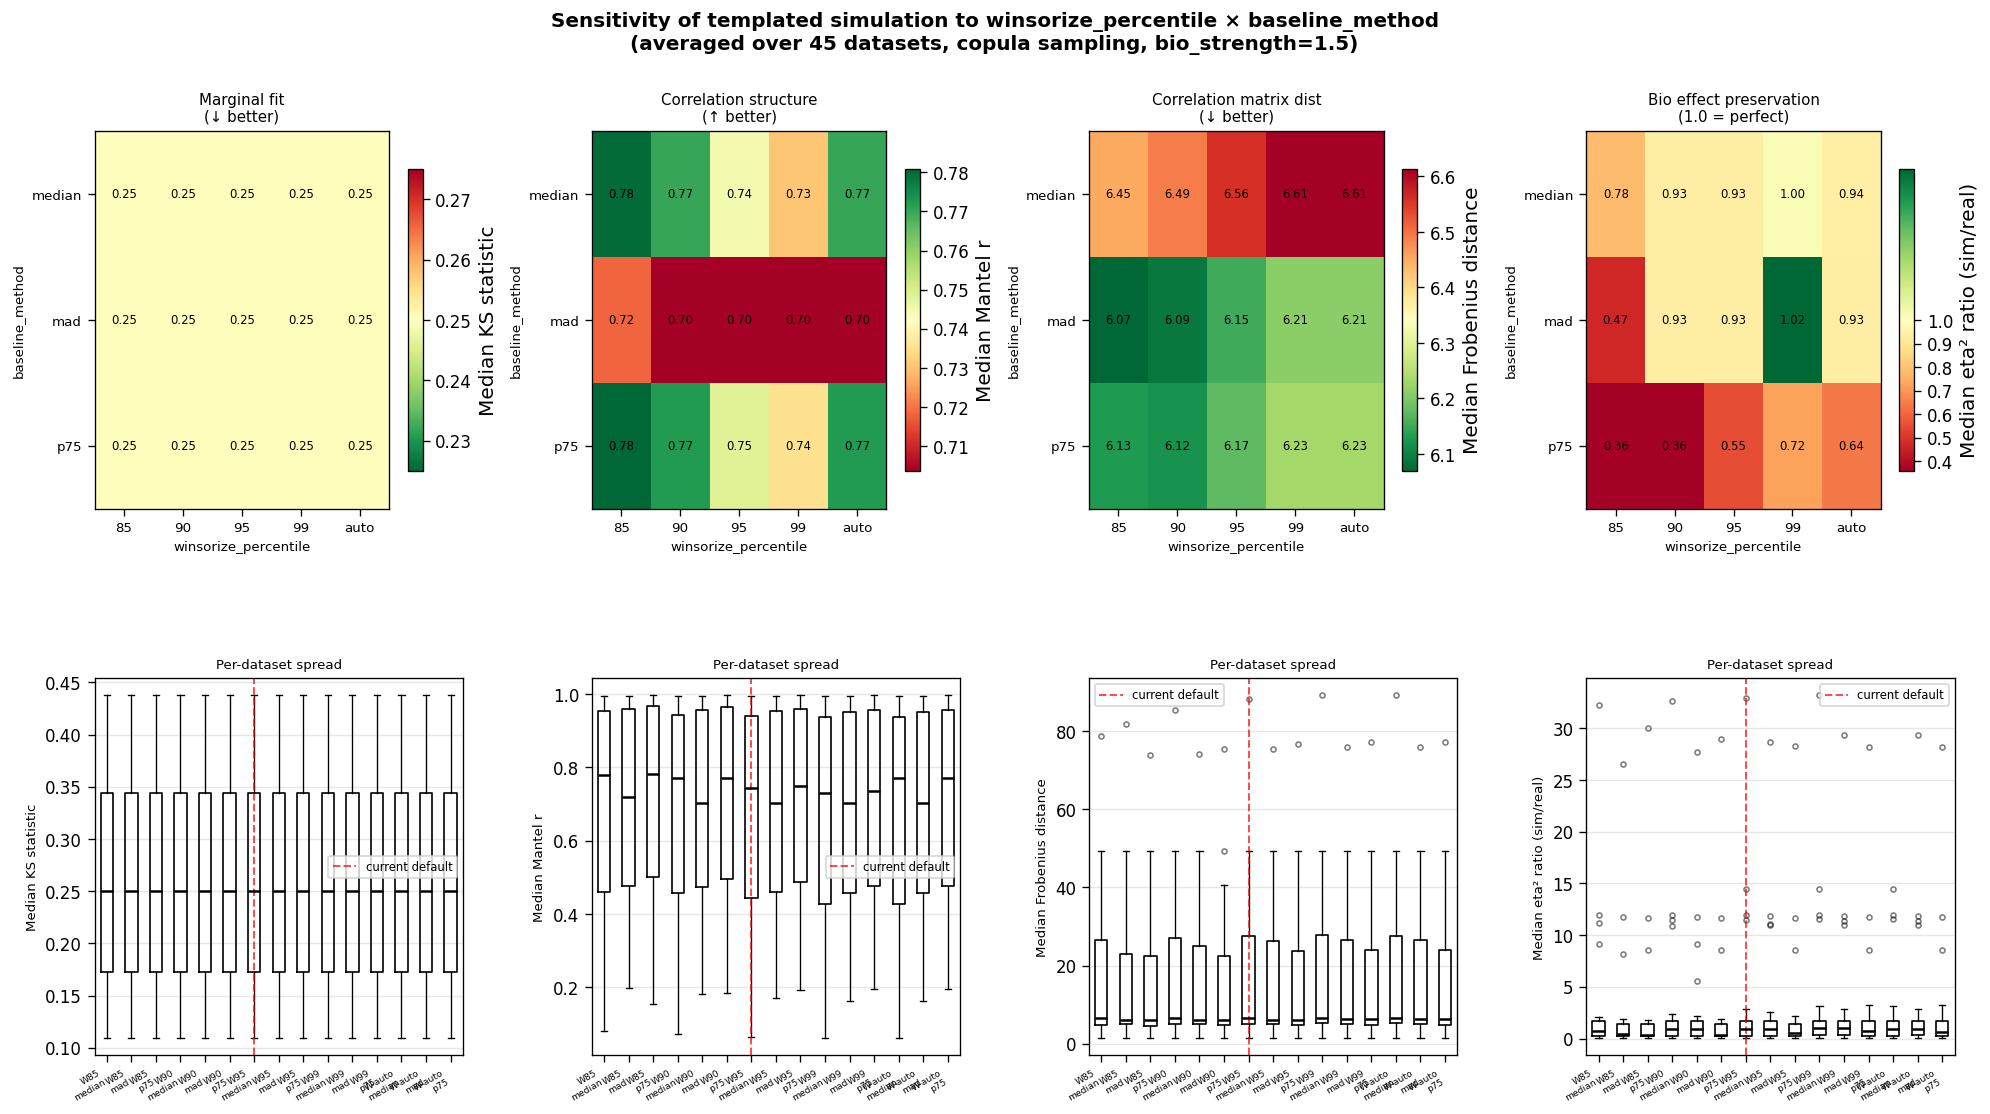

In [2]:
WINSORIZE_OPTS = [85, 90, 95, 99, None]   # None = auto-select
BASELINE_OPTS  = ['median', 'mad', 'p75']
N_SIM_RUNS     = 10

def _label(wp, bm):
  """Compact label for a (winsorize_percentile, baseline_method) combo."""
  wp_str = f'W{wp}' if wp is not None else 'W-auto'
  return f'{wp_str}\n{bm}'

def _copula_simulate(mu_H, mu_U, Sigma, real_clr, n_H, n_U, seed):
  """Gaussian copula with LW covariance + empirical marginals."""
  rng = np.random.default_rng(seed)
  n_features = Sigma.shape[0]
  std = np.sqrt(np.diag(Sigma))
  std = np.where(std < 1e-10, 1.0, std)
  R = Sigma / np.outer(std, std)
  np.fill_diagonal(R, 1.0)
  R += max(1e-8, 1e-4 * n_features) * np.eye(n_features)
  Z = rng.multivariate_normal(np.zeros(n_features), R, size=n_H + n_U)
  U = sp_norm.cdf(Z)
  n_real = real_clr.shape[0]
  sorted_real = np.sort(real_clr, axis=0)
  frac_idx = U * (n_real - 1)
  lo = np.floor(frac_idx).astype(int)
  hi = np.minimum(lo + 1, n_real - 1)
  t = frac_idx - lo
  X = sorted_real[lo, np.arange(n_features)] * (1 - t) + sorted_real[hi, np.arange(n_features)] * t
  X[n_H:] += (mu_U - mu_H)
  return X

def _bio_eta2(clr_data, n_H):
  """Eta² of PC1 between healthy (first n_H rows) and unhealthy."""
  pca = PCA(n_components=1)
  pc1 = pca.fit_transform(clr_data)[:, 0]
  labels = np.array([0] * n_H + [1] * (len(pc1) - n_H))
  groups = [pc1[labels == g] for g in [0, 1]]
  grand_mean = pc1.mean()
  ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
  ss_total = ((pc1 - grand_mean) ** 2).sum()
  return float(ss_between / ss_total) if ss_total > 1e-10 else 0.0

def validate_winsorization_params(
  datasets,
  bio_strength=1.5,
  k_dir=100,
  variance_ratio=1.5,
  differential_mask_mode='significant',
  filepath='',
):
  """Sweep winsorize_percentile × baseline_method for templated simulation.
  For each combo, simulates with the Gaussian copula (best approach from
  the sampling comparison) and computes KS statistic, Mantel r, Frobenius
  distance vs real data, and biological eta² preservation (simulated / real).
  Produces heatmaps (averaged over datasets) for all four metrics plus
  per-dataset strip plots to show variance across datasets.
  Parameters
  ----------
  datasets : list of dict, same format as compare_simulation_approaches.
  bio_strength, k_dir, variance_ratio : passed to define_bio_injection_from_real_data.
  differential_mask_mode : 'significant' or 'all'.
  filepath : if given, saves the figure (format inferred from extension).
  Returns
  -------
  dict: combo_label → dict of metric → per-dataset list, for downstream stats.
  """
  combos = [(wp, bm) for wp in WINSORIZE_OPTS for bm in BASELINE_OPTS]
  combo_labels = [_label(wp, bm) for wp, bm in combos]
  # per_combo[label] = {metric: [one value per valid dataset]}
  per_combo = {lbl: {'ks': [], 'mantel_r': [], 'frobenius': [], 'eta2_ratio': []}
               for lbl in combo_labels}
  for ds in datasets:
    df = ds['df'].copy()
    if df.columns.tolist()[0] == 'ID':
      df = df.T; df.columns = df.iloc[0]; df = df.drop(df.index[0])
    else:
      df = df.set_index(df.columns[0])
    df = df.apply(pd.to_numeric, errors='coerce')
    name = ds.get('name', 'Dataset')
    h_pfx = ds.get('healthy_prefix', '')
    u_pfx = ds.get('unhealthy_prefix', '')
    if not h_pfx or not u_pfx:
      continue
    r_cols = [c for c in df.columns if c.startswith(h_pfx)]
    u_cols = [c for c in df.columns if c.startswith(u_pfx)]
    if not r_cols or not u_cols:
      continue
    n_H, n_U, n_glycans = len(r_cols), len(u_cols), df.shape[0]
    rng0 = np.random.default_rng(42)
    df_j = df.copy()
    for col in r_cols + u_cols:
      mask = (df_j[col] == 0) & df_j[col].notna()
      if mask.any():
        df_j.loc[mask, col] = rng0.uniform(1e-6, 1.1e-6, int(mask.sum()))
    df_filled = df_j[r_cols + u_cols].apply(
      lambda col: col.fillna(max(col.dropna().min() * 0.5, 1e-8)
                             if col.dropna().any() else 1e-8)
    )
    real_clr = clr(df_filled.values.T)          # (n_samples, n_glycans)
    real_corr = np.corrcoef(real_clr.T)
    triu = np.triu_indices(n_glycans, k=1)
    real_eta2 = _bio_eta2(real_clr, n_H)
    df_gw = df_j[r_cols + u_cols].reset_index()
    with warnings.catch_warnings():
      warnings.simplefilter('ignore')
      with contextlib.redirect_stdout(io.StringIO()):
        de = get_differential_expression(df_gw, group1=u_cols, group2=r_cols,
                                         transform='CLR', impute=True)
    if len(de) != n_glycans:
      effect_sizes = np.zeros(n_glycans); sig_arr = np.zeros(n_glycans)
      for i, (es, sig) in enumerate(zip(de['Effect size'],
                                        de.get('significant', [False] * len(de)))):
        orig_idx = de.index[i]
        if orig_idx < n_glycans:
          effect_sizes[orig_idx] = float(es) if not pd.isna(es) else 0.0
          sig_arr[orig_idx] = float(sig) if not pd.isna(sig) else 0.0
    else:
      effect_sizes = de['Effect size'].fillna(0.0).values
      sig_arr = (de['significant'].values.astype(float)
                 if 'significant' in de.columns else np.ones(n_glycans))
    diff_mask = sig_arr if differential_mask_mode == 'significant' else np.ones(n_glycans)
    p_h = np.clip(df_j[r_cols].mean(axis=1).values, 1e-8, None)
    p_h /= p_h.sum()
    Sigma_lw = LedoitWolf().fit(real_clr).covariance_
    mu_H = real_clr[:n_H].mean(0)
    print(f'\n[{name}]  n_H={n_H}  n_U={n_U}  n_glycans={n_glycans}  real_eta2={real_eta2:.3f}')
    for (wp, bm), lbl in zip(combos, combo_labels):
      _, _, debug = define_bio_injection_from_real_data(
        p_h=p_h, effect_sizes=effect_sizes, differential_mask=diff_mask,
        bio_strength=bio_strength, k_dir=k_dir, variance_ratio=variance_ratio,
        winsorize_percentile=wp, baseline_method=bm, verbose=False
      )
      mu_U = mu_H + np.array(debug['injection'])
      corr_accum = np.zeros((n_glycans, n_glycans))
      clr_run0 = None
      eta2_runs = []
      for run in range(N_SIM_RUNS):
        sc = _copula_simulate(mu_H, mu_U, Sigma_lw, real_clr, n_H, n_U, run)
        corr_accum += np.corrcoef(sc.T)
        if run == 0:
          clr_run0 = sc
        eta2_runs.append(_bio_eta2(sc, n_H))
      sim_corr = corr_accum / N_SIM_RUNS
      ks   = float(np.median([stats.ks_2samp(real_clr[:, g], clr_run0[:, g])[0]
                               for g in range(n_glycans)]))
      mantel_r = float(stats.pearsonr(real_corr[triu], sim_corr[triu])[0])
      frob     = float(np.linalg.norm(real_corr - sim_corr, 'fro'))
      eta2_sim = float(np.mean(eta2_runs))
      eta2_ratio = eta2_sim / real_eta2 if real_eta2 > 1e-4 else np.nan
      per_combo[lbl]['ks'].append(ks)
      per_combo[lbl]['mantel_r'].append(mantel_r)
      per_combo[lbl]['frobenius'].append(frob)
      per_combo[lbl]['eta2_ratio'].append(eta2_ratio)
      print(f'  {lbl.replace(chr(10)," "):12s}  KS={ks:.3f}  '
            f'Mantel r={mantel_r:.3f}  Frob={frob:.2f}  eta2_ratio={eta2_ratio:.2f}')
  # ── Build 2D grids (BASELINE_OPTS × WINSORIZE_OPTS) for heatmaps ──────────
  n_wp = len(WINSORIZE_OPTS)
  n_bm = len(BASELINE_OPTS)
  def make_grid(metric):
    grid = np.full((n_bm, n_wp), np.nan)
    for bi, bm in enumerate(BASELINE_OPTS):
      for wi, wp in enumerate(WINSORIZE_OPTS):
        lbl = _label(wp, bm)
        vals = [v for v in per_combo[lbl][metric] if not np.isnan(v)]
        if vals:
          grid[bi, wi] = np.median(vals)
    return grid
  metrics_cfg = [
    ('ks',         'Median KS statistic',          'Marginal fit\n(↓ better)',      False),
    ('mantel_r',   'Median Mantel r',               'Correlation structure\n(↑ better)', True),
    ('frobenius',  'Median Frobenius distance',     'Correlation matrix dist\n(↓ better)', False),
    ('eta2_ratio', 'Median eta² ratio (sim/real)',  'Bio effect preservation\n(1.0 = perfect)', None),
  ]
  wp_labels = [str(w) if w is not None else 'auto' for w in WINSORIZE_OPTS]
  # ── Figure layout: 4 heatmaps + 4 strip plots ─────────────────────────────
  fig = plt.figure(figsize=(20, 10))
  fig.suptitle(
    'Sensitivity of templated simulation to winsorize_percentile × baseline_method\n'
    f'(averaged over {len(datasets)} datasets, copula sampling, bio_strength={bio_strength})',
    fontsize=12, fontweight='bold'
  )
  gs = plt.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)
  for col, (metric, cbar_label, title, higher_better) in enumerate(metrics_cfg):
    grid = make_grid(metric)
    # Top row: heatmap
    ax_heat = fig.add_subplot(gs[0, col])
    if metric == 'eta2_ratio':
      # Diverging colormap centred at 1.0
      vmin = max(0, np.nanmin(grid)); vmax = np.nanmax(grid)
      vcenter = 1.0
      norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=max(vmax, vcenter + 1e-3))
      cmap = 'RdYlGn'
    else:
      norm = None
      cmap = 'RdYlGn_r' if not higher_better else 'RdYlGn'
    im = ax_heat.imshow(grid, aspect='auto', cmap=cmap, norm=norm)
    plt.colorbar(im, ax=ax_heat, shrink=0.8, label=cbar_label)
    ax_heat.set_xticks(range(n_wp))
    ax_heat.set_xticklabels(wp_labels, fontsize=8)
    ax_heat.set_yticks(range(n_bm))
    ax_heat.set_yticklabels(BASELINE_OPTS, fontsize=8)
    ax_heat.set_xlabel('winsorize_percentile', fontsize=8)
    ax_heat.set_ylabel('baseline_method', fontsize=8)
    ax_heat.set_title(title, fontsize=9)
    # Annotate cells
    for bi in range(n_bm):
      for wi in range(n_wp):
        v = grid[bi, wi]
        if not np.isnan(v):
          ax_heat.text(wi, bi, f'{v:.2f}', ha='center', va='center',
                       fontsize=7, color='black')
    # Bottom row: strip plot (variance across datasets per combo)
    ax_strip = fig.add_subplot(gs[1, col])
    all_vals = []
    for lbl in combo_labels:
      vals = [v for v in per_combo[lbl][metric] if not np.isnan(v)]
      all_vals.append(vals)
    positions = np.arange(len(combo_labels))
    ax_strip.boxplot(all_vals, positions=positions, widths=0.5,
                     medianprops=dict(color='black', lw=1.5),
                     whiskerprops=dict(lw=0.8), capprops=dict(lw=0.8),
                     flierprops=dict(marker='o', ms=3, alpha=0.5))
    # Highlight the default combo (W95/median) in red
    default_lbl = _label(95, 'median')
    if default_lbl in combo_labels:
      di = combo_labels.index(default_lbl)
      ax_strip.axvline(di, color='red', lw=1.2, ls='--', alpha=0.7, label='current default')
      ax_strip.legend(fontsize=7)
    ax_strip.set_xticks(positions)
    ax_strip.set_xticklabels(combo_labels, fontsize=5.5, rotation=30, ha='right')
    ax_strip.set_ylabel(cbar_label.split('\n')[0], fontsize=8)
    ax_strip.set_title('Per-dataset spread', fontsize=8)
    ax_strip.grid(axis='y', alpha=0.3)
  if filepath:
    plt.savefig(filepath, format=Path(filepath).suffix[1:], dpi=300, bbox_inches='tight')
  plt.show()
  return per_combo

per_combo = validate_winsorization_params(
  datasets=datasets,
  bio_strength=1.5,
  k_dir=100,
  variance_ratio=1.5,
  filepath=f"{fp}/glycoforge_winsorization_sensitivity.pdf"
)

# Figure S13

SIMULATE_CLEAN_DATA
Simulated data Y_clean shape: (30, 50)
Min value: 6.49e-04
Max value: 14.44
Zero values: 0
SIMULATE_CLEAN_DATA
Simulated data Y_clean shape: (30, 50)
Min value: 9.07e-03
Max value: 20.86
Zero values: 0
SIMULATE_CLEAN_DATA
Simulated data Y_clean shape: (30, 50)
Min value: 2.22e-05
Max value: 12.83
Zero values: 0
SIMULATE_CLEAN_DATA
Simulated data Y_clean shape: (30, 50)
Min value: 8.60e-03
Max value: 22.20
Zero values: 0
SIMULATE_CLEAN_DATA
Simulated data Y_clean shape: (30, 50)
Min value: 2.88e-03
Max value: 12.45
Zero values: 0
SIMULATE_CLEAN_DATA
Simulated data Y_clean shape: (30, 50)
Min value: 2.91e-03
Max value: 18.77
Zero values: 0
SIMULATE_CLEAN_DATA
Simulated data Y_clean shape: (30, 50)
Min value: 2.15e-02
Max value: 13.77
Zero values: 0
SIMULATE_CLEAN_DATA
Simulated data Y_clean shape: (30, 50)
Min value: 1.37e-03
Max value: 15.56
Zero values: 0
SIMULATE_CLEAN_DATA
Simulated data Y_clean shape: (30, 50)
Min value: 8.81e-03
Max value: 14.91
Zero values: 0
S

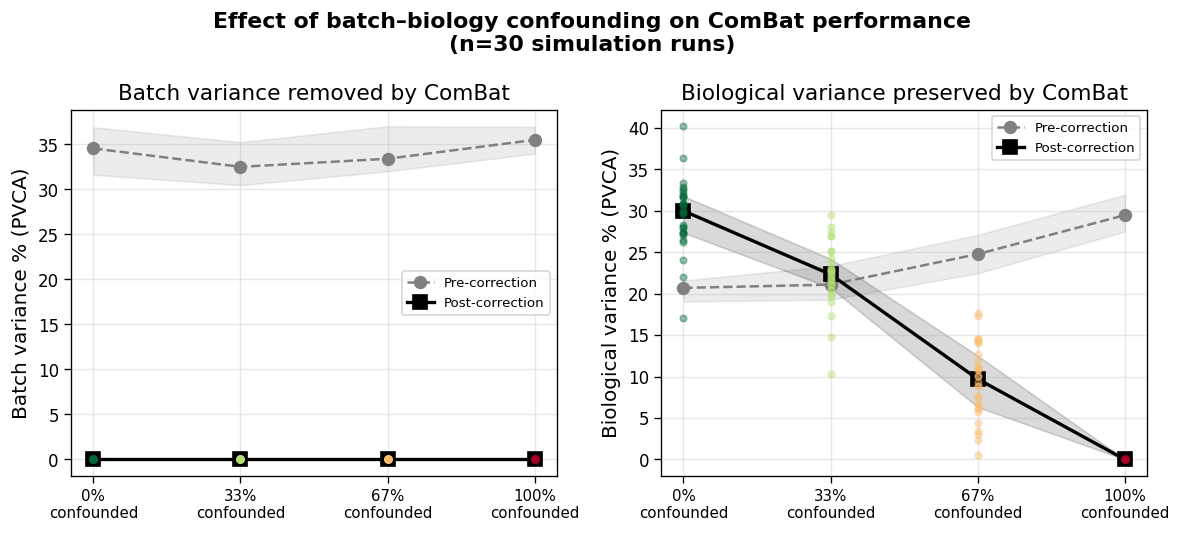

In [7]:
def _confounded_batches(columns, n_batches, seed, confound_fraction=1.0):
  rng = np.random.default_rng(seed)
  h = [c for c in columns if c.startswith('healthy')]
  u = [c for c in columns if c.startswith('unhealthy')]
  n_hb = int(np.ceil(n_batches / 2))
  rng.shuffle(h); rng.shuffle(u)
  n_H_confounded = int(len(h) * confound_fraction)
  n_U_confounded = int(len(u) * confound_fraction)
  H_conf, H_mix = h[:n_H_confounded], h[n_H_confounded:]
  U_conf, U_mix = u[:n_U_confounded], u[n_U_confounded:]
  bg = {i: [] for i in range(n_batches)}
  for i, s in enumerate(np.array_split(H_conf, n_hb) if H_conf else [[]]*n_hb):
    bg[i].extend(s)
  for i, s in enumerate(np.array_split(U_conf, n_batches - n_hb) if U_conf else [[]]*(n_batches-n_hb)):
    bg[n_hb + i].extend(s)
  all_ids = list(range(n_batches))
  for c in H_mix + U_mix:
    bg[rng.choice(all_ids)].append(c)
  bl = np.zeros(len(columns), dtype=int)
  for bid, cols in bg.items():
    for c in cols:
      bl[list(columns).index(c)] = bid
  return bg, bl

CONFOUND_FRACTIONS = [0.0, 0.33, 0.67, 1.0]  # 0 = stratified, 1 = fully confounded

N_H = 15
N_U = 15
N_BATCHES = 3
N_SEEDS = 30
n_glycans = 50
rng_a = np.random.default_rng(42)
raw = rng_a.lognormal(0, 1.0, n_glycans)
alpha_H = raw / np.mean(raw) * 10
sample_cols = [f'healthy_{i+1}' for i in range(N_H)] + [f'unhealthy_{i+1}' for i in range(N_U)]
bio_labels = np.array([0] * N_H + [1] * N_U)
u_dict, _ = define_batch_direction(batch_effect_direction=None, n_glycans=n_glycans, n_batches=N_BATCHES, affected_fraction=(0.3, 0.6), positive_prob=0.5, overlap_prob=0.3, u_dict_seed=42, verbose=False)
_clr_ref, _Sigma_ref = _build_copula_ref(len(alpha_H))
_K_bio = min(3, n_glycans - 1)
_, _evecs = np.linalg.eigh(_Sigma_ref)
_top_evecs = _evecs[:, -_K_bio:]
results = {cf: {'batch_pre': [], 'bio_pre': [], 'batch_post': [], 'bio_post': []}
           for cf in CONFOUND_FRACTIONS}

for seed in range(N_SEEDS):
  _rng_bio = np.random.default_rng(seed + 999)
  _signs = np.sign(_rng_bio.standard_normal(_K_bio))
  _inj_dir = (_top_evecs * _signs).T
  P, _ = simulate_clean_data(alpha_H, alpha_H, N_H, N_U, seed=seed,
                              real_clr_ref=_clr_ref, Sigma_lw=_Sigma_ref,
                              injection=_inj_dir, bio_strength=0.5, scale_injection=True)
  Y_clr_df = pd.DataFrame(clr(P).T, columns=sample_cols)
  sigma = estimate_sigma(Y_clr_df)
  for cf in CONFOUND_FRACTIONS:
    if cf == 0.0:
      bl = stratified_batches_from_columns(sample_cols, n_batches=N_BATCHES, seed=seed, verbose=False)[1]
    else:
      bl = _confounded_batches(sample_cols, N_BATCHES, seed, confound_fraction=cf)[1]
    Y_b_T, _ = apply_batch_effect(Y_clean=Y_clr_df.T.values, batch_labels=bl,
      u_dict=u_dict, sigma=sigma, kappa_mu=1.0, var_b=0.5, seed=seed)
    Y_b_df = pd.DataFrame(Y_b_T.T, columns=sample_cols)
    pv = pvca_variance_decomposition(Y_b_df, bl, bio_labels)
    results[cf]['batch_pre'].append(pv['batch_variance_pct'])
    results[cf]['bio_pre'].append(pv['bio_variance_pct'])
    try:
      Y_corr = combat(Y_b_df, pd.Series(bl, index=sample_cols))
      pv2 = pvca_variance_decomposition(Y_corr, bl, bio_labels)
      results[cf]['batch_post'].append(pv2['batch_variance_pct'])
      results[cf]['bio_post'].append(pv2['bio_variance_pct'])
    except Exception as e:
      print(f'ComBat failed seed={seed} cf={cf}: {e}')

labels = [f'{int(cf*100)}%\nconfounded' for cf in CONFOUND_FRACTIONS]
x = np.arange(len(CONFOUND_FRACTIONS))
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
cmap = plt.cm.RdYlGn_r
colors = [cmap(cf) for cf in CONFOUND_FRACTIONS]
for ax, pre_k, post_k, ylabel, title in zip(axes,
    ['batch_pre', 'bio_pre'], ['batch_post', 'bio_post'],
    ['Batch variance % (PVCA)', 'Biological variance % (PVCA)'],
    ['Batch variance removed by ComBat', 'Biological variance preserved by ComBat']):
  pre_medians  = [np.median(results[cf][pre_k])  for cf in CONFOUND_FRACTIONS]
  post_medians = [np.median(results[cf][post_k]) for cf in CONFOUND_FRACTIONS]
  pre_q25  = [np.percentile(results[cf][pre_k], 25)  for cf in CONFOUND_FRACTIONS]
  pre_q75  = [np.percentile(results[cf][pre_k], 75)  for cf in CONFOUND_FRACTIONS]
  post_q25 = [np.percentile(results[cf][post_k], 25) for cf in CONFOUND_FRACTIONS]
  post_q75 = [np.percentile(results[cf][post_k], 75) for cf in CONFOUND_FRACTIONS]
  ax.plot(x, pre_medians,  'o--', color='gray',  label='Pre-correction',  lw=1.5, ms=7)
  ax.fill_between(x, pre_q25,  pre_q75,  alpha=0.15, color='gray')
  ax.plot(x, post_medians, 's-',  color='black', label='Post-correction', lw=2,   ms=8)
  ax.fill_between(x, post_q25, post_q75, alpha=0.15, color='black')
  for xi, cf in enumerate(CONFOUND_FRACTIONS):
    ax.scatter([xi]*len(results[cf][post_k]), results[cf][post_k],
               color=colors[xi], alpha=0.4, s=15, zorder=3)
  ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
  ax.set_ylabel(ylabel); ax.set_title(title)
  ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle(f'Effect of batch–biology confounding on ComBat performance\n(n={N_SEEDS} simulation runs)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{fp}/confounding_gradient.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Figure S6

DYSREGULATED  HIV_gagtransfection_N_PMID35112714: mean Neu5Ac effect=-0.60
neutral       HIV_gagtransfection_O_PMID35112714: mean Neu5Ac effect=0.11
DYSREGULATED  cell_lines_gRNA_GPST000463: mean Neu5Ac effect=55.72
DYSREGULATED  human_brain_GSL_PMID38343116: mean Neu5Ac effect=-9.61
DYSREGULATED  human_brain_N_PMID38343116: mean Neu5Ac effect=1.37
DYSREGULATED  human_brain_O_PMID38343116: mean Neu5Ac effect=23.78
neutral       human_colorectal_N_PMID26085185: mean Neu5Ac effect=-0.03
neutral       human_colorectal_N_PMID39947398: mean Neu5Ac effect=-0.10
DYSREGULATED  human_colorectal_O_PMC9254241: mean Neu5Ac effect=-0.45
DYSREGULATED  human_colorectal_O_PMID19152289: mean Neu5Ac effect=0.55
neutral       human_gastric_O_PMC5762837: mean Neu5Ac effect=0.05
DYSREGULATED  human_leukemia_N_PMID34646384: mean Neu5Ac effect=0.53
DYSREGULATED  human_leukemia_O_PMID34646384: mean Neu5Ac effect=1.13
DYSREGULATED  human_liver_O_PMC5383776: mean Neu5Ac effect=1.27
DYSREGULATED  human_macrophag

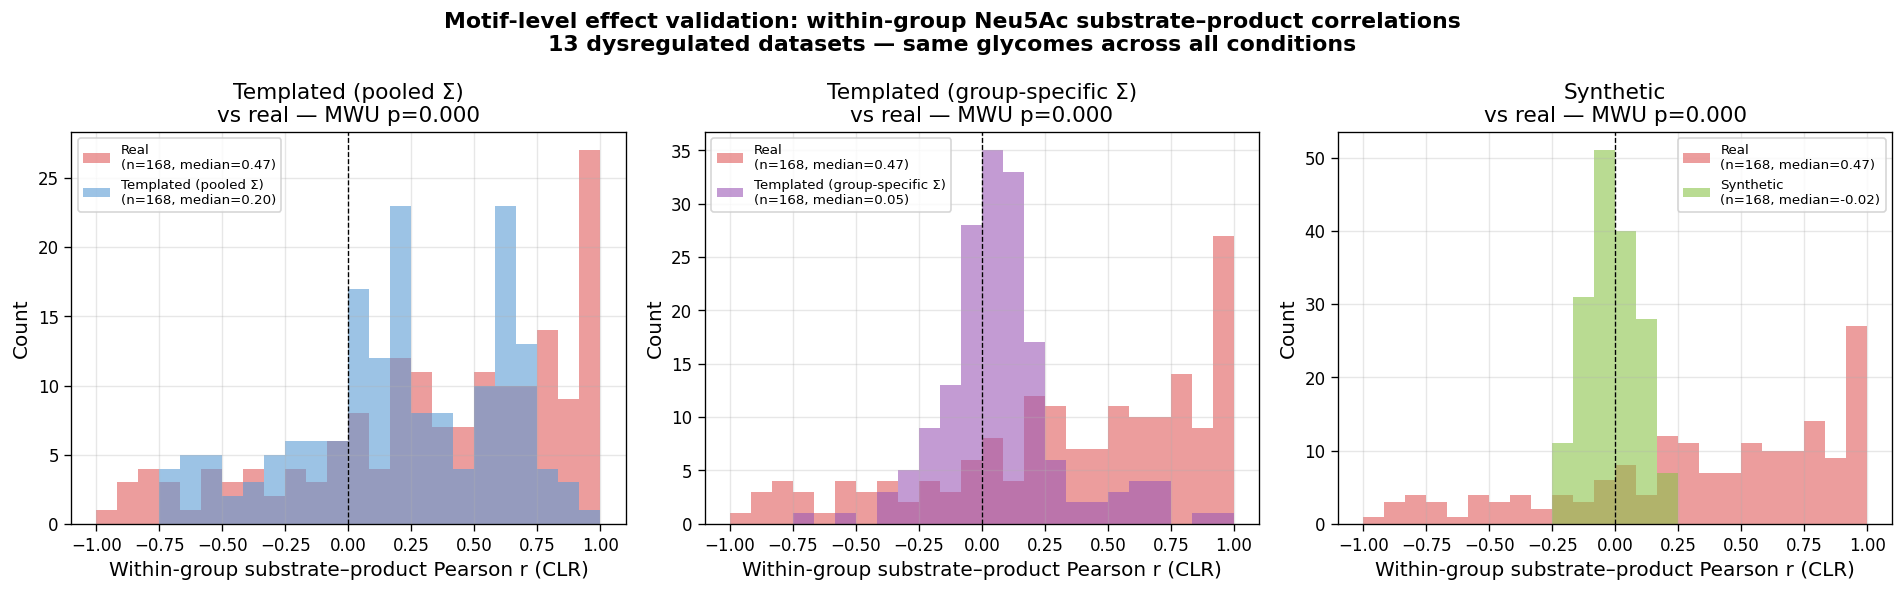

Templated (pooled)            : n=168, median=0.205, MWU p=0.0002
Templated (group-Σ)           : n=168, median=0.050, MWU p=0.0000
Synthetic                     : n=168, median=-0.018, MWU p=0.0000


In [11]:
N_SIM_SEEDS = 20
DYSREG_THRESHOLD = 0.3
# ── Classify each dataset ─────────────────────────────────────────────
dysregulated_datasets = []
for ds in datasets:
  h_pfx = ds.get('healthy_prefix', '')
  u_pfx = ds.get('unhealthy_prefix', '')
  if not h_pfx or not u_pfx:
    continue
  df = ds['df'].copy()
  if df.columns[0] not in [c for c in df.columns if c.startswith((h_pfx, u_pfx))]:
    df = df.set_index(df.columns[0])
  df = df.apply(pd.to_numeric, errors='coerce')
  r_cols = [c for c in df.columns if c.startswith(h_pfx)]
  u_cols = [c for c in df.columns if c.startswith(u_pfx)]
  if not r_cols or not u_cols:
    continue
  glycan_seqs = list(df.index)
  if not any('(' in g for g in glycan_seqs[:5]):
    continue
  n_glycans = len(glycan_seqs)
  rng0 = np.random.default_rng(42)
  df_j = df.copy()
  for col in r_cols + u_cols:
    mask = (df_j[col] == 0) & df_j[col].notna()
    if mask.any():
      df_j.loc[mask, col] = rng0.uniform(1e-6, 1.1e-6, int(mask.sum()))
  df_gw = df_j[r_cols + u_cols].reset_index()
  with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    with contextlib.redirect_stdout(io.StringIO()):
      de = get_differential_expression(df_gw, group1=u_cols, group2=r_cols,
                                       transform='CLR', impute=True)
  if len(de) != n_glycans:
    effect_sizes = np.zeros(n_glycans)
    sig_arr = np.zeros(n_glycans)
    for i, (es, sig) in enumerate(zip(de['Effect size'],
                                      de.get('significant', [False]*len(de)))):
      orig_idx = de.index[i]
      if orig_idx < n_glycans:
        effect_sizes[orig_idx] = float(es) if not pd.isna(es) else 0.0
        sig_arr[orig_idx] = float(sig) if not pd.isna(sig) else 0.0
  else:
    effect_sizes = de['Effect size'].fillna(0.0).values
    sig_arr = (de['significant'].values.astype(float)
               if 'significant' in de.columns else np.ones(n_glycans))
  neu5ac_indices = [i for i, g in enumerate(glycan_seqs) if subgraph_isomorphism(g, 'Neu5Ac')]
  if not neu5ac_indices:
    continue
  mean_neu5ac_effect = np.mean(effect_sizes[neu5ac_indices])
  entry = {**ds, 'df_j': df_j, 'r_cols': r_cols, 'u_cols': u_cols,
           'glycan_seqs': glycan_seqs, 'effect_sizes': effect_sizes,
           'sig_arr': sig_arr, 'mean_neu5ac_effect': mean_neu5ac_effect}
  if abs(mean_neu5ac_effect) >= DYSREG_THRESHOLD:
    dysregulated_datasets.append(entry)
    print(f"DYSREGULATED  {ds['name']}: mean Neu5Ac effect={mean_neu5ac_effect:.2f}")
  else:
    print(f"neutral       {ds['name']}: mean Neu5Ac effect={mean_neu5ac_effect:.2f}")
print(f"\n{len(dysregulated_datasets)} dysregulated datasets (used for all three conditions)")
real_pair_corrs         = []
sim_templated_corrs     = []
sim_templated_gs_corrs  = []   # group-specific copula
sim_synthetic_corrs     = []

for entry in dysregulated_datasets:
  n_H = len(entry['r_cols'])
  n_U = len(entry['u_cols'])
  n_glycans = len(entry['glycan_seqs'])
  real_clr = clr(entry['df_j'][entry['r_cols'] + entry['u_cols']].values.T)
  real_clr_H = real_clr[:n_H]
  real_clr_U = real_clr[n_H:]
  direction = 'down' if entry['mean_neu5ac_effect'] < 0 else 'up'
  pairs = find_compositional_pairs(entry['glycan_seqs'], {'Neu5Ac': direction}, verbose=False)
  subs, prods = pairs['substrates'], pairs['products']
  if not subs:
    continue
  # ── Real: within-group correlations averaged across H and U ───────────────
  for si, pi in zip(subs, prods):
    r_H = pearsonr(real_clr_H[:, si], real_clr_H[:, pi])[0] if n_H > 2 else np.nan
    r_U = pearsonr(real_clr_U[:, si], real_clr_U[:, pi])[0] if n_U > 2 else np.nan
    vals = [v for v in [r_H, r_U] if not np.isnan(v)]
    if vals:
      real_pair_corrs.append(np.mean(vals))
  # ── Shared: Params and masks ────────────────────────────────────
  p_h = np.clip(entry['df_j'][entry['r_cols']].mean(axis=1).values, 1e-8, None)
  p_h /= p_h.sum()
  neu5ac_mask = np.array([1.0 if subgraph_isomorphism(g, 'Neu5Ac') else 0.0
                          for g in entry['glycan_seqs']])
  alpha_H_t, alpha_U_t, _ = define_bio_injection_from_real_data(
    p_h=p_h, effect_sizes=entry['effect_sizes'], differential_mask=neu5ac_mask,
    bio_strength=1.5, k_dir=100, variance_ratio=1.5, verbose=False
  )
  # ── Templated (pooled covariance (used approach)) ──────────────────────────────
  Sigma_pooled = LedoitWolf().fit(real_clr).covariance_
  seed_corrs_t = []
  for seed in range(N_SIM_SEEDS):
    P_t, _ = simulate_clean_data(alpha_H_t, alpha_U_t, n_H, n_U, seed=seed,
                                 real_clr_ref=real_clr, Sigma_lw=Sigma_pooled)
    sc = clr(P_t)
    seed_corrs_t.append([np.mean([
      pearsonr(sc[:n_H, si], sc[:n_H, pi])[0],
      pearsonr(sc[n_H:, si], sc[n_H:, pi])[0]]) for si, pi in zip(subs, prods)])
  sim_templated_corrs.extend(np.mean(seed_corrs_t, axis=0).tolist())
  # ── Templated (group-specific covariance (test for estimating within-group separately)) ──────────────────────
  # Fit LW separately per group so within-group flux correlations are preserved
  # rather than blurred by the pooled covariance and then double-shifted by injection
  Sigma_H = LedoitWolf().fit(real_clr_H).covariance_ if n_H > 3 else Sigma_pooled
  Sigma_U = LedoitWolf().fit(real_clr_U).covariance_ if n_U > 3 else Sigma_pooled
  seed_corrs_gs = []
  for seed in range(N_SIM_SEEDS):
    rng = np.random.default_rng(seed)
    # Simulate healthy from healthy-group copula
    std_H = np.sqrt(np.diag(Sigma_H)); std_H[std_H < 1e-10] = 1.0
    R_H = Sigma_H / np.outer(std_H, std_H); np.fill_diagonal(R_H, 1.0)
    R_H_reg = R_H + max(1e-8, 1e-4 * n_glycans) * np.eye(n_glycans)
    Z_H = rng.multivariate_normal(np.zeros(n_glycans), R_H_reg, size=n_H)
    from scipy.stats import norm as sp_norm
    U_H = sp_norm.cdf(Z_H)
    sorted_H = np.sort(real_clr_H, axis=0)
    n_rH = real_clr_H.shape[0]
    fi = U_H * (n_rH - 1); lo = np.floor(fi).astype(int); hi = np.minimum(lo+1, n_rH-1); t = fi - lo
    X_H = sorted_H[lo, np.arange(n_glycans)] * (1-t) + sorted_H[hi, np.arange(n_glycans)] * t
    # Simulate unhealthy from unhealthy-group copula
    std_U = np.sqrt(np.diag(Sigma_U)); std_U[std_U < 1e-10] = 1.0
    R_U = Sigma_U / np.outer(std_U, std_U); np.fill_diagonal(R_U, 1.0)
    R_U_reg = R_U + max(1e-8, 1e-4 * n_glycans) * np.eye(n_glycans)
    Z_U = rng.multivariate_normal(np.zeros(n_glycans), R_U_reg, size=n_U)
    U_U = sp_norm.cdf(Z_U)
    sorted_U = np.sort(real_clr_U, axis=0)
    n_rU = real_clr_U.shape[0]
    fi = U_U * (n_rU - 1); lo = np.floor(fi).astype(int); hi = np.minimum(lo+1, n_rU-1); t = fi - lo
    X_U = sorted_U[lo, np.arange(n_glycans)] * (1-t) + sorted_U[hi, np.arange(n_glycans)] * t
    sc_gs = np.vstack([X_H, X_U])
    seed_corrs_gs.append([np.mean([
      pearsonr(sc_gs[:n_H, si], sc_gs[:n_H, pi])[0],
      pearsonr(sc_gs[n_H:, si], sc_gs[n_H:, pi])[0]]) for si, pi in zip(subs, prods)])
  sim_templated_gs_corrs.extend(np.mean(seed_corrs_gs, axis=0).tolist())
 # ── Synthetic (pooled cross-dataset copula, no dataset-specific covariance) ─
  from glycoforge.pipeline import _build_copula_ref
  _clr_ref_syn, _Sigma_syn = _build_copula_ref(n_glycans)
  rng_a = np.random.default_rng(42)
  raw = rng_a.lognormal(0, 1.0, n_glycans)
  alpha_H_s = raw / np.mean(raw) * 10
  _K_bio = min(3, n_glycans - 1)
  _, _evecs_syn = np.linalg.eigh(_Sigma_syn)
  _top_evecs_syn = _evecs_syn[:, -_K_bio:]
  seed_corrs_s = []
  for seed in range(N_SIM_SEEDS):
    _rng_bio = np.random.default_rng(seed + 999)
    _signs = np.sign(_rng_bio.standard_normal(_K_bio))
    _inj_dir = (_top_evecs_syn * _signs).T
    alpha_U_s, _ = generate_alpha_U(alpha_H_s, up_frac=0.3, down_frac=0.35,
      glycan_sequences=entry['glycan_seqs'], motif_rules={'Neu5Ac': direction}, seed=seed)
    P_s, _ = simulate_clean_data(alpha_H_s, alpha_U_s, n_H, n_U, seed=seed,
      real_clr_ref=_clr_ref_syn, Sigma_lw=_Sigma_syn,
      injection=_inj_dir, bio_strength=1.5, scale_injection=True)
    sc_s = clr(P_s)
    seed_corrs_s.append([np.mean([
      pearsonr(sc_s[:n_H, si], sc_s[:n_H, pi])[0],
      pearsonr(sc_s[n_H:, si], sc_s[n_H:, pi])[0]]) for si, pi in zip(subs, prods)])
  sim_synthetic_corrs.extend(np.mean(seed_corrs_s, axis=0).tolist())

# ── Plot and test ──────────────────────────────────────────────────────────────
real_arr    = np.array(real_pair_corrs)
sim_t_arr   = np.array(sim_templated_corrs)
sim_gs_arr  = np.array(sim_templated_gs_corrs)
sim_syn_arr = np.array(sim_synthetic_corrs)
_, p_rt  = mannwhitneyu(real_arr, sim_t_arr,  alternative='two-sided')
_, p_rgs = mannwhitneyu(real_arr, sim_gs_arr, alternative='two-sided')
_, p_rs  = mannwhitneyu(real_arr, sim_syn_arr, alternative='two-sided')
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bins = np.linspace(-1, 1, 25)
for ax, arr, color, label, p in [
  (axes[0], sim_t_arr,   '#5B9BD5', 'Templated (pooled Σ)', p_rt),
  (axes[1], sim_gs_arr,  '#9B59B6', 'Templated (group-specific Σ)', p_rgs),
  (axes[2], sim_syn_arr, '#8BC34A', 'Synthetic', p_rs),
]:
  ax.hist(real_arr, bins=bins, alpha=0.6, color='#E05C5C',
    label=f'Real\n(n={len(real_arr)}, median={np.median(real_arr):.2f})')
  ax.hist(arr, bins=bins, alpha=0.6, color=color,
    label=f'{label}\n(n={len(arr)}, median={np.median(arr):.2f})')
  ax.axvline(0, color='black', lw=0.8, ls='--')
  ax.set_xlabel('Within-group substrate–product Pearson r (CLR)')
  ax.set_ylabel('Count')
  ax.set_title(f'{label}\nvs real — MWU p={p:.3f}')
  ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle(
  'Motif-level effect validation: within-group Neu5Ac substrate–product correlations\n'
  f'{len(dysregulated_datasets)} dysregulated datasets — same glycomes across all conditions',
  fontweight='bold')
plt.tight_layout()
plt.savefig(f'{fp}/motif_correlation_validation.pdf', dpi=300, bbox_inches='tight')
plt.show()
for label, arr, p in [('Templated (pooled)', sim_t_arr, p_rt),
                      ('Templated (group-Σ)', sim_gs_arr, p_rgs),
                      ('Synthetic',           sim_syn_arr, p_rs)]:
  print(f"{label:30s}: n={len(arr)}, median={np.median(arr):.3f}, MWU p={p:.4f}")

# Figure S12

[Colorectal-N]  n_glycans=26  sparsity=0.46  affected=0.27  batch |cos| 0.537→0.000  shift_red=1.00  bio_cos=(0.93,0.98)  bio_mag=(1.34,1.55)
[Leukemia-N]  n_glycans=26  sparsity=0.42  affected=0.31  batch |cos| 0.591→0.000  shift_red=1.00  bio_cos=(0.85,nan)  bio_mag=(2.28,nan)
[Leukemia-O]  n_glycans=11  sparsity=0.55  affected=0.36  batch |cos| 0.581→0.000  shift_red=1.00  bio_cos=(0.96,nan)  bio_mag=(1.23,nan)
[Skin-O]  n_glycans=13  sparsity=0.62  affected=0.31  batch |cos| 0.480→0.000  shift_red=1.00  bio_cos=(0.99,1.00)  bio_mag=(1.12,1.74)


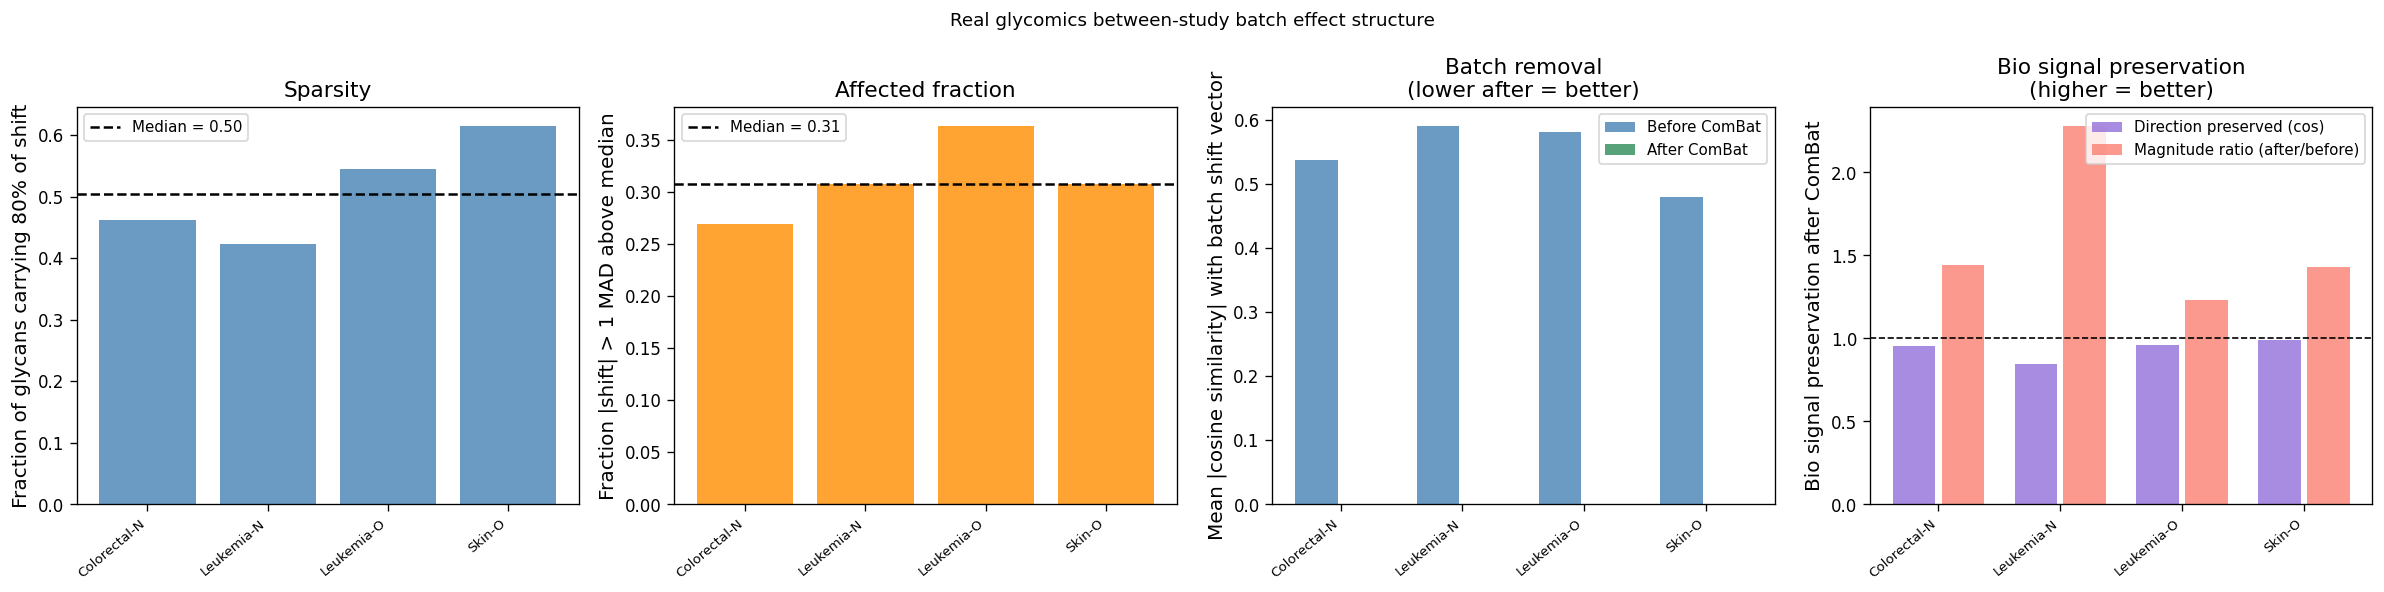


Summary across 4 cross-study pairs:
  Median sparsity (fraction carrying 80% of shift): 0.50
  Median affected fraction (|shift| > 1 MAD):       0.31
  Median |cos| before/after ComBat:                 0.559 → 0.000
  Median shift reduction by ComBat:                 1.000
  Median bio direction preserved (cos):             0.957
  Median bio magnitude ratio after/before:          1.437


In [13]:
dataset_pairs = [
  {'name': 'Colorectal-N',
   'ds1': {'df': glycomics_data_loader.human_colorectal_N_PMID26085185}, 'healthy_prefix1': 'Avg_RA_N', 'unhealthy_prefix1': 'Avg_RA_T',
   'ds2': {'df': glycomics_data_loader.human_colorectal_N_PMID39947398}, 'healthy_prefix2': 'healthy',   'unhealthy_prefix2': 'stage'},
  {'name': 'Leukemia-N',
   'ds1': {'df': glycomics_data_loader.human_leukemia_N_PMID34646384},   'healthy_prefix1': 'R7',        'unhealthy_prefix1': 'BM',
   'ds2': {'df': glycomics_data_loader.human_leukemia_N_PMID36788594},   'healthy_prefix2': '',          'unhealthy_prefix2': ''},
  {'name': 'Leukemia-O',
   'ds1': {'df': glycomics_data_loader.human_leukemia_O_PMID34646384},   'healthy_prefix1': 'R7',        'unhealthy_prefix1': 'BM',
   'ds2': {'df': glycomics_data_loader.human_leukemia_O_PMID36788594},   'healthy_prefix2': '',          'unhealthy_prefix2': ''},
  {'name': 'Skin-O',
   'ds1': {'df': glycomics_data_loader.human_skin_O_PMC5871710_BCC},     'healthy_prefix1': 'control',   'unhealthy_prefix1': 'tumor',
   'ds2': {'df': glycomics_data_loader.human_skin_O_PMC5871710_SCC},     'healthy_prefix2': 'control',   'unhealthy_prefix2': 'tumor'},
]

def validate_batch_effect_structure(dataset_pairs, filepath=''):
  results = []
  for pair in dataset_pairs:
    name = pair['name']
    def _prep(df_raw):
      df = df_raw.copy()
      first_col = df.columns[0]
      if df[first_col].dtype == object:
        df = df.set_index(first_col)
      df = df.apply(pd.to_numeric, errors='coerce')
      df = df.replace(0.0, np.nan)
      df = df.dropna(how='all')
      return df
    df1 = _prep(pair['ds1']['df'])
    df2 = _prep(pair['ds2']['df'])
    shared = sorted(set(df1.index) & set(df2.index))
    if len(shared) < 5:
      print(f'[{name}] Skipped: only {len(shared)} shared glycans')
      continue
    df1 = df1.loc[shared]; df2 = df2.loc[shared]
    df1 = df1[~df1.index.duplicated(keep='first')]
    df2 = df2[~df2.index.duplicated(keep='first')]
    shared = sorted(set(df1.index) & set(df2.index))
    df1 = df1.loc[shared]; df2 = df2.loc[shared]
    df1 = df1.fillna(df1.min(axis=0) * 0.5).fillna(1e-6)
    df2 = df2.fillna(df2.min(axis=0) * 0.5).fillna(1e-6)
    # Build bio labels within each study (1=unhealthy, 0=healthy, -1=unknown)
    def _bio_labels(df, hp, up):
      labels = []
      for c in df.columns:
        if hp and str(c).startswith(hp):
          labels.append(0)
        elif up and str(c).startswith(up):
          labels.append(1)
        else:
          labels.append(-1)
      return np.array(labels)
    bio1 = _bio_labels(df1, pair.get('healthy_prefix1',''), pair.get('unhealthy_prefix1',''))
    bio2 = _bio_labels(df2, pair.get('healthy_prefix2',''), pair.get('unhealthy_prefix2',''))
    clr1 = clr(df1.values.T)
    clr2 = clr(df2.values.T)
    n_glycans = len(shared)
    # Batch shift characterization
    delta = clr2.mean(axis=0) - clr1.mean(axis=0)
    abs_delta = np.abs(delta)
    sorted_abs = np.sort(abs_delta)[::-1]
    cumsum = np.cumsum(sorted_abs)
    total = cumsum[-1]
    if total < 1e-10:
      print(f'[{name}] Skipped: near-zero shift')
      continue
    n80 = int(np.searchsorted(cumsum, 0.80 * total)) + 1
    sparsity_frac = n80 / n_glycans
    mad = np.median(np.abs(abs_delta - np.median(abs_delta)))
    affected_frac = float(np.mean(abs_delta > np.median(abs_delta) + mad))
    Y_all = np.vstack([clr1, clr2])
    grand_mean = Y_all.mean(axis=0)
    delta_norm = delta / (np.linalg.norm(delta) + 1e-10)
    cos_sims = np.array([
      np.dot(Y_all[i] - grand_mean, delta_norm) / (np.linalg.norm(Y_all[i] - grand_mean) + 1e-10)
      for i in range(Y_all.shape[0])
    ])
    expected_signs = np.array([-1]*clr1.shape[0] + [1]*clr2.shape[0])
    sign_consistency = float(np.mean(np.sign(cos_sims) == expected_signs))
    mean_abs_cos = float(np.mean(np.abs(cos_sims)))
    # Bio signal before ComBat: within-study healthy vs unhealthy delta
    def _bio_delta(clr_mat, bio_labels):
      h = clr_mat[bio_labels == 0]; u = clr_mat[bio_labels == 1]
      if len(h) == 0 or len(u) == 0:
        return None
      return u.mean(axis=0) - h.mean(axis=0)
    bio_delta1_before = _bio_delta(clr1, bio1)
    bio_delta2_before = _bio_delta(clr2, bio2)
    # ComBat
    batch_vec = [0]*clr1.shape[0] + [1]*clr2.shape[0]
    try:
      corrected = combat(Y_all.T, batch_vec)
      clr1_c = corrected[:, :clr1.shape[0]].T
      clr2_c = corrected[:, clr1.shape[0]:].T
      delta_c = clr2_c.mean(axis=0) - clr1_c.mean(axis=0)
      delta_c_norm = delta_c / (np.linalg.norm(delta_c) + 1e-10)
      Y_all_c = np.vstack([clr1_c, clr2_c])
      grand_mean_c = Y_all_c.mean(axis=0)
      cos_sims_c = np.array([
        np.dot(Y_all_c[i] - grand_mean_c, delta_c_norm) / (np.linalg.norm(Y_all_c[i] - grand_mean_c) + 1e-10)
        for i in range(Y_all_c.shape[0])
      ])
      mean_abs_cos_c = float(np.mean(np.abs(cos_sims_c)))
      shift_reduction = 1.0 - np.linalg.norm(delta_c) / (np.linalg.norm(delta) + 1e-10)
      # Bio signal after ComBat
      bio_delta1_after = _bio_delta(clr1_c, bio1)
      bio_delta2_after = _bio_delta(clr2_c, bio2)
      def _cos(a, b):
        if a is None or b is None: return np.nan
        return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10))
      def _mag_ratio(before, after):
        if before is None or after is None: return np.nan
        return float(np.linalg.norm(after) / (np.linalg.norm(before) + 1e-10))
      bio_cos1 = _cos(bio_delta1_before, bio_delta1_after)
      bio_cos2 = _cos(bio_delta2_before, bio_delta2_after)
      bio_mag1 = _mag_ratio(bio_delta1_before, bio_delta1_after)
      bio_mag2 = _mag_ratio(bio_delta2_before, bio_delta2_after)
      combat_failed = False
    except Exception as e:
      mean_abs_cos_c = shift_reduction = np.nan
      bio_cos1 = bio_cos2 = bio_mag1 = bio_mag2 = np.nan
      combat_failed = True
      print(f'  ComBat failed: {e}')
    results.append(dict(
      name=name, n_glycans=n_glycans,
      n_samples_1=clr1.shape[0], n_samples_2=clr2.shape[0],
      sparsity_frac=sparsity_frac, affected_frac=affected_frac,
      mean_abs_cos=mean_abs_cos, sign_consistency=sign_consistency,
      mean_abs_cos_c=mean_abs_cos_c, shift_reduction=shift_reduction,
      bio_cos1=bio_cos1, bio_cos2=bio_cos2,
      bio_mag1=bio_mag1, bio_mag2=bio_mag2,
      combat_failed=combat_failed, delta=delta,
    ))
    print(f'[{name}]  n_glycans={n_glycans}  sparsity={sparsity_frac:.2f}  '
          f'affected={affected_frac:.2f}  '
          f'batch |cos| {mean_abs_cos:.3f}→{mean_abs_cos_c:.3f}  '
          f'shift_red={shift_reduction:.2f}  '
          f'bio_cos=({bio_cos1:.2f},{bio_cos2:.2f})  '
          f'bio_mag=({bio_mag1:.2f},{bio_mag2:.2f})')
  if not results:
    print('No valid pairs found.')
    return results
  names = [r['name'] for r in results]
  x = np.arange(len(names))
  fig, axes = plt.subplots(1, 4, figsize=(20, 5))
  fig.suptitle('Real glycomics between-study batch effect structure', fontsize=11)
  axes[0].bar(x, [r['sparsity_frac'] for r in results], color='steelblue', alpha=0.8)
  axes[0].axhline(np.median([r['sparsity_frac'] for r in results]), color='k', ls='--', lw=1.5,
                  label=f"Median = {np.median([r['sparsity_frac'] for r in results]):.2f}")
  axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=40, ha='right', fontsize=8)
  axes[0].set_ylabel('Fraction of glycans carrying 80% of shift')
  axes[0].set_title('Sparsity'); axes[0].legend(fontsize=9)
  axes[1].bar(x, [r['affected_frac'] for r in results], color='darkorange', alpha=0.8)
  axes[1].axhline(np.median([r['affected_frac'] for r in results]), color='k', ls='--', lw=1.5,
                  label=f"Median = {np.median([r['affected_frac'] for r in results]):.2f}")
  axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=40, ha='right', fontsize=8)
  axes[1].set_ylabel('Fraction |shift| > 1 MAD above median')
  axes[1].set_title('Affected fraction'); axes[1].legend(fontsize=9)
  valid = [r for r in results if not r.get('combat_failed')]
  names_v = [r['name'] for r in valid]; x_v = np.arange(len(names_v))
  axes[2].bar(x_v - 0.2, [r['mean_abs_cos'] for r in valid], width=0.35,
              color='steelblue', alpha=0.8, label='Before ComBat')
  axes[2].bar(x_v + 0.2, [r['mean_abs_cos_c'] for r in valid], width=0.35,
              color='seagreen', alpha=0.8, label='After ComBat')
  axes[2].set_xticks(x_v); axes[2].set_xticklabels(names_v, rotation=40, ha='right', fontsize=8)
  axes[2].set_ylabel('Mean |cosine similarity| with batch shift vector')
  axes[2].set_title('Batch removal\n(lower after = better)'); axes[2].legend(fontsize=9)
  bio_cos_vals = [np.nanmean([r['bio_cos1'], r['bio_cos2']]) for r in valid]
  bio_mag_vals = [np.nanmean([r['bio_mag1'], r['bio_mag2']]) for r in valid]
  axes[3].bar(x_v - 0.2, bio_cos_vals, width=0.35, color='mediumpurple', alpha=0.8,
              label='Direction preserved (cos)')
  axes[3].bar(x_v + 0.2, bio_mag_vals, width=0.35, color='salmon', alpha=0.8,
              label='Magnitude ratio (after/before)')
  axes[3].axhline(1.0, color='k', ls='--', lw=1.0)
  axes[3].set_xticks(x_v); axes[3].set_xticklabels(names_v, rotation=40, ha='right', fontsize=8)
  axes[3].set_ylabel('Bio signal preservation after ComBat')
  axes[3].set_title('Bio signal preservation\n(higher = better)'); axes[3].legend(fontsize=9)
  plt.tight_layout()
  if filepath:
    from pathlib import Path
    plt.savefig(filepath, format=Path(filepath).suffix[1:], dpi=300, bbox_inches='tight')
  plt.show()
  print(f'\nSummary across {len(results)} cross-study pairs:')
  print(f'  Median sparsity (fraction carrying 80% of shift): {np.median([r["sparsity_frac"] for r in results]):.2f}')
  print(f'  Median affected fraction (|shift| > 1 MAD):       {np.median([r["affected_frac"] for r in results]):.2f}')
  print(f'  Median |cos| before/after ComBat:                 {np.median([r["mean_abs_cos"] for r in valid]):.3f} → {np.median([r["mean_abs_cos_c"] for r in valid]):.3f}')
  print(f'  Median shift reduction by ComBat:                 {np.median([r["shift_reduction"] for r in valid]):.3f}')
  print(f'  Median bio direction preserved (cos):             {np.nanmedian(bio_cos_vals):.3f}')
  print(f'  Median bio magnitude ratio after/before:          {np.nanmedian(bio_mag_vals):.3f}')
  return results

results = validate_batch_effect_structure(dataset_pairs, filepath=f'{fp}/batch_structure_validation.pdf')

# Figure S9

In [2]:
# Simulate data with batch mode
param_grid = {
    'bio_strength': [0.5, 1.0, 1.5, 2.0],
    'kappa_mu': [0.0, 0.5, 1.0, 1.5, 2.0],
    'var_b': [0.0, 0.3, 0.5, 0.8, 1.0],
    'batch_mode': ['additive', 'multiplicative']
}

# Optionally, run multiplicative grid only, combine with existing additive results
results_list = []
additive_detailed = pd.read_csv(f'{fp}/results/method_comparison_detailed.csv')
additive_detailed['batch_mode'] = 'additive'
base_config = {
    'data_source': 'simulated',
    'n_glycans': 50,
    'n_H': 15,
    'n_U': 15,
    'k_dir': 100,
    'n_batches': 3,
    'random_seeds': [42, 43, 44],
    'verbose': False,
    'save_csv': True
}
total_runs = len(param_grid['bio_strength']) * len(param_grid['kappa_mu']) * len(param_grid['var_b'])
run_idx = 0
for bio_strength in param_grid['bio_strength']:
    for kappa_mu in param_grid['kappa_mu']:
        for var_b in param_grid['var_b']:
            run_idx += 1
            print(f"[{run_idx}/{total_runs}] mode=multiplicative, bio={bio_strength}, kappa={kappa_mu}, var_b={var_b}")
            config = base_config.copy()
            config.update({
                'bio_strength': bio_strength,
                'kappa_mu': kappa_mu,
                'var_b': var_b,
                'batch_mode': 'multiplicative',
                'output_dir': f'{fp}/results/grid_multiplicative_{bio_strength}_{kappa_mu}_{var_b}'
            })
            simulate(**config)
            for seed in config['random_seeds']:
                output_dir = config['output_dir']
                Y_clean = pd.read_csv(f"{output_dir}/1_Y_clean_seed{seed}.csv", index_col=0)
                Y_clean_clr = pd.read_csv(f"{output_dir}/1_Y_clean_clr_seed{seed}.csv", index_col=0)
                Y_with_batch = pd.read_csv(f"{output_dir}/2_Y_with_batch_seed{seed}.csv", index_col=0)
                Y_with_batch_clr = pd.read_csv(f"{output_dir}/2_Y_with_batch_clr_seed{seed}.csv", index_col=0)
                with open(f"{output_dir}/metadata_seed{seed}.json") as f:
                    metadata = json.load(f)
                batch_labels = np.array(metadata['sample_info']['batch_labels'])
                bio_labels = np.array(metadata['sample_info']['bio_labels'])
                bio_groups = metadata['sample_info']['bio_groups']
                Y_with_batch_clr_fixed = add_noise_to_zero_variance_features(Y_with_batch_clr, noise_level=1e-10, random_seed=seed)
                Y_combat_clr = pd.DataFrame(
                    combat(Y_with_batch_clr_fixed.values, batch_labels, mod=bio_labels),
                    index=Y_with_batch_clr.index, columns=Y_with_batch_clr.columns
                )
                Y_combat = pd.DataFrame(index=Y_combat_clr.index, columns=Y_combat_clr.columns)
                for sample in Y_combat_clr.columns:
                    Y_combat[sample] = invclr(Y_combat_clr[sample].values)
                Y_percentile = pd.DataFrame(percentile_normalization(Y_with_batch.values, batch_labels), index=Y_with_batch.index, columns=Y_with_batch.columns)
                Y_percentile_clr = pd.DataFrame(clr(Y_percentile.values.T).T, index=Y_percentile.index, columns=Y_percentile.columns)
                Y_ratio = pd.DataFrame(ratio_preserving_combat(Y_with_batch.values, batch_labels, mod=bio_labels), index=Y_with_batch.index, columns=Y_with_batch.columns)
                Y_ratio_clr = pd.DataFrame(clr(Y_ratio.values.T).T, index=Y_ratio.index, columns=Y_ratio.columns)
                Y_harmony = pd.DataFrame(harmony_correction(Y_with_batch.values, batch_labels), index=Y_with_batch.index, columns=Y_with_batch.columns)
                Y_harmony_clr = pd.DataFrame(clr(Y_harmony.values.T).T, index=Y_harmony.index, columns=Y_harmony.columns)
                Y_limma = pd.DataFrame(limma_style_correction(Y_with_batch.values, batch_labels, mod=bio_labels), index=Y_with_batch.index, columns=Y_with_batch.columns)
                Y_limma_clr = pd.DataFrame(clr(Y_limma.values.T).T, index=Y_limma.index, columns=Y_limma.columns)
                Y_stratified = pd.DataFrame(stratified_combat(Y_with_batch.values, batch_labels, bio_labels), index=Y_with_batch.index, columns=Y_with_batch.columns)
                Y_stratified_clr = pd.DataFrame(clr(Y_stratified.values.T).T, index=Y_stratified.index, columns=Y_stratified.columns)
                for method_name, Y_corrected, Y_corrected_clr in [
                    ('uncorrected', Y_with_batch, Y_with_batch_clr),
                    ('combat', Y_combat, Y_combat_clr),
                    ('percentile', Y_percentile, Y_percentile_clr),
                    ('ratio', Y_ratio, Y_ratio_clr),
                    ('harmony', Y_harmony, Y_harmony_clr),
                    ('limma', Y_limma, Y_limma_clr),
                    ('stratified', Y_stratified, Y_stratified_clr)
                ]:
                    metrics = quantify_batch_effect_impact(Y_corrected_clr, batch_labels, bio_groups, verbose=False)
                    de = compare_differential_expression(dataset1=Y_clean, dataset2=Y_with_batch, dataset3=Y_corrected, verbose=False)
                    results_list.append({
                        'batch_mode': 'multiplicative',
                        'bio_strength': bio_strength,
                        'kappa_mu': kappa_mu,
                        'var_b': var_b,
                        'seed': seed,
                        'method': method_name,
                        'PVCA_batch_variance': metrics['pvca_batch_variance'],
                        'PVCA_bio_variance': metrics['pvca_bio_variance'],
                        'PVCA_residual_variance': metrics['pvca_residual_variance'],
                        'silhouette': metrics['silhouette'],
                        'kBET': metrics['kBET'],
                        'LISI': metrics['LISI'],
                        'ARI': metrics['ARI'],
                        'comp_effect': metrics['compositional_effect_size'],
                        'pca_batch': metrics['pca_batch_effect'],
                        'tp': de['results']['compare_1v3']['after_correction_errors']['tp_count'],
                        'fp': de['results']['compare_1v3']['after_correction_errors']['fp_count'],
                        'fn': de['results']['compare_1v3']['after_correction_errors']['fn_count'],
                        'sig_clean': de['results']['dataset1']['significant_count'],
                        'sig_corrected': de['results']['dataset3']['significant_count']
                    })
multiplicative_df = pd.DataFrame(results_list)
multiplicative_df['tp_rate'] = multiplicative_df['tp'] / multiplicative_df['sig_clean']
multiplicative_df['fp_rate'] = multiplicative_df['fp'] / (50 - multiplicative_df['sig_clean'])
multiplicative_df['fn_rate'] = multiplicative_df['fn'] / multiplicative_df['sig_clean']
multiplicative_df['f1'] = 2 * multiplicative_df['tp'] / (2 * multiplicative_df['tp'] + multiplicative_df['fp'] + multiplicative_df['fn'])
results_df = pd.concat([additive_detailed, multiplicative_df], ignore_index=True)

# Cell 4: Aggregate combined results
agg_results = results_df.groupby(['batch_mode', 'bio_strength', 'kappa_mu', 'var_b', 'method']).agg({
    'PVCA_batch_variance': 'mean', 'PVCA_bio_variance': 'mean', 'PVCA_residual_variance': 'mean',
    'silhouette': 'mean', 'kBET': 'mean', 'LISI': 'mean', 'ARI': 'mean',
    'comp_effect': 'mean', 'pca_batch': 'mean', 'tp_rate': 'mean',
    'fp_rate': 'mean', 'fn_rate': 'mean', 'f1': 'mean'
}).reset_index()
agg_results['batch_severity'] = pd.cut(
    agg_results['kappa_mu'] + agg_results['var_b'],
    bins=[-0.01, 0.01, 1.0, 1.5, 2.0, 3.0],
    labels=['Baseline', 'Weak', 'Moderate', 'Strong', 'Extreme']
)
results_df.to_csv(f'{fp}/results/method_comparison_additive_vs_multiplicative_detailed.csv', index=False)
agg_results.to_csv(f'{fp}/results/method_comparison_additive_vs_multiplicative_aggregated.csv', index=False)
print(f"Saved {len(results_df)} rows detailed, {len(agg_results)} rows aggregated")

[1/100] mode=multiplicative, bio=0.5, kappa=0.0, var_b=0.0
[2/100] mode=multiplicative, bio=0.5, kappa=0.0, var_b=0.3
[3/100] mode=multiplicative, bio=0.5, kappa=0.0, var_b=0.5
[4/100] mode=multiplicative, bio=0.5, kappa=0.0, var_b=0.8
[5/100] mode=multiplicative, bio=0.5, kappa=0.0, var_b=1.0
[6/100] mode=multiplicative, bio=0.5, kappa=0.5, var_b=0.0
[7/100] mode=multiplicative, bio=0.5, kappa=0.5, var_b=0.3
[8/100] mode=multiplicative, bio=0.5, kappa=0.5, var_b=0.5
[9/100] mode=multiplicative, bio=0.5, kappa=0.5, var_b=0.8
[10/100] mode=multiplicative, bio=0.5, kappa=0.5, var_b=1.0
[11/100] mode=multiplicative, bio=0.5, kappa=1.0, var_b=0.0
[12/100] mode=multiplicative, bio=0.5, kappa=1.0, var_b=0.3
[13/100] mode=multiplicative, bio=0.5, kappa=1.0, var_b=0.5
[14/100] mode=multiplicative, bio=0.5, kappa=1.0, var_b=0.8
[15/100] mode=multiplicative, bio=0.5, kappa=1.0, var_b=1.0
[16/100] mode=multiplicative, bio=0.5, kappa=1.5, var_b=0.0
[17/100] mode=multiplicative, bio=0.5, kappa=1.5,

In [3]:
method_order = ['uncorrected', 'combat', 'percentile', 'ratio', 'harmony', 'limma', 'stratified']
method_labels = ['Uncorrected', 'ComBat', 'Percentile', 'Ratio-ComBat', 'Harmony', 'Limma', 'Stratified']
colors = ['#7f7f7f', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
agg_results = pd.read_csv(f'{fp}/results/method_comparison_additive_vs_multiplicative_aggregated.csv')

print("=== PVCA DECOMPOSITION: ADDITIVE vs MULTIPLICATIVE ===\n")
for mode in ['additive', 'multiplicative']:
    subset = agg_results[agg_results['batch_mode'] == mode]
    pvca = subset.groupby('method')[['PVCA_batch_variance', 'PVCA_bio_variance', 'PVCA_residual_variance']].mean()
    pvca = pvca.reindex(method_order)
    pvca.index = method_labels
    print(f"--- {mode.upper()} ---")
    print(pvca.round(2))
    print()

print("\n=== F1 BY SEVERITY: ADDITIVE vs MULTIPLICATIVE ===\n")
for mode in ['additive', 'multiplicative']:
    subset = agg_results[agg_results['batch_mode'] == mode]
    f1_sev = subset.groupby(['method', 'batch_severity'])['f1'].mean().unstack()
    f1_sev = f1_sev.reindex(method_order)
    f1_sev.index = method_labels
    print(f"--- {mode.upper()} ---")
    print(f1_sev.round(3))
    print()

print("\n=== WINNER COUNTS BY MODE AND METRIC ===\n")
for metric, lower_better in [('PVCA_batch_variance', True), ('kBET', True), ('f1', False), ('tp_rate', False), ('fp_rate', True)]:
    print(f"\n{metric} ({'lower' if lower_better else 'higher'} is better):")
    for mode in ['additive', 'multiplicative']:
        subset = agg_results[agg_results['batch_mode'] == mode]
        winners = []
        for (bio, kappa, vb), group in subset.groupby(['bio_strength', 'kappa_mu', 'var_b']):
            if lower_better:
                best = group.loc[group[metric].idxmin(), 'method']
            else:
                best = group.loc[group[metric].idxmax(), 'method']
            winners.append(best)
        counts = pd.Series(winners).value_counts()
        print(f"  {mode}: {dict(counts)}")

=== PVCA DECOMPOSITION: ADDITIVE vs MULTIPLICATIVE ===

--- ADDITIVE ---
              PVCA_batch_variance  PVCA_bio_variance  PVCA_residual_variance
Uncorrected                 26.82              41.40                   31.78
ComBat                       0.00              36.42                   63.58
Percentile                  18.65              22.91                   58.44
Ratio-ComBat                 0.00              23.38                   76.62
Harmony                     21.18              13.77                   65.05
Limma                       49.80              10.92                   39.27
Stratified                  23.36               5.84                   70.79

--- MULTIPLICATIVE ---
              PVCA_batch_variance  PVCA_bio_variance  PVCA_residual_variance
Uncorrected                 12.74              42.10                   45.17
ComBat                       0.00              35.79                   64.21
Percentile                  10.97              26.37    

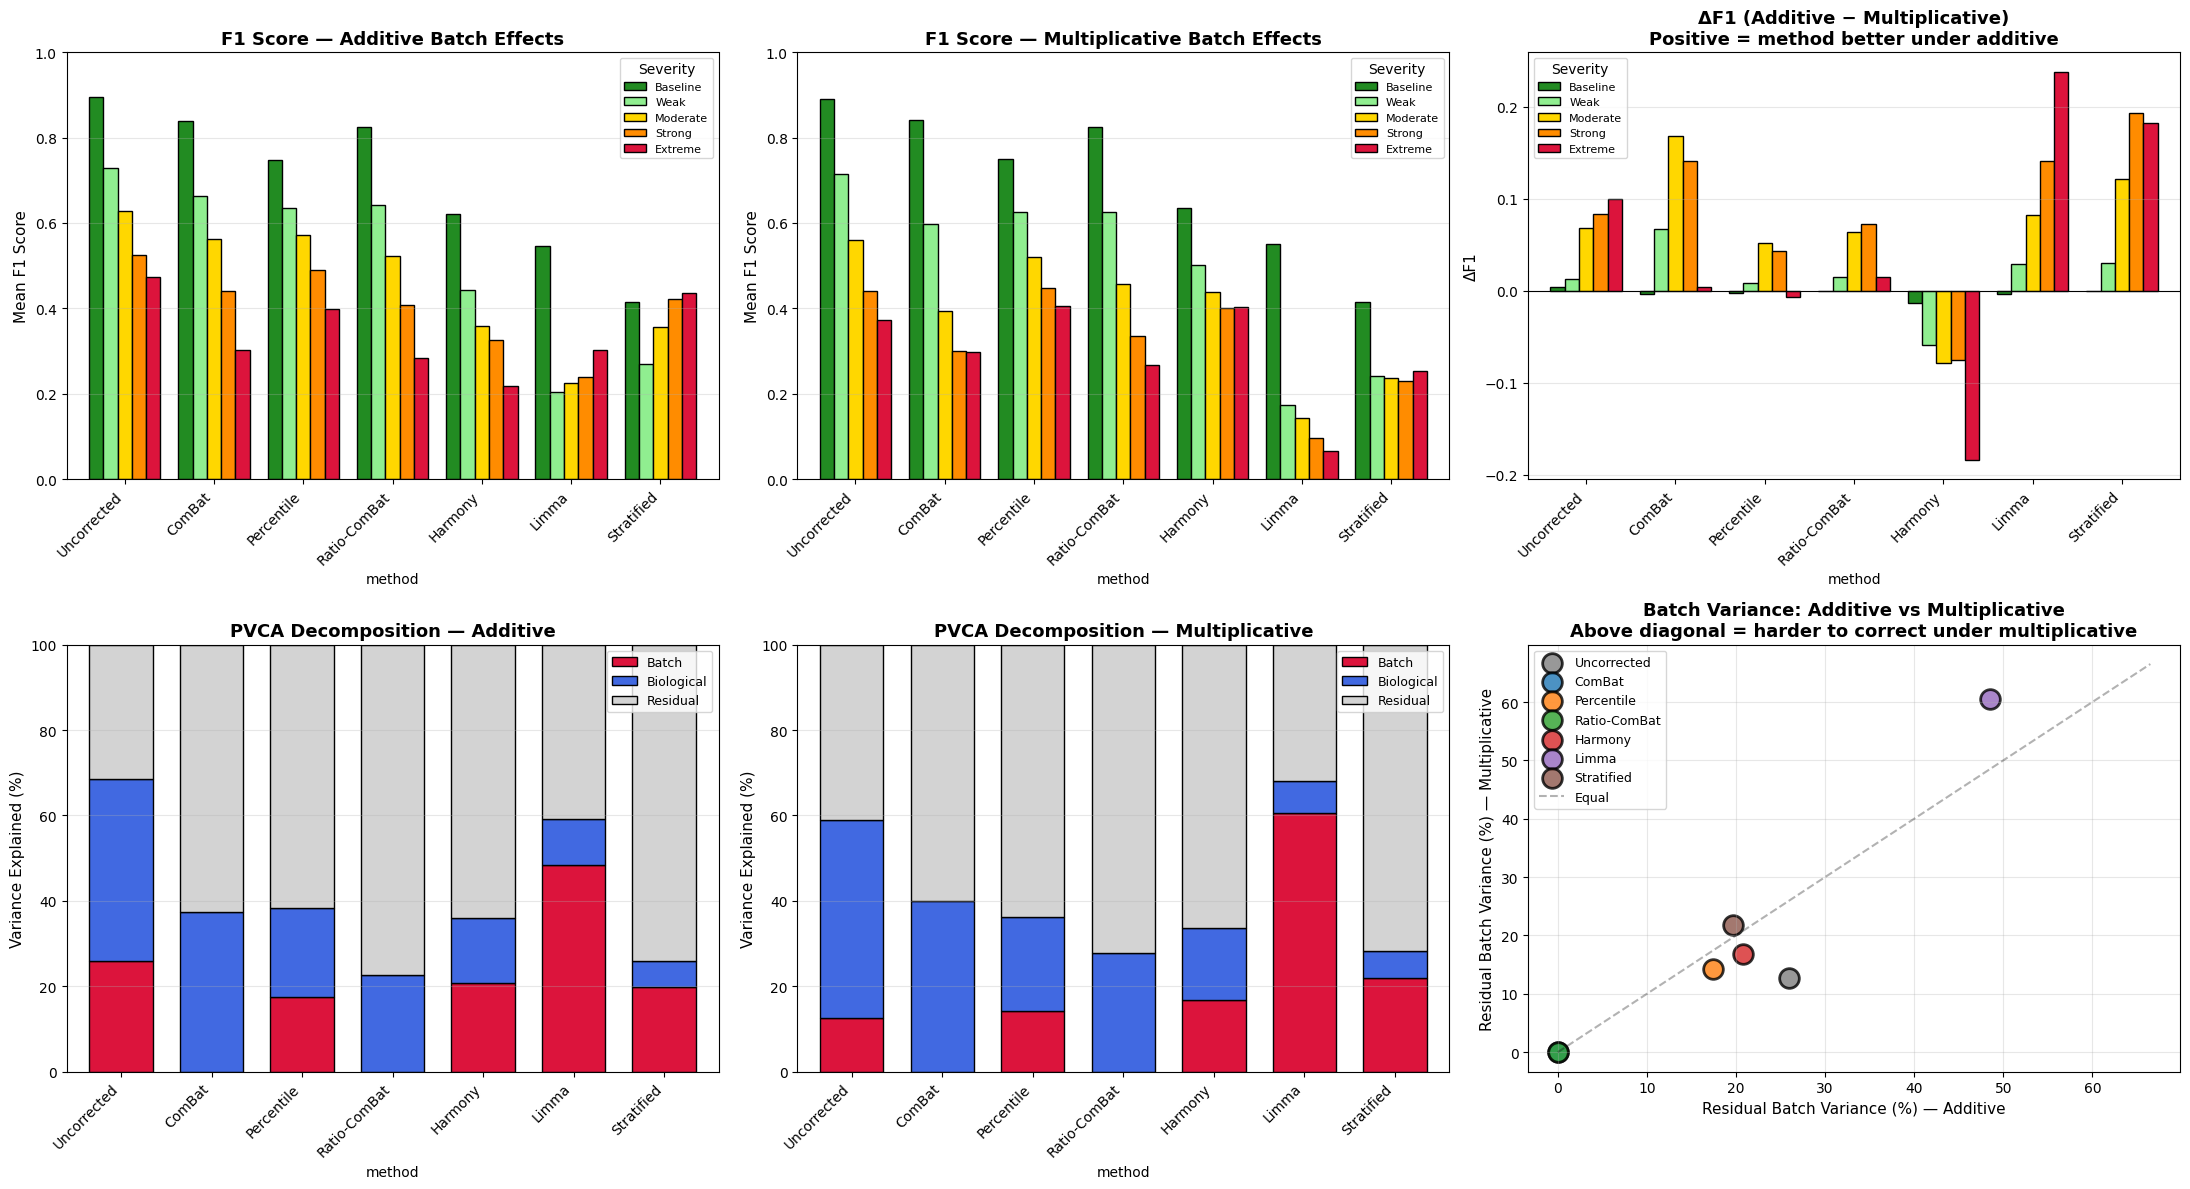

In [3]:
# Side-by-side additive vs multiplicative comparison
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
severity_order = ['Baseline', 'Weak', 'Moderate', 'Strong', 'Extreme']

# F1 by severity for each mode + delta
for col_idx, mode in enumerate(['additive', 'multiplicative']):
    ax = axes[0, col_idx]
    subset = agg_results[agg_results['batch_mode'] == mode]
    f1_sev = subset.groupby(['method', 'batch_severity'])['f1'].mean().unstack()
    f1_sev = f1_sev.reindex(method_order)[severity_order]
    f1_sev.plot(kind='bar', ax=ax, color=['#228B22', '#90EE90', '#FFD700', '#FF8C00', '#DC143C'],
                edgecolor='black', width=0.8)
    ax.set_title(f'F1 Score: {mode.capitalize()} Batch Effects', fontsize=13, fontweight='bold')
    ax.set_xticklabels(method_labels, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('Mean F1 Score', fontsize=11)
    ax.set_ylim(0, 1)
    ax.legend(title='Severity', fontsize=8)
    ax.grid(alpha=0.3, axis='y')

# F1 difference (additive - multiplicative) by method and severity
ax_delta = axes[0, 2]
f1_add = agg_results[agg_results['batch_mode'] == 'additive'].groupby(['method', 'batch_severity'])['f1'].mean().unstack()
f1_mul = agg_results[agg_results['batch_mode'] == 'multiplicative'].groupby(['method', 'batch_severity'])['f1'].mean().unstack()
f1_add = f1_add.reindex(method_order)[severity_order]
f1_mul = f1_mul.reindex(method_order)[severity_order]
f1_diff = f1_add - f1_mul
f1_diff.plot(kind='bar', ax=ax_delta, color=['#228B22', '#90EE90', '#FFD700', '#FF8C00', '#DC143C'],
             edgecolor='black', width=0.8)
ax_delta.axhline(0, color='black', linewidth=0.8)
ax_delta.set_title('ΔF1 (Additive − Multiplicative)\nPositive = method better under additive', fontsize=13, fontweight='bold')
ax_delta.set_xticklabels(method_labels, rotation=45, ha='right', fontsize=10)
ax_delta.set_ylabel('ΔF1', fontsize=11)
ax_delta.legend(title='Severity', fontsize=8)
ax_delta.grid(alpha=0.3, axis='y')

# PVCA decomposition stacked bars for each mode + scatter comparison
for col_idx, mode in enumerate(['additive', 'multiplicative']):
    ax = axes[1, col_idx]
    subset = agg_results[agg_results['batch_mode'] == mode]
    pvca = subset.groupby('method')[['PVCA_batch_variance', 'PVCA_bio_variance', 'PVCA_residual_variance']].mean()
    pvca = pvca.reindex(method_order)
    pvca.plot(kind='bar', stacked=True, ax=ax,
              color=['#DC143C', '#4169E1', '#D3D3D3'], edgecolor='black', width=0.7)
    ax.set_title(f'PVCA Decomposition — {mode.capitalize()}', fontsize=13, fontweight='bold')
    ax.set_xticklabels(method_labels, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('Variance Explained (%)', fontsize=11)
    ax.legend(['Batch', 'Biological', 'Residual'], fontsize=9)
    ax.set_ylim(0, 100)
    ax.grid(alpha=0.3, axis='y')

# Batch variance additive vs multiplicative per method
ax_scatter = axes[1, 2]
pvca_add = agg_results[agg_results['batch_mode'] == 'additive'].groupby('method')['PVCA_batch_variance'].mean()
pvca_mul = agg_results[agg_results['batch_mode'] == 'multiplicative'].groupby('method')['PVCA_batch_variance'].mean()
for i, method in enumerate(method_order):
    ax_scatter.scatter(pvca_add.get(method, 0), pvca_mul.get(method, 0),
                       s=200, c=colors[i], label=method_labels[i],
                       alpha=0.8, edgecolors='black', linewidths=2)
lim = max(pvca_add.max(), pvca_mul.max()) * 1.1
ax_scatter.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='Equal')
ax_scatter.set_xlabel('Residual Batch Variance (%) (Additive)', fontsize=11)
ax_scatter.set_ylabel('Residual Batch Variance (%) (Multiplicative)', fontsize=11)
ax_scatter.set_title('Batch Variance: Additive vs Multiplicative\nAbove diagonal = harder to correct under multiplicative', fontsize=13, fontweight='bold')
ax_scatter.legend(fontsize=9)
ax_scatter.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{fp}/results/figures/fig_additive_vs_multiplicative.pdf', dpi=300, bbox_inches='tight')
plt.show()

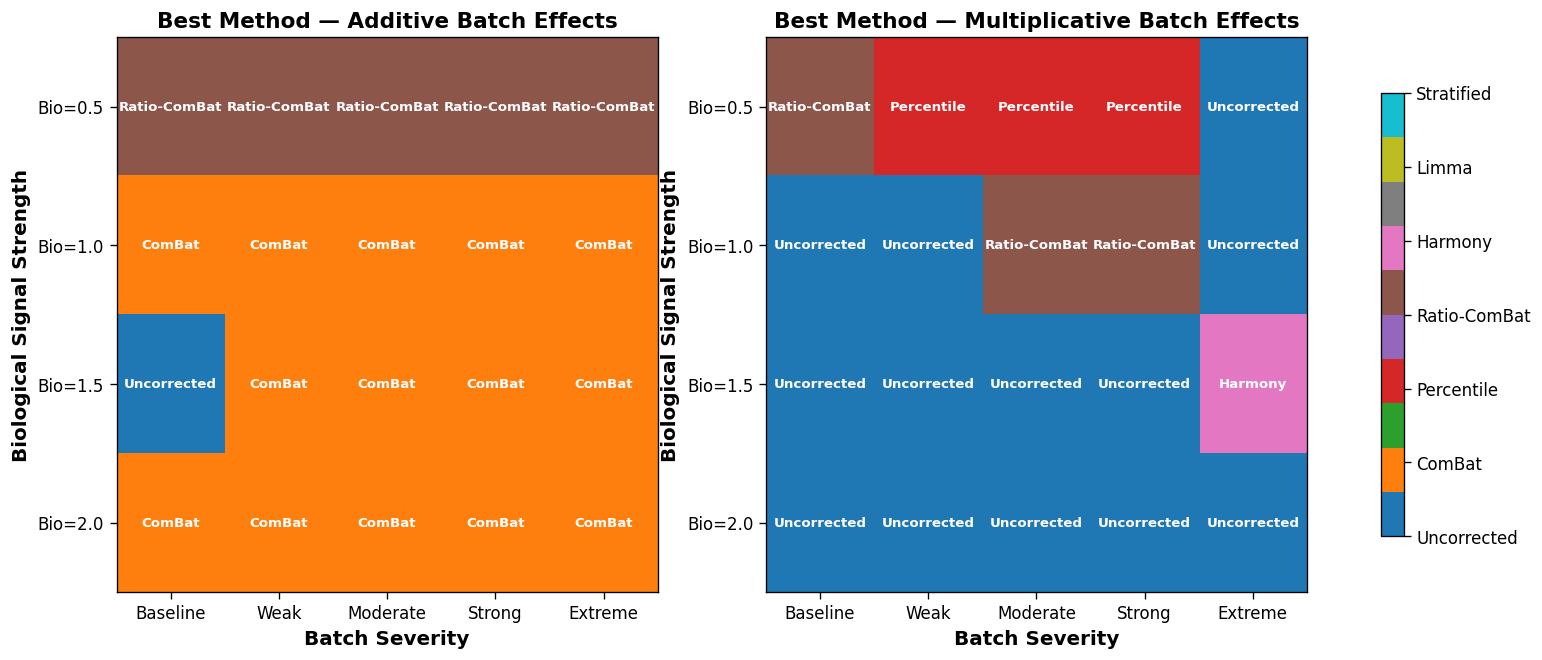


=== BEST METHOD SHIFTS: ADDITIVE → MULTIPLICATIVE ===
  Bio=0.5, Baseline: ratio        → ratio       
  Bio=0.5, Weak    : ratio        → percentile   ← CHANGED
  Bio=0.5, Moderate: ratio        → percentile   ← CHANGED
  Bio=0.5, Strong  : ratio        → percentile   ← CHANGED
  Bio=0.5, Extreme : ratio        → uncorrected  ← CHANGED
  Bio=1.0, Baseline: combat       → uncorrected  ← CHANGED
  Bio=1.0, Weak    : combat       → uncorrected  ← CHANGED
  Bio=1.0, Moderate: combat       → ratio        ← CHANGED
  Bio=1.0, Strong  : combat       → ratio        ← CHANGED
  Bio=1.0, Extreme : combat       → uncorrected  ← CHANGED
  Bio=1.5, Baseline: uncorrected  → uncorrected 
  Bio=1.5, Weak    : combat       → uncorrected  ← CHANGED
  Bio=1.5, Moderate: combat       → uncorrected  ← CHANGED
  Bio=1.5, Strong  : combat       → uncorrected  ← CHANGED
  Bio=1.5, Extreme : combat       → harmony      ← CHANGED
  Bio=2.0, Baseline: combat       → uncorrected  ← CHANGED
  Bio=2.0, Weak    : 

In [4]:
#Best method heatmap; one per mode, side by side
fig, (ax_add, ax_mul) = plt.subplots(1, 2, figsize=(16, 6))
bio_values = sorted(agg_results['bio_strength'].unique())
severity_bins = [(-0.01, 0.01), (0.01, 1.0), (1.0, 1.5), (1.5, 2.0), (2.0, 3.0)]
severity_labels_list = ['Baseline', 'Weak', 'Moderate', 'Strong', 'Extreme']
for ax, mode in [(ax_add, 'additive'), (ax_mul, 'multiplicative')]:
    subset = agg_results[agg_results['batch_mode'] == mode].copy()
    subset['batch_severity_score'] = subset['kappa_mu'] + subset['var_b']
    pivot_data = []
    for bio in bio_values:
        row = []
        for (low, high) in severity_bins:
            cond = subset[(subset['bio_strength'] == bio) & (subset['batch_severity_score'] > low) & (subset['batch_severity_score'] <= high)]
            if len(cond) > 0:
                cond = cond.copy()
                for col, sign in [('PVCA_batch_variance', -1), ('PVCA_bio_variance', 1), ('f1', 1)]:
                    rng = cond[col].max() - cond[col].min() + 1e-6
                    cond[f'{col}_norm'] = sign * (cond[col] - cond[col].min()) / rng if sign > 0 else (cond[col].max() - cond[col]) / rng
                cond['composite'] = 0.5 * cond['PVCA_batch_variance_norm'] + 0.3 * cond['PVCA_bio_variance_norm'] + 0.2 * cond['f1_norm']
                best = cond.loc[cond['composite'].idxmax(), 'method']
                row.append(method_order.index(best))
            else:
                row.append(-1)
        pivot_data.append(row)
    pivot_df = pd.DataFrame(pivot_data, index=[f'Bio={b}' for b in bio_values], columns=severity_labels_list)
    im = ax.imshow(pivot_df.values, cmap='tab10', aspect='auto', vmin=0, vmax=len(method_order)-1)
    ax.set_xticks(range(len(severity_labels_list)))
    ax.set_yticks(range(len(bio_values)))
    ax.set_xticklabels(severity_labels_list, fontsize=10)
    ax.set_yticklabels([f'Bio={b}' for b in bio_values], fontsize=10)
    ax.set_xlabel('Batch Severity', fontsize=12, fontweight='bold')
    ax.set_ylabel('Biological Signal Strength', fontsize=12, fontweight='bold')
    ax.set_title(f'Best Method — {mode.capitalize()} Batch Effects', fontsize=13, fontweight='bold')
    for i in range(len(bio_values)):
        for j in range(len(severity_labels_list)):
            midx = pivot_df.iloc[i, j]
            if midx >= 0:
                ax.text(j, i, method_labels[midx], ha='center', va='center', color='white', fontsize=8, fontweight='bold')
cbar = plt.colorbar(im, ax=[ax_add, ax_mul], ticks=range(len(method_order)), shrink=0.8)
cbar.set_ticklabels(method_labels)
plt.savefig(f'{fp}/results/figures/fig_best_method_additive_vs_multiplicative.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Print the key comparison table
print("\n=== BEST METHOD SHIFTS: ADDITIVE → MULTIPLICATIVE ===")
for bio in bio_values:
    for sev_label, (low, high) in zip(severity_labels_list, severity_bins):
        best_add, best_mul = 'N/A', 'N/A'
        for mode, best_ref in [('additive', 'best_add'), ('multiplicative', 'best_mul')]:
            subset = agg_results[(agg_results['batch_mode'] == mode) & (agg_results['bio_strength'] == bio)].copy()
            subset['bss'] = subset['kappa_mu'] + subset['var_b']
            cond = subset[(subset['bss'] > low) & (subset['bss'] <= high)]
            if len(cond) > 0:
                cond = cond.copy()
                for col, sign in [('PVCA_batch_variance', -1), ('PVCA_bio_variance', 1), ('f1', 1)]:
                    rng = cond[col].max() - cond[col].min() + 1e-6
                    cond[f'{col}_n'] = (cond[col].max() - cond[col]) / rng if sign < 0 else (cond[col] - cond[col].min()) / rng
                cond['comp'] = 0.5 * cond['PVCA_batch_variance_n'] + 0.3 * cond['PVCA_bio_variance_n'] + 0.2 * cond['f1_n']
                if mode == 'additive':
                    best_add = cond.loc[cond['comp'].idxmax(), 'method']
                else:
                    best_mul = cond.loc[cond['comp'].idxmax(), 'method']
        changed = " ← CHANGED" if best_add != best_mul and best_add != 'N/A' and best_mul != 'N/A' else ""
        print(f"  Bio={bio}, {sev_label:8s}: {best_add:12s} → {best_mul:12s}{changed}")